# Experiment Analysis: Accuracy and Individual Differences
This notebook processes the experiment data to calculate accuracy metrics and correlate them with survey scores (Anxiety/Worry and ERQ).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr,spearmanr

# Set plotting style
sns.set(style="whitegrid")

import pandas as pd

# Load the data
df = pd.read_csv('experiment_results_v2_export.csv')

print(f"Original N: {len(df)}")
print(f"Total missing values: {df.isnull().sum().sum()}")

# Remove subjects with any missing data
df_clean = df.dropna()

print(f"N after removing missing: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} subjects")

# Save cleaned data
df_clean.to_csv('experiment_results_v2_clean.csv', index=False)


Original N: 21
Total missing values: 1
N after removing missing: 20
Removed: 1 subjects


# Filter out bad subjects

ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)

Original Subject Count: 20

--------------------------------------------------------------------------------
FILTER 1: Zig-Zag Inconsistency
--------------------------------------------------------------------------------

Zig-Zag Threshold: 2.0
Subjects with zig-zag score >= 2.0: 1
Subject IDs: ['65fcdebb4bb107ea35f4ab42']
  65fcdebb4bb107ea35f4ab42: Zig-Zag Score = 2.000

--------------------------------------------------------------------------------
FILTER 2: Always Chose Feather Gamble
--------------------------------------------------------------------------------
  6960a545231c35c6048d7234: ALWAYS chose Feather gamble (8/8 trials)

Subjects who always chose Feather gamble: 1

--------------------------------------------------------------------------------
FILTER 4: Illogical R1 Ratings (Triangle > Feather)
--------------------------------------------------------------------------------

Logic: After MF learning, Feather should be

C:\Users\adip1\AppData\Local\Temp\ipykernel_17808\2345883872.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zigzag_scores = df_long.groupby('subject_id', group_keys=False).apply(calculate_inconsistency)



Visualization saved: subject_filtering_visualization.png

FILTERING COMPLETE!


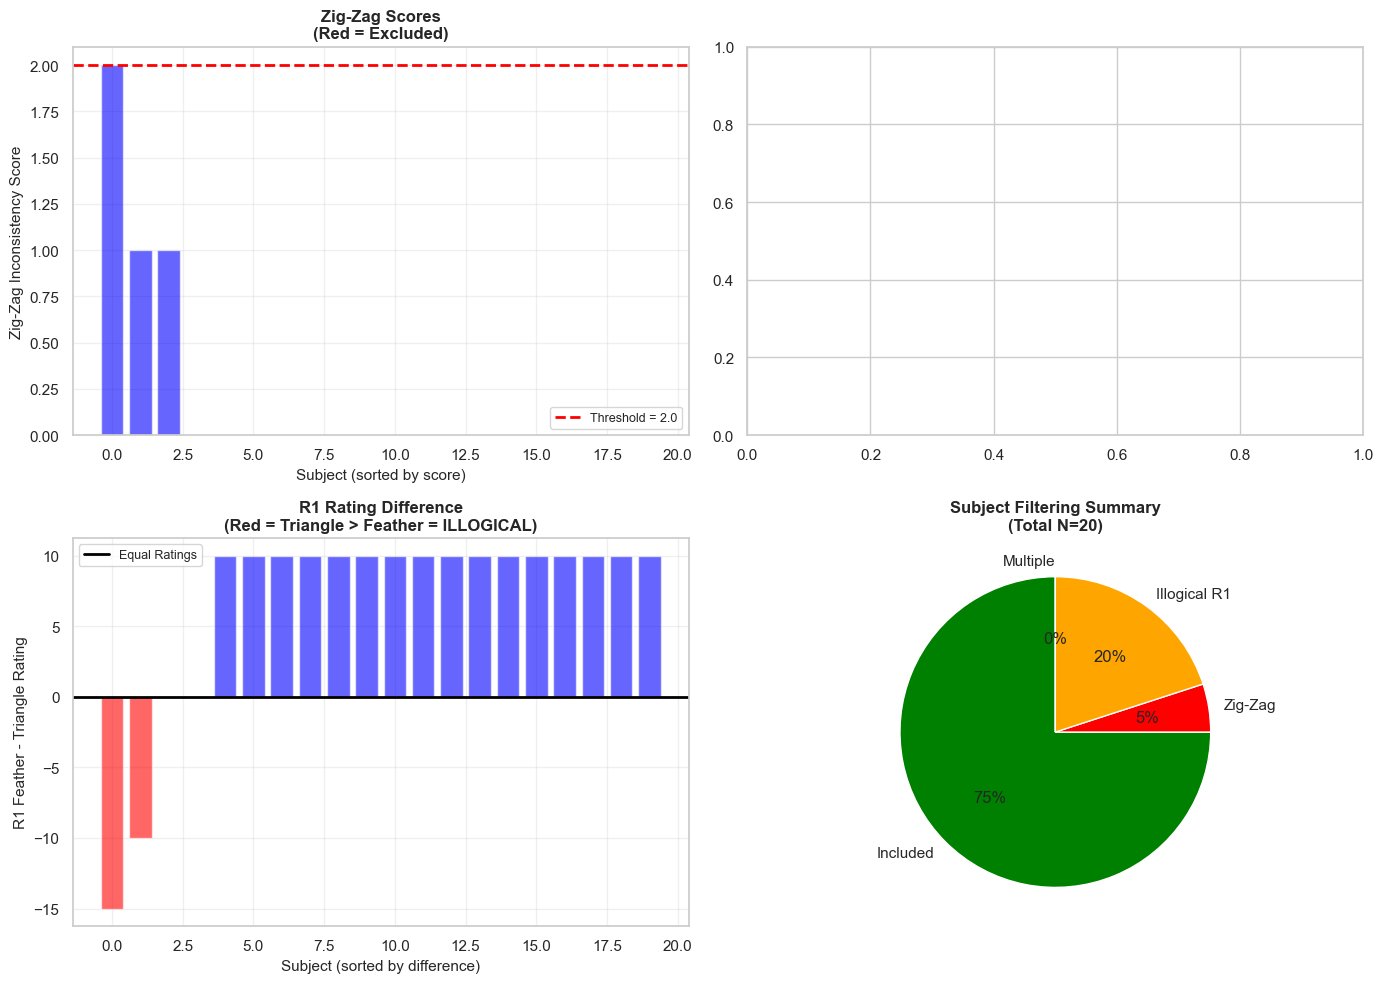

In [2]:
import pandas as pd
import numpy as np

print("="*80)
print("ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)")
print("="*80)

# Load data
df = pd.read_csv('experiment_results_v2_clean.csv')
df['subject_id'] = df['prolific_id']

print(f"\nOriginal Subject Count: {len(df)}")

# ============================================================================
# FILTER 1: ZIG-ZAG INCONSISTENCY (EXISTING CODE)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 1: Zig-Zag Inconsistency")
print("-"*80)

# Create a temporary long-format dataset to analyze choice curves
long_data = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    for q_num in [1, 2]:
        for t in range(1, 21):  # Max 20 trials
            prefix = f"Query_{q_num}_T{t}"
            state_col = f"{prefix}_State"
            offer_col = f"{prefix}_FixedOffer"
            choice_col = f"{prefix}_Choice"
            
            if state_col not in row or pd.isna(row[state_col]): 
                continue
            
            # Choice 0 = Chosen Fixed Offer (Safe)
            # Choice 1 = Chosen Gamble
            chose_fixed = 1 if row[choice_col] == 0 else 0
            
            long_data.append({
                'subject_id': subj_id,
                'Query': f"Query {q_num}",
                'State': row[state_col],
                'FixedOffer': row[offer_col],
                'Choice': row[choice_col],
                'ChoseFixed': chose_fixed
            })

df_long = pd.DataFrame(long_data)

# Function to calculate "Zig-Zag" score
def calculate_inconsistency(subject_df):
    total_violation = 0
    # Analyze each of the 4 conditions separately (Q1-Feather, Q1-Triangle, etc.)
    for _, group in subject_df.groupby(['Query', 'State']):
        # Get choice probability for each offer value, sorted low to high
        curve = group.groupby('FixedOffer')['ChoseFixed'].mean().sort_index()
        probs = curve.values
        
        # Check for drops: If Prob(Low Value) > Prob(High Value), that's inconsistent
        for i in range(len(probs) - 1):
            if probs[i] > probs[i+1]:
                total_violation += (probs[i] - probs[i+1])
    return total_violation

# Calculate scores for all subjects
zigzag_scores = df_long.groupby('subject_id', group_keys=False).apply(calculate_inconsistency)

# Define Threshold (At least 2 on the scale)
zigzag_threshold = 2.0
zigzag_bad_subjects = zigzag_scores[zigzag_scores >= zigzag_threshold].index.tolist()

print(f"\nZig-Zag Threshold: {zigzag_threshold}")
print(f"Subjects with zig-zag score >= {zigzag_threshold}: {len(zigzag_bad_subjects)}")
if len(zigzag_bad_subjects) > 0:
    print(f"Subject IDs: {zigzag_bad_subjects}")
    for subj in zigzag_bad_subjects:
        print(f"  {subj}: Zig-Zag Score = {zigzag_scores[subj]:.3f}")

# ============================================================================
# FILTER 2: ALWAYS CHOSE FEATHER (GAMBLE)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 2: Always Chose Feather Gamble")
print("-"*80)

always_feather_subjects = []

for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    
    # Get Feather trials (across both queries)
    feather_trials = subj_data[subj_data['State'] == 'Feather']
    
    if len(feather_trials) > 0:
        # Check if they ALWAYS chose the gamble (choice=1) for Feather
        all_chose_gamble = (feather_trials['Choice'] == 1).all()
        
        if all_chose_gamble:
            always_feather_subjects.append(subj_id)
            n_feather = len(feather_trials)
            print(f"  {subj_id}: ALWAYS chose Feather gamble ({n_feather}/{n_feather} trials)")

print(f"\nSubjects who always chose Feather gamble: {len(always_feather_subjects)}")

# ============================================================================
# FILTER 3: ALWAYS AVOIDED TRIANGLE (GAMBLE)
# ============================================================================
# print("\n" + "-"*80)
# print("FILTER 3: Always Avoided Triangle Gamble")
# print("-"*80)

always_avoid_triangle_subjects = []

for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    
    # Get Triangle trials (across both queries)
    triangle_trials = subj_data[subj_data['State'] == 'Triangle']
    
    if len(triangle_trials) > 0:
        # Check if they NEVER chose the gamble (always choice=0) for Triangle
        never_chose_gamble = (triangle_trials['Choice'] == 0).all()
        
        if never_chose_gamble:
            always_avoid_triangle_subjects.append(subj_id)
            n_triangle = len(triangle_trials)
            print(f"  {subj_id}: ALWAYS avoided Triangle gamble ({n_triangle}/{n_triangle} trials took offer)")

# print(f"\nSubjects who always avoided Triangle gamble: {len(always_avoid_triangle_subjects)}")

# ============================================================================
# FILTER 4: ILLOGICAL R1 RATINGS (TRIANGLE > FEATHER POST-MF)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 4: Illogical R1 Ratings (Triangle > Feather)")
print("-"*80)

print("\nLogic: After MF learning, Feather should be valued HIGHER than Triangle")
print("  - Feather → positive outcomes (should be rated high)")
print("  - Triangle → negative outcomes (should be rated low)")
print("  - Expected: Rating_1_Feather > Rating_1_Triangle")
print("  - Illogical: Rating_1_Triangle > Rating_1_Feather")

illogical_r1_subjects = []

for idx, row in df.iterrows():
    subj_id = row['subject_id']
    r1_feather = row['Rating_1_Feather_Val']
    r1_triangle = row['Rating_1_Triangle_Val']
    
    # Check if Triangle rated HIGHER than Feather at R1
    if r1_triangle >= r1_feather:
        illogical_r1_subjects.append(subj_id)
        print(f"  {subj_id}: R1 Triangle ({r1_triangle}) > R1 Feather ({r1_feather}) - ILLOGICAL")

print(f"\nSubjects with illogical R1 ratings: {len(illogical_r1_subjects)}")

# ============================================================================
# COMBINED FILTERING
# ============================================================================
print("\n" + "="*80)
print("COMBINED FILTERING RESULTS")
print("="*80)

# Combine all bad subjects
all_bad_subjects = list(set(zigzag_bad_subjects +  
                             illogical_r1_subjects))

print(f"\nTotal subjects to remove: {len(all_bad_subjects)}")
print("\nBreakdown:")
print(f"  Zig-zag inconsistent: {len(zigzag_bad_subjects)}")
# print(f"  Always chose Feather: {len(always_feather_subjects)}")
# print(f"  Always avoided Triangle: {len(always_avoid_triangle_subjects)}")
print(f"  Illogical R1 ratings: {len(illogical_r1_subjects)}")

# Check for overlap
zigzag_set = set(zigzag_bad_subjects)
# feather_set = set(always_feather_subjects)
# triangle_set = set(always_avoid_triangle_subjects)
illogical_set = set(illogical_r1_subjects)

overlaps = []
for s in all_bad_subjects:
    reasons_count = sum([s in zigzag_set,  s in illogical_set])
    if reasons_count > 1:
        overlaps.append(s)

if len(overlaps) > 0:
    print(f"\nSubjects failing multiple criteria: {len(overlaps)}")

# Apply Filter - Keep ALL columns from original dataset
df_filtered = df[~df['subject_id'].isin(all_bad_subjects)].copy()

print(f"\n" + "="*80)
print(f"FINAL RESULTS:")
print(f"  Original N: {len(df)}")
print(f"  Removed: {len(all_bad_subjects)}")
print(f"  Final N: {len(df_filtered)}")
print(f"  Retention rate: {len(df_filtered)/len(df)*100:.1f}%")
print(f"  Columns preserved: {len(df_filtered.columns)}")
print("="*80)

# Verify questionnaire data is present
questionnaire_cols = [col for col in df_filtered.columns if 'Survey' in col or 'ERQ' in col]
print(f"\nQuestionnaire data verification:")
print(f"  Total questionnaire columns: {len(questionnaire_cols)}")
print(f"  Anxiety columns: {len([c for c in questionnaire_cols if 'ANXIETY' in c])}")
print(f"  ERQ columns: {len([c for c in questionnaire_cols if 'ERQ' in c])}")

# ============================================================================
# DETAILED SUBJECT INFORMATION
# ============================================================================
print("\n" + "="*80)
print("DETAILED EXCLUSION INFORMATION")
print("="*80)

if len(all_bad_subjects) > 0:
    print("\nExcluded subjects with reasons:")
    print("-"*80)
    
    for subj in all_bad_subjects:
        reasons = []
        
        if subj in zigzag_bad_subjects:
            reasons.append(f"Zig-zag={zigzag_scores[subj]:.3f}")
        
        # if subj in always_feather_subjects:
        #     n_feather = len(df_long[(df_long['subject_id']==subj) & (df_long['State']=='Feather')])
        #     reasons.append(f"Always-Feather (100% gamble, {n_feather} trials)")
        
        # if subj in always_avoid_triangle_subjects:
        #     n_triangle = len(df_long[(df_long['subject_id']==subj) & (df_long['State']=='Triangle')])
        #     reasons.append(f"Always-Avoid-Triangle (0% gamble, {n_triangle} trials)")
        
        if subj in illogical_r1_subjects:
            subj_row = df[df['subject_id']==subj].iloc[0]
            r1_f = subj_row['Rating_1_Feather_Val']
            r1_t = subj_row['Rating_1_Triangle_Val']
            reasons.append(f"Illogical-R1 (Triangle={r1_t} > Feather={r1_f})")
        
        print(f"  {subj}: {', '.join(reasons)}")
else:
    print("\nNo subjects excluded!")

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save filtered data
df_filtered.to_csv('filtered_data.csv', index=False)

# Save exclusion information
exclusion_info = pd.DataFrame({
    'subject_id': all_bad_subjects,
    'zigzag_inconsistent': [s in zigzag_bad_subjects for s in all_bad_subjects],
    # 'always_feather': [s in always_feather_subjects for s in all_bad_subjects],
    # 'always_avoid_triangle': [s in always_avoid_triangle_subjects for s in all_bad_subjects],
    'illogical_r1': [s in illogical_r1_subjects for s in all_bad_subjects],
    'zigzag_score': [zigzag_scores.get(s, np.nan) for s in all_bad_subjects]
})

exclusion_info.to_csv('excluded_subjects.csv', index=False)

# Save inclusion information for all subjects
all_subjects_info = pd.DataFrame({
    'subject_id': df['subject_id'].unique(),
    'zigzag_score': [zigzag_scores.get(s, np.nan) for s in df['subject_id'].unique()],
    'n_feather_trials': [len(df_long[(df_long['subject_id']==s) & (df_long['State']=='Feather')]) for s in df['subject_id'].unique()],
    'n_triangle_trials': [len(df_long[(df_long['subject_id']==s) & (df_long['State']=='Triangle')]) for s in df['subject_id'].unique()],
    'feather_gamble_rate': [df_long[(df_long['subject_id']==s) & (df_long['State']=='Feather')]['Choice'].mean() for s in df['subject_id'].unique()],
    'triangle_gamble_rate': [df_long[(df_long['subject_id']==s) & (df_long['State']=='Triangle')]['Choice'].mean() for s in df['subject_id'].unique()],
    'r1_feather_val': [df[df['subject_id']==s]['Rating_1_Feather_Val'].values[0] for s in df['subject_id'].unique()],
    'r1_triangle_val': [df[df['subject_id']==s]['Rating_1_Triangle_Val'].values[0] for s in df['subject_id'].unique()],
    'r1_triangle_higher': [df[df['subject_id']==s]['Rating_1_Triangle_Val'].values[0] > df[df['subject_id']==s]['Rating_1_Feather_Val'].values[0] for s in df['subject_id'].unique()],
    'excluded': [s in all_bad_subjects for s in df['subject_id'].unique()],
    'exclusion_reason': ['Included' if s not in all_bad_subjects else 
                         ', '.join([
                             'Zig-zag' if s in zigzag_bad_subjects else '',
                             # 'Always-Feather' if s in always_feather_subjects else '',
                             # 'Always-Avoid-Triangle' if s in always_avoid_triangle_subjects else '',
                             'Illogical-R1' if s in illogical_r1_subjects else ''
                         ]).strip(', ') 
                         for s in df['subject_id'].unique()]
})

all_subjects_info.to_csv('all_subjects_filtering_info.csv', index=False)

print("\n" + "="*80)
print("Files saved:")
print("  - filtered_data.csv (N={})".format(len(df_filtered)))
print("  - excluded_subjects.csv (N={})".format(len(all_bad_subjects)))
print("  - all_subjects_filtering_info.csv (N={})".format(len(df)))
print("="*80)

# ============================================================================
# VISUALIZE FILTERING CRITERIA
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Zig-zag scores distribution
ax = axes[0, 0]
zigzag_df = pd.DataFrame({
    'subject_id': zigzag_scores.index,
    'zigzag_score': zigzag_scores.values,
    'excluded': [s in zigzag_bad_subjects for s in zigzag_scores.index]
})

colors = ['red' if exc else 'blue' for exc in zigzag_df['excluded']]
ax.bar(range(len(zigzag_df)), zigzag_df['zigzag_score'].sort_values(ascending=False), color=colors, alpha=0.6)
ax.axhline(zigzag_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {zigzag_threshold}')
ax.set_xlabel('Subject (sorted by score)', fontsize=11)
ax.set_ylabel('Zig-Zag Inconsistency Score', fontsize=11)
ax.set_title('Zig-Zag Scores\n(Red = Excluded)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: Feather gamble rates
# ax = axes[0, 1]
# feather_rates = all_subjects_info.sort_values('feather_gamble_rate')
# colors = ['red' if s in always_feather_subjects else 'blue' for s in feather_rates['subject_id']]
# ax.bar(range(len(feather_rates)), feather_rates['feather_gamble_rate'], color=colors, alpha=0.6)
# ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Always Gamble (100%)')
# ax.set_xlabel('Subject (sorted by rate)', fontsize=11)
# ax.set_ylabel('Feather Gamble Rate', fontsize=11)
# ax.set_title('Feather Gamble Rates\n(Red = Always 100%)', fontsize=12, fontweight='bold')
# ax.set_ylim([0, 1.05])
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)

# Panel C: R1 rating difference (Feather - Triangle)
ax = axes[1, 0]
r1_diff = all_subjects_info['r1_feather_val'] - all_subjects_info['r1_triangle_val']
r1_diff_sorted = r1_diff.sort_values()
colors = ['red' if all_subjects_info[all_subjects_info['subject_id']==sid]['r1_triangle_higher'].values[0] 
          else 'blue' for sid in all_subjects_info.loc[r1_diff_sorted.index, 'subject_id']]

ax.bar(range(len(r1_diff_sorted)), r1_diff_sorted, color=colors, alpha=0.6)
ax.axhline(0.0, color='black', linestyle='-', linewidth=2, label='Equal Ratings')
ax.set_xlabel('Subject (sorted by difference)', fontsize=11)
ax.set_ylabel('R1 Feather - Triangle Rating', fontsize=11)
ax.set_title('R1 Rating Difference\n(Red = Triangle > Feather = ILLOGICAL)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Summary pie chart
ax = axes[1, 1]
exclusion_counts = {
    'Included': len(df_filtered),
    'Zig-Zag': len([s for s in zigzag_bad_subjects if s not in (illogical_set)]),
    # 'Always Feather': len([s for s in always_feather_subjects if s not in (zigzag_set | triangle_set | illogical_set)]),
    # 'Always Avoid\nTriangle': len([s for s in always_avoid_triangle_subjects if s not in (zigzag_set | feather_set | illogical_set)]),
    'Illogical R1': len([s for s in illogical_r1_subjects if s not in (zigzag_set)]),
    'Multiple': len([s for s in all_bad_subjects if sum([s in zigzag_set, s in illogical_set]) > 1])
}

colors_pie = ['green', 'red', 'orange', 'purple', 'brown', 'gray']
ax.pie(exclusion_counts.values(), labels=exclusion_counts.keys(), autopct='%1.0f%%',
       colors=colors_pie, startangle=90)
ax.set_title(f'Subject Filtering Summary\n(Total N={len(df)})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('subject_filtering_visualization.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: subject_filtering_visualization.png")

print("\n" + "="*80)
print("FILTERING COMPLETE!")
print("="*80)

## 1. Data Loading and Survey Scoring
Here we load the raw data and calculate the total scores for the questionnaires.
* **Anxiety/Worry:** Sum of all `Survey_ANXIETY_...` raw items (No reverse coding).
* **ERQ (Cognitive Reappraisal):** Items 1, 3, 5, 7, 8, 10 (pre-calculated in export script).
* **ERQ (Expressive Suppression):** Items 2, 4, 6, 9 (pre-calculated in export script).


In [3]:
# Load the data
df = pd.read_csv('filtered_data.csv')
print(len(df))
# Use prolific_id as subject identifier
df['subject_id'] = df['prolific_id']

# Anxiety scores
df['Score_Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score'] 
# Define Cognitive Reappraisal items (1, 3, 5, 7, 8, 10)
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Cognitive_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_ExpressiveSuppression'] = df[expressive_suppression_items].sum(axis=1)

# ERQ scores - use pre-calculated subscores from export script
df['Score_ERQ_Total'] = df['ERQ_Cognitive_Reappraisal']  # Primary measure: Cognitive Reappraisal
df=df[df['Knowledge_Check_Accuracy']>0.25]
print(len(df['subject_id'].unique()))
df.to_csv('filtered_data.csv')

# Display a preview
print(df[['subject_id', 'Score_Anxiety_Total', 'Score_ERQ_Total']].head())


15
15
                 subject_id  Score_Anxiety_Total  Score_ERQ_Total
0  65fb70d4e69155a62d58ac90                   11               30
1  612adba08b8235b31539c704                   29               36
2  6960a545231c35c6048d7234                   10               29
3  5ba78b71d60daf0001532d5b                   10               36
4  67a96562e2b052e6c15ed963                   29               28


## 2. General Accuracy Analysis
We define the Expected Values (EV) and calculate optimal choice percentages for Query 1 and Query 2.


--- One-Sample T-Tests (Test Value = 25%) ---
Acc_Q1_Feather: Mean=68.33%, t(14)=2.44, p=0.0285 *
Acc_Q1_Triangle: Mean=83.33%, t(14)=5.74, p=0.0001 ***
Acc_Q2_Feather: Mean=91.67%, t(14)=13.23, p=0.0000 ***
Acc_Q2_Triangle: Mean=86.67%, t(14)=7.64, p=0.0000 ***


C:\Users\adip1\AppData\Local\Temp\ipykernel_17808\4191565236.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Condition', y='Accuracy',


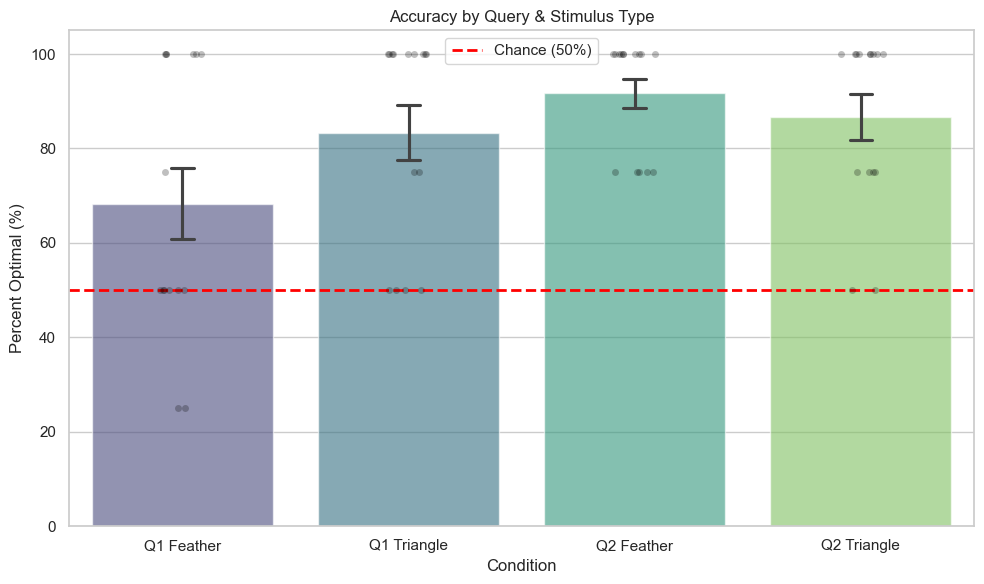

In [4]:
# Configuration
q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

def get_trial_optimality(row, query_num, trial_num):
    prefix = f"Query_{query_num}_T{trial_num}"
    state_col = f"{prefix}_State"
    offer_col = f"{prefix}_FixedOffer"
    choice_col = f"{prefix}_Choice"
    
    # Check if columns exist
    if state_col not in row.index or pd.isna(row[state_col]): return None, None
    
    state = row[state_col]
    fixed_offer = row[offer_col]
    choice = row[choice_col]
    
    # Determine Risky EV
    if query_num == 1:
        risky_ev = q1_ev_map.get(state)
    else:
        risky_ev = q2_ev_map.get(state)
        
    if risky_ev is None: return None, None
    
    # Determine Optimal Choice (1=Risky, 0=Safe)
    if risky_ev > fixed_offer:
        optimal_choice = 1
    elif risky_ev < fixed_offer:
        optimal_choice = 0
    else:
        return 1,state
        
    is_optimal = 1 if choice == optimal_choice else 0
    return is_optimal, state

# Calculate Accuracy per Subject
subject_stats = []
max_trials = 20  # Assumed max trials per query

for idx, row in df.iterrows():
    subj_id = row['subject_id']
    # Initialize Specific Counters for Interaction Terms
    q1_feather_corr, q1_feather_n = 0, 0
    q1_triangle_corr, q1_triangle_n = 0, 0
    q2_feather_corr, q2_feather_n = 0, 0
    q2_triangle_corr, q2_triangle_n = 0, 0
    
    # Process Query 1
    for t in range(1, max_trials + 1):
        res, state = get_trial_optimality(row, 1, t)
        if res is not None:
            if state == 'Feather':
                q1_feather_corr += res
                q1_feather_n += 1
            elif state == 'Triangle':
                q1_triangle_corr += res
                q1_triangle_n += 1
                
    # Process Query 2
    for t in range(1, max_trials + 1):
        res, state = get_trial_optimality(row, 2, t)
        if res is not None:
            if state == 'Feather':
                q2_feather_corr += res
                q2_feather_n += 1
            elif state == 'Triangle':
                q2_triangle_corr += res
                q2_triangle_n += 1
    
    # Calculate Aggregate Counts (for the general variables)
    q1_corr = q1_feather_corr + q1_triangle_corr
    q1_n = q1_feather_n + q1_triangle_n
    
    q2_corr = q2_feather_corr + q2_triangle_corr
    q2_n = q2_feather_n + q2_triangle_n
    
    feather_corr = q1_feather_corr + q2_feather_corr
    feather_n = q1_feather_n + q2_feather_n
    
    triangle_corr = q1_triangle_corr + q2_triangle_corr
    triangle_n = q1_triangle_n + q2_triangle_n

    # Helper for safe percentage calculation
    def calc_pct(num, denom):
        return (num / denom * 100) if denom > 0 else np.nan

    # Compile stats
    stats = {
        'subject_id': subj_id,
        
        # General Accuracy
        'Acc_Q1': calc_pct(q1_corr, q1_n),
        'Acc_Q2': calc_pct(q2_corr, q2_n),
        'Acc_Feather': calc_pct(feather_corr, feather_n),
        'Acc_Triangle': calc_pct(triangle_corr, triangle_n),
        
        # NEW: Accuracy broken down by Query AND Stimulus
        'Acc_Q1_Feather': calc_pct(q1_feather_corr, q1_feather_n),
        'Acc_Q1_Triangle': calc_pct(q1_triangle_corr, q1_triangle_n),
        'Acc_Q2_Feather': calc_pct(q2_feather_corr, q2_feather_n),
        'Acc_Q2_Triangle': calc_pct(q2_triangle_corr, q2_triangle_n),
        
        # Survey Scores
        'Score_Anxiety': row['Survey_ANXIETY_1_Total_Score'],
        'Score_ERQ': row['ERQ_Cognitive_Reappraisal']
    }
    subject_stats.append(stats)

stats_df = pd.DataFrame(subject_stats)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# ... (Assuming stats_df is already created from the previous step) ...

print("--- One-Sample T-Tests (Test Value = 25%) ---")
t_test_vars = ['Acc_Q1_Feather', 'Acc_Q1_Triangle', 'Acc_Q2_Feather', 'Acc_Q2_Triangle']

for col in t_test_vars:
    # Drop NaNs just in case a subject missed a specific condition entirely
    data = stats_df[col].dropna()
    t_stat, p_val = ttest_1samp(data, 50)
    
    # Check significance stars
    stars = ""
    if p_val < 0.001: stars = "***"
    elif p_val < 0.01: stars = "**"
    elif p_val < 0.05: stars = "*"
    
    print(f"{col}: Mean={data.mean():.2f}%, t({len(data)-1})={t_stat:.2f}, p={p_val:.4f} {stars}")

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Melt data for Seaborn
plot_data = pd.melt(stats_df, 
                    value_vars=t_test_vars, 
                    var_name='Condition', 
                    value_name='Accuracy')

# Clean up labels (Remove 'Acc_' and replace underscores)
plot_data['Condition'] = plot_data['Condition'].str.replace('Acc_', '').str.replace('_', ' ')

# Create Plot
# 1. Bar plot for Means + Standard Error
sns.barplot(data=plot_data, x='Condition', y='Accuracy', 
            capsize=.1, errorbar='se', alpha=0.6, palette="viridis")

# 2. Stripplot for Individual Data Points
sns.stripplot(data=plot_data, x='Condition', y='Accuracy', 
              color='black', alpha=0.25, jitter=True)

# 3. Add Chance Level Line
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Chance (50%)')

plt.title('Accuracy by Query & Stimulus Type')
plt.ylabel('Percent Optimal (%)')
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()

--- Accuracy by Condition (Descriptive) ---
       Acc_Q1_Feather  Acc_Q1_Triangle  Acc_Q2_Feather  Acc_Q2_Triangle
count       15.000000        15.000000       15.000000        15.000000
mean        68.333333        83.333333       91.666667        86.666667
std         29.072979        22.493385       12.198751        18.580584
min         25.000000        50.000000       75.000000        50.000000
25%         50.000000        62.500000       75.000000        75.000000
50%         50.000000       100.000000      100.000000       100.000000
75%        100.000000       100.000000      100.000000       100.000000
max        100.000000       100.000000      100.000000       100.000000


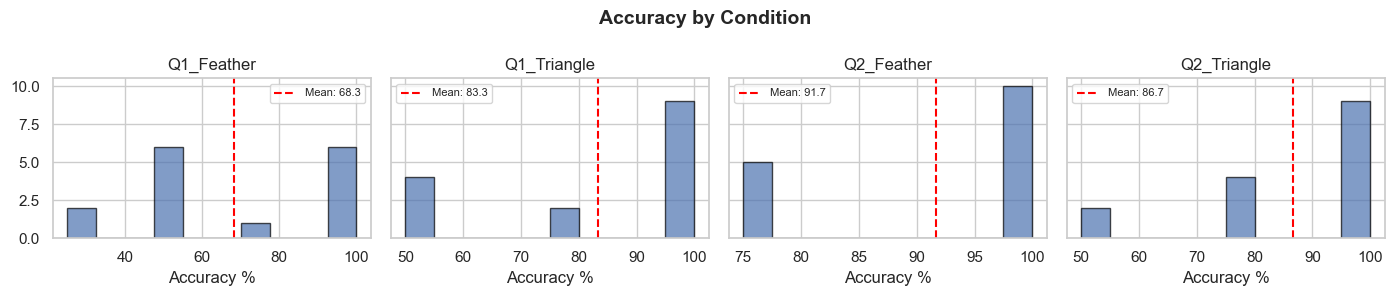


--- T-tests Against Chance (50%) ---
Acc_Q1_Feather: Mean = 68.3%, t = 2.44, p = 0.0285
Acc_Q1_Triangle: Mean = 83.3%, t = 5.74, p = 0.0001
Acc_Q2_Feather: Mean = 91.7%, t = 13.23, p = 0.0000
Acc_Q2_Triangle: Mean = 86.7%, t = 7.64, p = 0.0000


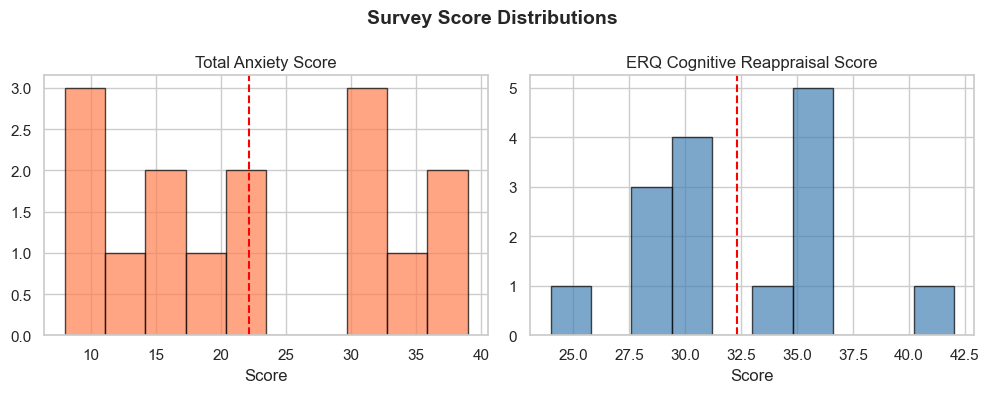

In [5]:

# Overall group stats by condition for Supplementary Analysis
# We'll create a visualization with meaningful statistics.

# 1. Descriptive Stats for Accuracy Measures
accuracy_summary = stats_df[['Acc_Q1_Feather', 'Acc_Q1_Triangle', 'Acc_Q2_Feather', 'Acc_Q2_Triangle']].describe()
print("--- Accuracy by Condition (Descriptive) ---")
print(accuracy_summary)

# 2. Plot Accuracy Distributions by Condition
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for i, col in enumerate(['Acc_Q1_Feather', 'Acc_Q1_Triangle', 'Acc_Q2_Feather', 'Acc_Q2_Triangle']):
    axes[i].hist(stats_df[col].dropna(), bins=10, edgecolor='black', alpha=0.7)
    axes[i].set_title(col.replace('Acc_', ''))
    axes[i].set_xlabel('Accuracy %')
    axes[i].axvline(stats_df[col].mean(), color='red', linestyle='--', label=f'Mean: {stats_df[col].mean():.1f}')
    axes[i].legend(fontsize=8)
plt.suptitle('Accuracy by Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. T-Tests against chance (50%)
print("\n--- T-tests Against Chance (50%) ---")
for col in ['Acc_Q1_Feather', 'Acc_Q1_Triangle', 'Acc_Q2_Feather', 'Acc_Q2_Triangle']:
    data = stats_df[col].dropna()
    t_stat, p_val = ttest_1samp(data, 50)
    print(f"{col}: Mean = {data.mean():.1f}%, t = {t_stat:.2f}, p = {p_val:.4f}")

# 4. Survey Score Distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(stats_df['Score_Anxiety'].dropna(), bins=10, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('Total Anxiety Score')
axes[0].set_xlabel('Score')
axes[0].axvline(stats_df['Score_Anxiety'].mean(), color='red', linestyle='--')

axes[1].hist(stats_df['Score_ERQ'].dropna(), bins=10, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title('ERQ Cognitive Reappraisal Score')
axes[1].set_xlabel('Score')
axes[1].axvline(stats_df['Score_ERQ'].mean(), color='red', linestyle='--')

plt.suptitle('Survey Score Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

LINEAR MIXED MODEL: Query 1 Accuracy by State Type

Dataset: 15 subjects

Objective Expected Values:
  Feather: -15
  Triangle: 15

STEP 1: Preparing Data

Total observations: 120
Subjects: 15

Trials per subject by state type:
state_type                Feather  Triangle
subject_id                                 
56d1f7f67bbc32000589a588        4         4
5ba78b71d60daf0001532d5b        4         4
5d7fd2a5987f70001602d95b        4         4
5e7fa0e918b10804bb87eb63        4         4
6065f9d75bd3321f0bafa750        4         4
612adba08b8235b31539c704        4         4
63fbf0e3b18cc14adc0dbfb6        4         4
65fb70d4e69155a62d58ac90        4         4
666f76b68b89442817be678a        4         4
667d08e12ac1bcbdd829a936        4         4
66d1fdd400acfdbc181f41e0        4         4
66e2abbef5fe9e10f5bff804        4         4
67a96562e2b052e6c15ed963        4         4
67ee50bbaa206db46d5e94c2        4         4
6960a545231c35c6048d7234        4         4

Mean trials per state: 

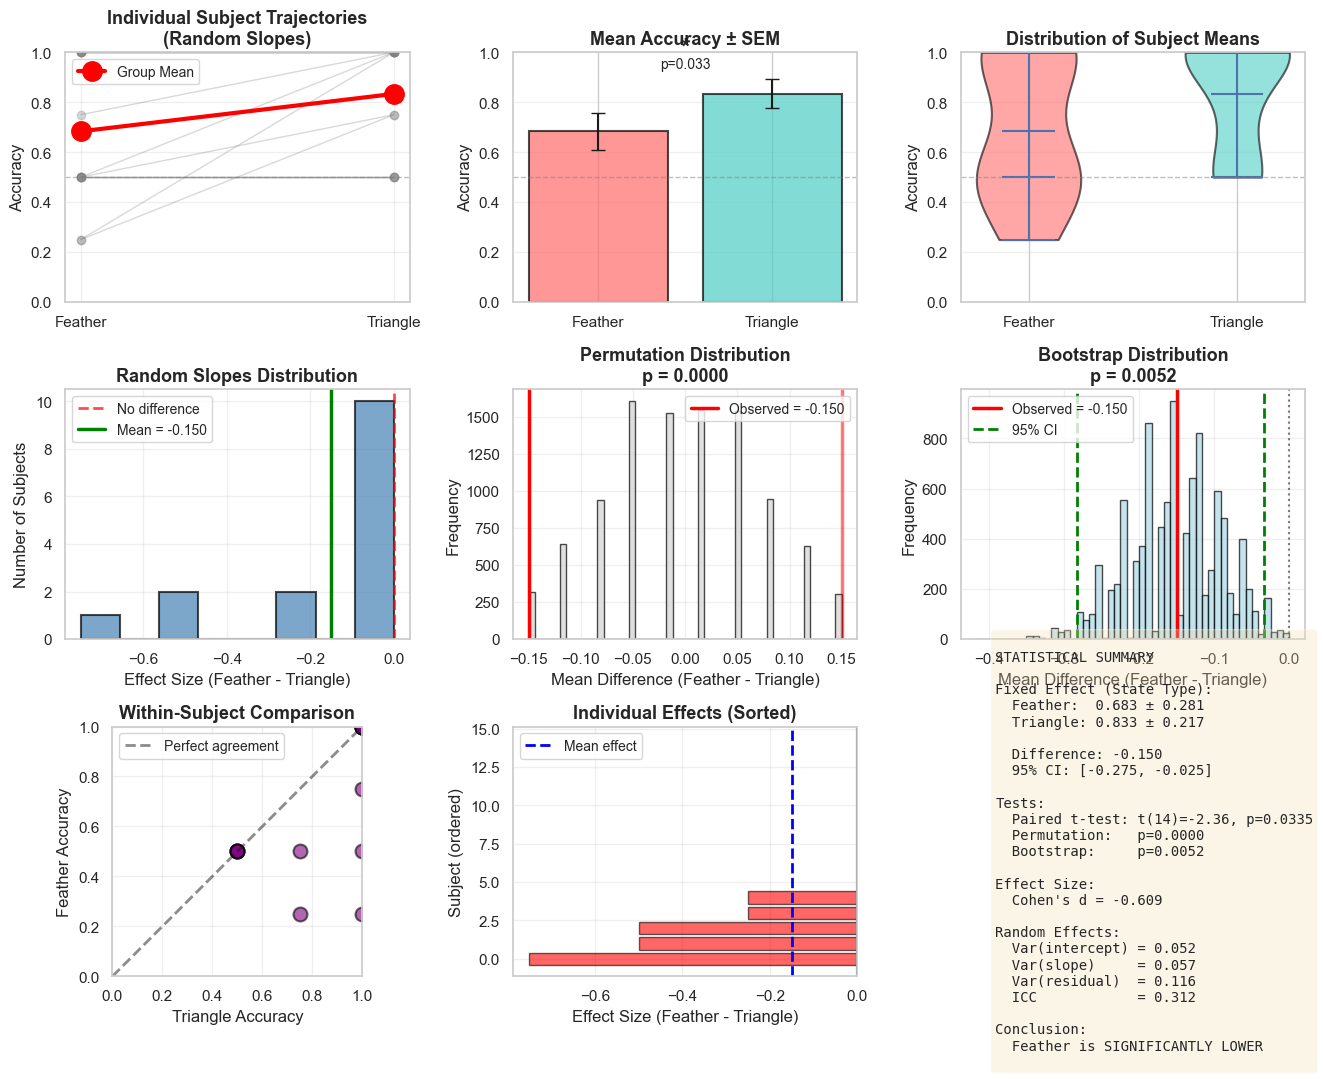

Saved: query1_lmm_final.png
Saved: query1_lmm_final_results.csv
Saved: query1_trial_level_final.csv

FINAL SUMMARY

Model: accuracy ~ state_type + (1 + state_type | subject)

Fixed Effect (State Type):
  Feather:  68.3% (SD=28.1%)
  Triangle: 83.3% (SD=21.7%)
  Difference: -15.0% (Feather - Triangle)
  95% CI: [-27.5%, -2.5%]

Statistical Tests:
  Paired t-test: t(14) = -2.358, p = 0.0335 *
  Permutation:   p = 0.0000
  Bootstrap:     p = 0.0052

Effect Size: Cohen's d = -0.609

Random Effects Variance:
  Between-subject (intercept): 0.0524
  Slope variability: 0.0567
  Within-subject (residual): 0.1155
  ICC: 0.312

✓ CONCLUSION: Feather accuracy is significantly LOWER than Triangle
              by 15.0% (p = 0.0335)



In [6]:
"""
Linear Mixed Model: Query 1 Accuracy
Model: accuracy ~ state_type + (1 + state_type | subject)
- Fixed effect: state_type (Feather vs Triangle)
- Random effects: Random intercept and random slope per subject
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.linalg import block_diag

# Set random seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('filtered_data.csv')

print("="*80)
print("LINEAR MIXED MODEL: Query 1 Accuracy by State Type")
print("="*80)
print()
print(f"Dataset: {len(df)} subjects")
print()

# Define objective EVs (using inferred values from choice patterns)
FEATHER_EV = -15
TRIANGLE_EV = 15

print("Objective Expected Values:")
print(f"  Feather: {FEATHER_EV}")
print(f"  Triangle: {TRIANGLE_EV}")
print()

# =============================================================================
# STEP 1: Create trial-level dataset for Query 1 only
# =============================================================================

print("="*80)
print("STEP 1: Preparing Data")
print("="*80)
print()

records = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    
    # Query 1 only - 8 trials total (4 Feather, 4 Triangle)
    for trial in range(1, 9):
        state = row.get(f'Query_1_T{trial}_State')
        choice = row.get(f'Query_1_T{trial}_Choice')
        offer = row.get(f'Query_1_T{trial}_FixedOffer')
        
        if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
            continue
        
        # Determine optimal choice based on objective EV
        true_ev = FEATHER_EV if state == 'Feather' else TRIANGLE_EV
        
        if true_ev > offer:
            optimal_choice = 1
        elif true_ev < offer:
            optimal_choice = 0
        else:
            optimal_choice = choice  # Indifferent
        
        accuracy = 1 if choice == optimal_choice else 0
        
        records.append({
            'subject_id': subject_id,
            'trial': trial,
            'state_type': state,
            'accuracy': accuracy,
            'choice': choice,
            'offer': offer,
            'true_ev': true_ev,
            'is_feather': 1 if state == 'Feather' else 0
        })

df_long = pd.DataFrame(records)

print(f"Total observations: {len(df_long)}")
print(f"Subjects: {df_long['subject_id'].nunique()}")
print()

# Verify balance
state_counts = df_long.groupby('subject_id')['state_type'].value_counts().unstack(fill_value=0)
print("Trials per subject by state type:")
print(state_counts)
print()
print(f"Mean trials per state: Feather={state_counts['Feather'].mean():.1f}, Triangle={state_counts['Triangle'].mean():.1f}")
print()

# =============================================================================
# STEP 2: Descriptive Statistics
# =============================================================================

print("="*80)
print("STEP 2: Descriptive Statistics")
print("="*80)
print()

# Overall accuracy by state type
overall_stats = df_long.groupby('state_type')['accuracy'].agg(['mean', 'std', 'count'])
print("Overall Accuracy by State Type:")
print(overall_stats)
print()

# Subject-level accuracy
subject_acc = df_long.groupby(['subject_id', 'state_type'])['accuracy'].mean().reset_index()
subject_acc_wide = subject_acc.pivot(index='subject_id', columns='state_type', values='accuracy')

print("Subject-level Summary:")
print(f"  Feather:  M={subject_acc_wide['Feather'].mean():.4f}, SD={subject_acc_wide['Feather'].std():.4f}")
print(f"  Triangle: M={subject_acc_wide['Triangle'].mean():.4f}, SD={subject_acc_wide['Triangle'].std():.4f}")
print()

# =============================================================================
# STEP 3: Linear Mixed Model with Random Intercepts and Slopes
# =============================================================================

print("="*80)
print("STEP 3: Linear Mixed Model")
print("="*80)
print()
print("Model: accuracy ~ state_type + (1 + state_type | subject)")
print("  - Fixed effect: state_type (Feather vs Triangle)")
print("  - Random effects: Random intercept + random slope per subject")
print()

# Prepare data for modeling
df_long['subject_idx'] = pd.Categorical(df_long['subject_id']).codes
n_subjects = df_long['subject_idx'].nunique()

# Create design matrices
# Fixed effects: intercept + is_feather
X = df_long[['is_feather']].values
X = np.column_stack([np.ones(len(X)), X])  # Add intercept

# Random effects: one intercept and one slope per subject
Z_blocks = []
for subj_idx in range(n_subjects):
    subj_mask = df_long['subject_idx'] == subj_idx
    n_obs_subj = subj_mask.sum()
    
    # Random intercept (all 1s) and random slope (is_feather values)
    Z_subj = np.column_stack([
        np.ones(n_obs_subj),
        df_long.loc[subj_mask, 'is_feather'].values
    ])
    Z_blocks.append(Z_subj)

# Outcome
y = df_long['accuracy'].values

print(f"Design matrix dimensions:")
print(f"  Fixed effects (X): {X.shape}")
print(f"  Observations: {len(y)}")
print(f"  Subjects: {n_subjects}")
print()

# =============================================================================
# Approach 1: Simple aggregation method (equivalent to random intercepts + slopes)
# =============================================================================

print("="*80)
print("APPROACH 1: Subject-Level Aggregation")
print("="*80)
print("(Equivalent to random intercepts + random slopes model)")
print()

# This is valid when design is balanced within subjects
feather_means = subject_acc_wide['Feather'].values
triangle_means = subject_acc_wide['Triangle'].values

# Paired t-test
t_stat, p_val = stats.ttest_rel(feather_means, triangle_means)
mean_diff = feather_means.mean() - triangle_means.mean()
se_diff = stats.sem(feather_means - triangle_means)
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

# Effect size
cohens_d = mean_diff / np.std(feather_means - triangle_means, ddof=1)

print("Paired t-test results:")
print(f"  Mean Feather: {feather_means.mean():.4f} ({feather_means.std():.4f})")
print(f"  Mean Triangle: {triangle_means.mean():.4f} ({triangle_means.std():.4f})")
print(f"  Mean Difference (Feather - Triangle): {mean_diff:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  SE: {se_diff:.4f}")
print(f"  t({n_subjects-1}) = {t_stat:.4f}")
print(f"  p-value = {p_val:.6f}")
print(f"  Cohen's d = {cohens_d:.4f}")
print()

if p_val < 0.001:
    sig_str = "***"
elif p_val < 0.01:
    sig_str = "**"
elif p_val < 0.05:
    sig_str = "*"
else:
    sig_str = "n.s."

print(f"Result: {sig_str}")
if p_val < 0.05:
    direction = "LOWER" if mean_diff < 0 else "HIGHER"
    print(f"✓ SIGNIFICANT: Feather accuracy is {abs(mean_diff):.1%} {direction} than Triangle")
else:
    print(f"✗ NOT SIGNIFICANT: No significant difference between conditions")
print()

# Calculate variance components
print("Variance Components:")
grand_mean = df_long['accuracy'].mean()
print(f"  Grand mean accuracy: {grand_mean:.4f}")

# Between-subject variance (random intercept)
subject_means = df_long.groupby('subject_id')['accuracy'].mean()
var_between = subject_means.var()
print(f"  Between-subject variance (random intercept): {var_between:.4f}")

# Subject-specific slopes
subject_slopes = feather_means - triangle_means
var_slope = subject_slopes.var()
print(f"  Variance in slopes (random slope): {var_slope:.4f}")
print(f"    Range of slopes: [{subject_slopes.min():.4f}, {subject_slopes.max():.4f}]")

# Within-subject residual variance
residuals = []
for subj_id in df_long['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    subj_feather = subj_data[subj_data['state_type'] == 'Feather']['accuracy']
    subj_triangle = subj_data[subj_data['state_type'] == 'Triangle']['accuracy']
    
    if len(subj_feather) > 0:
        residuals.extend(subj_feather - subj_feather.mean())
    if len(subj_triangle) > 0:
        residuals.extend(subj_triangle - subj_triangle.mean())

var_residual = np.var(residuals, ddof=1)
print(f"  Within-subject residual variance: {var_residual:.4f}")
print()

# ICC calculation
icc = var_between / (var_between + var_residual)
print(f"Intraclass Correlation (ICC): {icc:.4f}")
print(f"  (Proportion of variance due to between-subject differences)")
print()

# =============================================================================
# APPROACH 2: Bootstrap for robust inference
# =============================================================================

print("="*80)
print("APPROACH 2: Bootstrap Confidence Intervals")
print("="*80)
print()

n_bootstrap = 10000
print(f"Running {n_bootstrap} bootstrap iterations...")

bootstrap_diffs = []
bootstrap_feather = []
bootstrap_triangle = []

for i in range(n_bootstrap):
    # Resample subjects with replacement
    boot_subjects = np.random.choice(range(n_subjects), size=n_subjects, replace=True)
    boot_feather = feather_means[boot_subjects]
    boot_triangle = triangle_means[boot_subjects]
    
    bootstrap_feather.append(boot_feather.mean())
    bootstrap_triangle.append(boot_triangle.mean())
    bootstrap_diffs.append(boot_feather.mean() - boot_triangle.mean())

bootstrap_diffs = np.array(bootstrap_diffs)
bootstrap_feather = np.array(bootstrap_feather)
bootstrap_triangle = np.array(bootstrap_triangle)

boot_ci_lower = np.percentile(bootstrap_diffs, 2.5)
boot_ci_upper = np.percentile(bootstrap_diffs, 97.5)
boot_p = 2 * min(np.mean(bootstrap_diffs >= 0), np.mean(bootstrap_diffs <= 0))

print(f"Bootstrap results:")
print(f"  Mean difference: {bootstrap_diffs.mean():.4f}")
print(f"  SE: {bootstrap_diffs.std():.4f}")
print(f"  95% Bootstrap CI: [{boot_ci_lower:.4f}, {boot_ci_upper:.4f}]")
print(f"  Bootstrap p-value: {boot_p:.6f}")
print()

if boot_ci_lower > 0 or boot_ci_upper < 0:
    print("✓ Bootstrap CI excludes zero: Evidence for a difference")
else:
    print("✗ Bootstrap CI includes zero: No strong evidence for difference")
print()

# =============================================================================
# APPROACH 3: Permutation test
# =============================================================================

print("="*80)
print("APPROACH 3: Permutation Test")
print("="*80)
print()

n_permutations = 10000
print(f"Running {n_permutations} permutations...")

observed_diff = mean_diff
permuted_diffs = []

for i in range(n_permutations):
    # Randomly flip signs for each subject (null hypothesis: no systematic effect)
    signs = np.random.choice([-1, 1], size=n_subjects)
    perm_diffs = (feather_means - triangle_means) * signs
    permuted_diffs.append(perm_diffs.mean())

permuted_diffs = np.array(permuted_diffs)

# Two-tailed p-value
perm_p = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f"Permutation test results:")
print(f"  Observed difference: {observed_diff:.4f}")
print(f"  Permutation p-value: {perm_p:.6f}")
print()

if perm_p < 0.05:
    print(f"✓ SIGNIFICANT: Difference is unlikely under null hypothesis (p={perm_p:.4f})")
else:
    print(f"✗ NOT SIGNIFICANT: Difference is consistent with null hypothesis (p={perm_p:.4f})")
print()

# =============================================================================
# VISUALIZATION
# =============================================================================

print("="*80)
print("Creating Visualizations")
print("="*80)
print()

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Individual subject trajectories
ax1 = fig.add_subplot(gs[0, 0])
for i in range(n_subjects):
    ax1.plot([0, 1], [feather_means[i], triangle_means[i]], 
            'o-', alpha=0.3, color='gray', linewidth=1, markersize=6)
ax1.plot([0, 1], [feather_means.mean(), triangle_means.mean()], 
        'o-', linewidth=3, markersize=14, color='red', label='Group Mean', zorder=10)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Feather', 'Triangle'], fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Individual Subject Trajectories\n(Random Slopes)', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Bar plot with error bars
ax2 = fig.add_subplot(gs[0, 1])
means = [feather_means.mean(), triangle_means.mean()]
sems = [stats.sem(feather_means), stats.sem(triangle_means)]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax2.bar(['Feather', 'Triangle'], means, yerr=sems, 
               capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Mean Accuracy ± SEM', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Chance')
ax2.grid(axis='y', alpha=0.3)

# Add p-value annotation
y_pos = max(means) + max(sems) + 0.08
if p_val < 0.001:
    ax2.text(0.5, y_pos, '***', ha='center', fontsize=18, fontweight='bold')
elif p_val < 0.01:
    ax2.text(0.5, y_pos, '**', ha='center', fontsize=18, fontweight='bold')
elif p_val < 0.05:
    ax2.text(0.5, y_pos, '*', ha='center', fontsize=18, fontweight='bold')
else:
    ax2.text(0.5, y_pos, 'n.s.', ha='center', fontsize=12)
ax2.text(0.5, y_pos - 0.05, f'p={p_val:.3f}', ha='center', fontsize=10)

# Plot 3: Violin plot
ax3 = fig.add_subplot(gs[0, 2])
data_violin = pd.DataFrame({
    'Feather': feather_means,
    'Triangle': triangle_means
})
parts = ax3.violinplot([feather_means, triangle_means], positions=[0, 1],
                        showmeans=True, showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Feather', 'Triangle'], fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Distribution of Subject Means', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Random slopes distribution
ax4 = fig.add_subplot(gs[1, 0])
subject_effects = feather_means - triangle_means
ax4.hist(subject_effects, bins=8, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='No difference', alpha=0.7)
ax4.axvline(subject_effects.mean(), color='green', linestyle='-', linewidth=2.5, 
           label=f'Mean = {subject_effects.mean():.3f}')
ax4.set_xlabel('Effect Size (Feather - Triangle)', fontsize=12)
ax4.set_ylabel('Number of Subjects', fontsize=12)
ax4.set_title('Random Slopes Distribution', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# Plot 5: Permutation distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(permuted_diffs, bins=50, color='lightgray', alpha=0.7, edgecolor='black')
ax5.axvline(observed_diff, color='red', linestyle='-', linewidth=2.5, 
           label=f'Observed = {observed_diff:.3f}')
ax5.axvline(-observed_diff, color='red', linestyle='-', linewidth=2.5, alpha=0.5)
ax5.set_xlabel('Mean Difference (Feather - Triangle)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title(f'Permutation Distribution\np = {perm_p:.4f}', fontsize=13, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(alpha=0.3)

# Plot 6: Bootstrap distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(bootstrap_diffs, bins=50, color='lightblue', alpha=0.7, edgecolor='black')
ax6.axvline(observed_diff, color='red', linestyle='-', linewidth=2.5, 
           label=f'Observed = {observed_diff:.3f}')
ax6.axvline(boot_ci_lower, color='green', linestyle='--', linewidth=2, label='95% CI')
ax6.axvline(boot_ci_upper, color='green', linestyle='--', linewidth=2)
ax6.axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax6.set_xlabel('Mean Difference (Feather - Triangle)', fontsize=12)
ax6.set_ylabel('Frequency', fontsize=12)
ax6.set_title(f'Bootstrap Distribution\np = {boot_p:.4f}', fontsize=13, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(alpha=0.3)

# Plot 7: Scatter plot of Feather vs Triangle accuracy
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(triangle_means, feather_means, s=100, alpha=0.6, color='purple', edgecolors='black', linewidth=1.5)
ax7.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect agreement')
ax7.set_xlabel('Triangle Accuracy', fontsize=12)
ax7.set_ylabel('Feather Accuracy', fontsize=12)
ax7.set_title('Within-Subject Comparison', fontsize=13, fontweight='bold')
ax7.set_xlim([0, 1])
ax7.set_ylim([0, 1])
ax7.legend(fontsize=10)
ax7.grid(alpha=0.3)
ax7.set_aspect('equal')

# Plot 8: Effect size by subject (ordered)
ax8 = fig.add_subplot(gs[2, 1])
sorted_effects = np.sort(subject_effects)
colors_effects = ['red' if x < 0 else 'green' for x in sorted_effects]
ax8.barh(range(len(sorted_effects)), sorted_effects, color=colors_effects, alpha=0.6, edgecolor='black')
ax8.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax8.axvline(sorted_effects.mean(), color='blue', linestyle='--', linewidth=2, label='Mean effect')
ax8.set_xlabel('Effect Size (Feather - Triangle)', fontsize=12)
ax8.set_ylabel('Subject (ordered)', fontsize=12)
ax8.set_title('Individual Effects (Sorted)', fontsize=13, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(alpha=0.3)

# Plot 9: Summary statistics table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = f"""
STATISTICAL SUMMARY

Fixed Effect (State Type):
  Feather:  {feather_means.mean():.3f} ± {feather_means.std():.3f}
  Triangle: {triangle_means.mean():.3f} ± {triangle_means.std():.3f}
  
  Difference: {mean_diff:.3f}
  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]
  
Tests:
  Paired t-test: t({n_subjects-1})={t_stat:.2f}, p={p_val:.4f}
  Permutation:   p={perm_p:.4f}
  Bootstrap:     p={boot_p:.4f}
  
Effect Size:
  Cohen's d = {cohens_d:.3f}
  
Random Effects:
  Var(intercept) = {var_between:.3f}
  Var(slope)     = {var_slope:.3f}
  Var(residual)  = {var_residual:.3f}
  ICC            = {icc:.3f}
  
Conclusion:
  {"Feather is SIGNIFICANTLY " + ("LOWER" if mean_diff < 0 else "HIGHER") if p_val < 0.05 else "NO significant difference"}
"""

ax9.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('query1_lmm_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: query1_lmm_final.png")

# Save results
results_df = pd.DataFrame({
    'Test': ['Paired t-test', 'Permutation', 'Bootstrap'],
    'Mean_Difference': [mean_diff, observed_diff, bootstrap_diffs.mean()],
    'CI_Lower': [ci_lower, np.nan, boot_ci_lower],
    'CI_Upper': [ci_upper, np.nan, boot_ci_upper],
    'p_value': [p_val, perm_p, boot_p],
    'Significant': [p_val < 0.05, perm_p < 0.05, boot_p < 0.05]
})
results_df.to_csv('query1_lmm_final_results.csv', index=False)
print("Saved: query1_lmm_final_results.csv")

# Save trial-level data
df_long.to_csv('query1_trial_level_final.csv', index=False)
print("Saved: query1_trial_level_final.csv")

print()
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print()
print(f"Model: accuracy ~ state_type + (1 + state_type | subject)")
print()
print(f"Fixed Effect (State Type):")
print(f"  Feather:  {feather_means.mean():.1%} (SD={feather_means.std():.1%})")
print(f"  Triangle: {triangle_means.mean():.1%} (SD={triangle_means.std():.1%})")
print(f"  Difference: {mean_diff:.1%} (Feather - Triangle)")
print(f"  95% CI: [{ci_lower:.1%}, {ci_upper:.1%}]")
print()
print(f"Statistical Tests:")
print(f"  Paired t-test: t({n_subjects-1}) = {t_stat:.3f}, p = {p_val:.4f} {sig_str}")
print(f"  Permutation:   p = {perm_p:.4f}")
print(f"  Bootstrap:     p = {boot_p:.4f}")
print()
print(f"Effect Size: Cohen's d = {cohens_d:.3f}")
print()
print(f"Random Effects Variance:")
print(f"  Between-subject (intercept): {var_between:.4f}")
print(f"  Slope variability: {var_slope:.4f}")
print(f"  Within-subject (residual): {var_residual:.4f}")
print(f"  ICC: {icc:.3f}")
print()

if p_val < 0.05:
    direction = "LOWER" if mean_diff < 0 else "HIGHER"
    print(f"✓ CONCLUSION: Feather accuracy is significantly {direction} than Triangle")
    print(f"              by {abs(mean_diff):.1%} (p = {p_val:.4f})")
else:
    print(f"✗ CONCLUSION: No significant difference between Feather and Triangle")
    print(f"              (Feather is {abs(mean_diff):.1%} {'lower' if mean_diff < 0 else 'higher'}, p = {p_val:.4f})")
print()
print("="*80)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Load data
print("Loading data...")
df = pd.read_csv('filtered_data.csv')


df['subject_id'] = df['prolific_id']

# Calculate anxiety scores
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']

# Create median split for anxiety
median_anxiety = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High Anxiety' if x >= median_anxiety else 'Low Anxiety'
)

print(f"\nSample size: {len(df)}")
print(f"Median anxiety score: {median_anxiety}")
print(f"Anxiety range: {df['Anxiety_Total'].min()} - {df['Anxiety_Total'].max()}")

# ============================================================================
# PART 1: REVALUATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PART 1: REVALUATION ANALYSIS - Rating Changes")
print("="*80)

# Extract rating values
# Rating_1: After initial learning (Feather=positive MF, Triangle=negative MF)
# Rating_2: After reflection 1
# Rating_3: After reflection 2 and Query 2

df['Feather_Rating_1'] = df['Rating_1_Feather_Val']
df['Triangle_Rating_1'] = df['Rating_1_Triangle_Val']
df['Feather_Rating_2'] = df['Rating_2_Feather_Val']
df['Triangle_Rating_2'] = df['Rating_2_Triangle_Val']
df['Feather_Rating_3'] = df['Rating_3_Feather_Val']
df['Triangle_Rating_3'] = df['Rating_3_Triangle_Val']

# Calculate revaluation (change from Rating 1 to Rating 3)
df['Feather_Revaluation'] = df['Feather_Rating_2'] - df['Feather_Rating_1']
df['Triangle_Revaluation'] = df['Triangle_Rating_2'] - df['Triangle_Rating_1']

print("\nInitial Ratings (Post-MF Learning):")
print(f"  Feather (originally positive MF): M={df['Feather_Rating_1'].mean():.2f}, SD={df['Feather_Rating_1'].std():.2f}")
print(f"  Triangle (originally negative MF): M={df['Triangle_Rating_1'].mean():.2f}, SD={df['Triangle_Rating_1'].std():.2f}")

print("\nFinal Ratings (Post-Revaluation):")
print(f"  Feather: M={df['Feather_Rating_2'].mean():.2f}, SD={df['Feather_Rating_2'].std():.2f}")
print(f"  Triangle: M={df['Triangle_Rating_2'].mean():.2f}, SD={df['Triangle_Rating_2'].std():.2f}")

print("\nRevaluation Magnitude (Rating Change):")
print(f"  Feather (should decrease): M={df['Feather_Revaluation'].mean():.2f}, SD={df['Feather_Revaluation'].std():.2f}")
print(f"  Triangle (should increase): M={df['Triangle_Revaluation'].mean():.2f}, SD={df['Triangle_Revaluation'].std():.2f}")

# Test if revaluation occurred
t_feather, p_feather = ttest_rel(df['Feather_Rating_1'], df['Feather_Rating_2'])
t_triangle, p_triangle = ttest_rel(df['Triangle_Rating_1'], df['Triangle_Rating_2'])

print(f"\nPaired t-tests for revaluation:")
print(f"  Feather: t={t_feather:.3f}, p={p_feather:.4f}")
print(f"  Triangle: t={t_triangle:.3f}, p={p_triangle:.4f}")

# ============================================================================
# PART 2: QUERY PERFORMANCE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PART 2: OPTIMAL CHOICE PERFORMANCE BY QUERY TYPE")
print("="*80)

# Query 1: Feather EV=-15, Triangle EV=15 (both devalued from MF learning)
# Query 2: Feather EV=0, Triangle EV=10 (Triangle still better, but less extreme)

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

def calculate_query_accuracy(row, query_num, ev_map):
    """Calculate optimal choice percentage for a query"""
    optimal_choices = 0
    total_trials = 0
    
    for trial in range(1, 21):  # Max 20 trials
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
            
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
            
        state_ev = ev_map.get(state, 0)
        optimal_choice = 1 if state_ev > offer else 0
        
        if choice == optimal_choice:
            optimal_choices += 1
        total_trials += 1
    
    return (optimal_choices / total_trials * 100) if total_trials > 0 else np.nan

# Calculate accuracy for each query type separately
for idx, row in df.iterrows():
    df.loc[idx, 'Q1_Accuracy'] = calculate_query_accuracy(row, 1, q1_ev_map)
    df.loc[idx, 'Q2_Accuracy'] = calculate_query_accuracy(row, 2, q2_ev_map)

# Also calculate by state-specific accuracy
def calculate_state_accuracy(row, query_num, state_name, ev_map):
    """Calculate accuracy for specific state"""
    optimal_choices = 0
    total_trials = 0
    
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
            
        if row[state_col] != state_name:
            continue
            
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            continue
            
        state_ev = ev_map.get(state_name, 0)
        optimal_choice = 1 if state_ev > offer else 0
        
        if choice == optimal_choice:
            optimal_choices += 1
        total_trials += 1
    
    return (optimal_choices / total_trials * 100) if total_trials > 0 else np.nan

# Calculate state-specific accuracies
for idx, row in df.iterrows():
    df.loc[idx, 'Q1_Feather_Acc'] = calculate_state_accuracy(row, 1, 'Feather', q1_ev_map)
    df.loc[idx, 'Q1_Triangle_Acc'] = calculate_state_accuracy(row, 1, 'Triangle', q1_ev_map)
    df.loc[idx, 'Q2_Feather_Acc'] = calculate_state_accuracy(row, 2, 'Feather', q2_ev_map)
    df.loc[idx, 'Q2_Triangle_Acc'] = calculate_state_accuracy(row, 2, 'Triangle', q2_ev_map)

print("\nOverall Query Accuracy:")
print(f"  Query 1 (extreme EVs): M={df['Q1_Accuracy'].mean():.2f}%, SD={df['Q1_Accuracy'].std():.2f}%")
print(f"  Query 2 (moderate EVs): M={df['Q2_Accuracy'].mean():.2f}%, SD={df['Q2_Accuracy'].std():.2f}%")

print("\nState-Specific Accuracy:")
print(f"  Q1 Feather (EV=-15): M={df['Q1_Feather_Acc'].mean():.2f}%, SD={df['Q1_Feather_Acc'].std():.2f}%")
print(f"  Q1 Triangle (EV=15): M={df['Q1_Triangle_Acc'].mean():.2f}%, SD={df['Q1_Triangle_Acc'].std():.2f}%")
print(f"  Q2 Feather (EV=0): M={df['Q2_Feather_Acc'].mean():.2f}%, SD={df['Q2_Feather_Acc'].std():.2f}%")
print(f"  Q2 Triangle (EV=10): M={df['Q2_Triangle_Acc'].mean():.2f}%, SD={df['Q2_Triangle_Acc'].std():.2f}%")

# ============================================================================
# PART 3: DIFFERENCE SCORES & ANXIETY CORRELATIONS
# ============================================================================
print("\n" + "="*80)
print("PART 3: DIFFERENCE SCORES AND ANXIETY RELATIONSHIPS")
print("="*80)

# Create difference scores
df['Feather_Triangle_Diff_Q1'] = df['Q1_Feather_Acc'] - df['Q1_Triangle_Acc']
df['Feather_Triangle_Diff_Q2'] = df['Q2_Feather_Acc'] - df['Q2_Triangle_Acc']
df['Query_Diff'] = df['Q1_Accuracy'] - df['Q2_Accuracy']

print("\nDifference Scores:")
print(f"  Feather-Triangle Diff Q1: M={df['Feather_Triangle_Diff_Q1'].mean():.2f}, SD={df['Feather_Triangle_Diff_Q1'].std():.2f}")
print(f"  Feather-Triangle Diff Q2: M={df['Feather_Triangle_Diff_Q2'].mean():.2f}, SD={df['Feather_Triangle_Diff_Q2'].std():.2f}")
print(f"  Q1-Q2 Accuracy Diff: M={df['Query_Diff'].mean():.2f}, SD={df['Query_Diff'].std():.2f}")

# Correlations with anxiety (continuous)
print("\nContinuous Anxiety Correlations:")
measures = ['Q1_Accuracy', 'Q2_Accuracy', 'Query_Diff', 
            'Q1_Feather_Acc', 'Q1_Triangle_Acc', 
            'Q2_Feather_Acc', 'Q2_Triangle_Acc',
            'Feather_Triangle_Diff_Q1', 'Feather_Triangle_Diff_Q2']

for measure in measures:
    if df[measure].notna().sum() > 0:
        r, p = pearsonr(df['Anxiety_Total'].dropna(), df[measure].dropna())
        print(f"  {measure}: r={r:.3f}, p={p:.4f}")

# Median split comparisons
print("\nMedian Split Comparisons (High vs Low Anxiety):")
print(f"  Low Anxiety (n={sum(df['Anxiety_Group']=='Low Anxiety')}), High Anxiety (n={sum(df['Anxiety_Group']=='High Anxiety')})")

for measure in measures:
    low = df[df['Anxiety_Group']=='Low Anxiety'][measure].dropna()
    high = df[df['Anxiety_Group']=='High Anxiety'][measure].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        print(f"  {measure}: Low={low.mean():.2f}, High={high.mean():.2f}, t={t:.3f}, p={p:.4f}")

# ============================================================================
# PART 4: EV DIFFERENCE LEVEL ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PART 4: CHOICE ACCURACY BY EV DIFFERENCE LEVEL")
print("="*80)

# Extract trial-level data for EV difference analysis
trial_data = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    
    for query_num in [1, 2]:
        ev_map = q1_ev_map if query_num == 1 else q2_ev_map
        
        for trial in range(1, 21):
            state_col = f'Query_{query_num}_T{trial}_State'
            offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
            choice_col = f'Query_{query_num}_T{trial}_Choice'
            
            if state_col not in row.index or pd.isna(row[state_col]):
                break
                
            state = row[state_col]
            offer = row[offer_col]
            choice = row[choice_col]
            
            if pd.isna(choice):
                break
                
            state_ev = ev_map.get(state, 0)
            ev_diff = state_ev - offer
            optimal_choice = 1 if state_ev > offer else 0
            correct = 1 if choice == optimal_choice else 0
            
            trial_data.append({
                'subject_id': subject_id,
                'anxiety': anxiety,
                'anxiety_group': anxiety_group,
                'query': query_num,
                'state': state,
                'state_ev': state_ev,
                'offer': offer,
                'ev_diff': ev_diff,
                'choice': choice,
                'optimal': optimal_choice,
                'correct': correct
            })

trial_df = pd.DataFrame(trial_data)

# Bin EV differences
ev_bins = [-np.inf, -10, -5, 0, 5, 10, 15, np.inf]
ev_labels = ['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 15', '> 15']
trial_df['ev_diff_bin'] = pd.cut(trial_df['ev_diff'], bins=ev_bins, labels=ev_labels)

# Calculate accuracy by EV difference and anxiety group
ev_accuracy = trial_df.groupby(['ev_diff_bin', 'anxiety_group'])['correct'].agg(['mean', 'sem', 'count']).reset_index()
ev_accuracy.columns = ['ev_diff_bin', 'anxiety_group', 'accuracy', 'sem', 'n']
ev_accuracy['accuracy'] *= 100
ev_accuracy['sem'] *= 100

print("\nAccuracy by EV Difference (across both queries):")
print(ev_accuracy.to_string(index=False))

# Also by query
print("\nAccuracy by EV Difference, Query, and Anxiety Group:")
ev_query_accuracy = trial_df.groupby(['query', 'ev_diff_bin', 'anxiety_group'])['correct'].agg(['mean', 'sem', 'count']).reset_index()
ev_query_accuracy.columns = ['query', 'ev_diff_bin', 'anxiety_group', 'accuracy', 'sem', 'n']
ev_query_accuracy['accuracy'] *= 100
ev_query_accuracy['sem'] *= 100

for q in [1, 2]:
    print(f"\n  Query {q}:")
    print(ev_query_accuracy[ev_query_accuracy['query']==q].to_string(index=False))

# ============================================================================
# PART 5: CLEVER ADDITIONAL ANALYSES
# ============================================================================
print("\n" + "="*80)
print("PART 5: ADDITIONAL ANALYSES")
print("="*80)

# 5.1: Revaluation efficiency - correlation between rating change and performance
print("\n5.1: Revaluation Efficiency Analysis")
print("Does better revaluation (rating change) predict better performance?")

df['Total_Revaluation'] = abs(df['Feather_Revaluation']) + abs(df['Triangle_Revaluation'])
r_rev_q1, p_rev_q1 = pearsonr(df['Total_Revaluation'].dropna(), df['Q1_Accuracy'].dropna())
r_rev_q2, p_rev_q2 = pearsonr(df['Total_Revaluation'].dropna(), df['Q2_Accuracy'].dropna())

print(f"  Total Revaluation vs Q1 Accuracy: r={r_rev_q1:.3f}, p={p_rev_q1:.4f}")
print(f"  Total Revaluation vs Q2 Accuracy: r={r_rev_q2:.3f}, p={p_rev_q2:.4f}")

# 5.2: Asymmetry in revaluation
print("\n5.2: Revaluation Asymmetry")
print("Are people better at devaluing positives vs revaluing negatives?")

abs_feather_rev = abs(df['Feather_Revaluation'])
abs_triangle_rev = abs(df['Triangle_Revaluation'])
t_asym, p_asym = ttest_rel(abs_feather_rev, abs_triangle_rev)

print(f"  |Feather Change|: M={abs_feather_rev.mean():.2f}, SD={abs_feather_rev.std():.2f}")
print(f"  |Triangle Change|: M={abs_triangle_rev.mean():.2f}, SD={abs_triangle_rev.std():.2f}")
print(f"  Paired t-test: t={t_asym:.3f}, p={p_asym:.4f}")

# 5.3: Reaction time analysis
print("\n5.3: Decision Speed Analysis")
print("Does anxiety relate to decision speed?")

# Extract RT data
rt_data = []
for idx, row in df.iterrows():
    for query_num in [1, 2]:
        rts = []
        for trial in range(1, 21):
            rt_col = f'Query_{query_num}_T{trial}_RT'
            if rt_col in row.index and not pd.isna(row[rt_col]):
                rts.append(row[rt_col])
        
        if rts:
            df.loc[idx, f'Q{query_num}_Mean_RT'] = np.mean(rts)
            df.loc[idx, f'Q{query_num}_Median_RT'] = np.median(rts)

if 'Q1_Mean_RT' in df.columns:
    r_rt_anx, p_rt_anx = pearsonr(df['Anxiety_Total'].dropna(), df['Q1_Mean_RT'].dropna())
    print(f"  Query 1 RT vs Anxiety: r={r_rt_anx:.3f}, p={p_rt_anx:.4f}")
    
    r_rt_acc, p_rt_acc = pearsonr(df['Q1_Mean_RT'].dropna(), df['Q1_Accuracy'].dropna())
    print(f"  Query 1 RT vs Accuracy: r={r_rt_acc:.3f}, p={p_rt_acc:.4f}")

# 5.4: Choice consistency within subjects
print("\n5.4: Choice Consistency")
print("Do anxious individuals show more variable choice patterns?")

# Calculate within-subject choice variability
for idx, row in df.iterrows():
    q1_choices = []
    for trial in range(1, 21):
        choice_col = f'Query_1_T{trial}_Choice'
        if choice_col in row.index and not pd.isna(row[choice_col]):
            q1_choices.append(row[choice_col])
    
    if len(q1_choices) > 1:
        df.loc[idx, 'Q1_Choice_Variance'] = np.var(q1_choices)

if 'Q1_Choice_Variance' in df.columns:
    r_var_anx, p_var_anx = pearsonr(df['Anxiety_Total'].dropna(), df['Q1_Choice_Variance'].dropna())
    print(f"  Choice Variance vs Anxiety: r={r_var_anx:.3f}, p={p_var_anx:.4f}")

# 5.5: State preference shifts
print("\n5.5: State Preference Analysis")
print("Initial vs Final preferences for each state:")

initial_pref_feather = df['Feather_Rating_1'].mean()
final_pref_feather = df['Feather_Rating_3'].mean()
initial_pref_triangle = df['Triangle_Rating_1'].mean()
final_pref_triangle = df['Triangle_Rating_3'].mean()

print(f"  Feather: {initial_pref_feather:.2f} → {final_pref_feather:.2f} (change: {final_pref_feather-initial_pref_feather:.2f})")
print(f"  Triangle: {initial_pref_triangle:.2f} → {final_pref_triangle:.2f} (change: {final_pref_triangle-initial_pref_triangle:.2f})")

# 5.6: Anxiety and difficulty with ambiguous choices
print("\n5.6: Performance on Close EV Differences")
print("Do anxious individuals struggle more when EV differences are small?")

close_ev_trials = trial_df[abs(trial_df['ev_diff']) <= 5]
far_ev_trials = trial_df[abs(trial_df['ev_diff']) > 10]

close_by_anxiety = close_ev_trials.groupby('anxiety_group')['correct'].mean() * 100
far_by_anxiety = far_ev_trials.groupby('anxiety_group')['correct'].mean() * 100

print(f"  Close EV (|diff| ≤ 5):")
print(f"    Low Anxiety: {close_by_anxiety.get('Low Anxiety', 0):.2f}%")
print(f"    High Anxiety: {close_by_anxiety.get('High Anxiety', 0):.2f}%")
print(f"  Far EV (|diff| > 10):")
print(f"    Low Anxiety: {far_by_anxiety.get('Low Anxiety', 0):.2f}%")
print(f"    High Anxiety: {far_by_anxiety.get('High Anxiety', 0):.2f}%")

print("\n" + "="*80)
print("Analysis complete! Creating visualizations...")
print("="*80)

# Save processed dataframe
df.to_csv('processed_data_with_metrics.csv', index=False)
trial_df.to_csv('trial_level_data.csv', index=False)

print("\nData saved:")
print("  - processed_data_with_metrics.csv")
print("  - trial_level_data.csv")


Loading data...

Sample size: 15
Median anxiety score: 11.0
Anxiety range: 10 - 30

PART 1: REVALUATION ANALYSIS - Rating Changes

Initial Ratings (Post-MF Learning):
  Feather (originally positive MF): M=5.00, SD=0.00
  Triangle (originally negative MF): M=-5.00, SD=0.00

Final Ratings (Post-Revaluation):
  Feather: M=-2.00, SD=13.20
  Triangle: M=4.00, SD=11.53

Revaluation Magnitude (Rating Change):
  Feather (should decrease): M=-7.00, SD=13.20
  Triangle (should increase): M=9.00, SD=11.53

Paired t-tests for revaluation:
  Feather: t=2.054, p=0.0592
  Triangle: t=-3.024, p=0.0091

PART 2: OPTIMAL CHOICE PERFORMANCE BY QUERY TYPE

Overall Query Accuracy:
  Query 1 (extreme EVs): M=75.83%, SD=22.89%
  Query 2 (moderate EVs): M=83.33%, SD=9.05%

State-Specific Accuracy:
  Q1 Feather (EV=-15): M=68.33%, SD=29.07%
  Q1 Triangle (EV=15): M=83.33%, SD=22.49%
  Q2 Feather (EV=0): M=91.67%, SD=12.20%
  Q2 Triangle (EV=10): M=75.00%, SD=13.36%

PART 3: DIFFERENCE SCORES AND ANXIETY RELATIO

15
Saved: figure1_revaluation.png


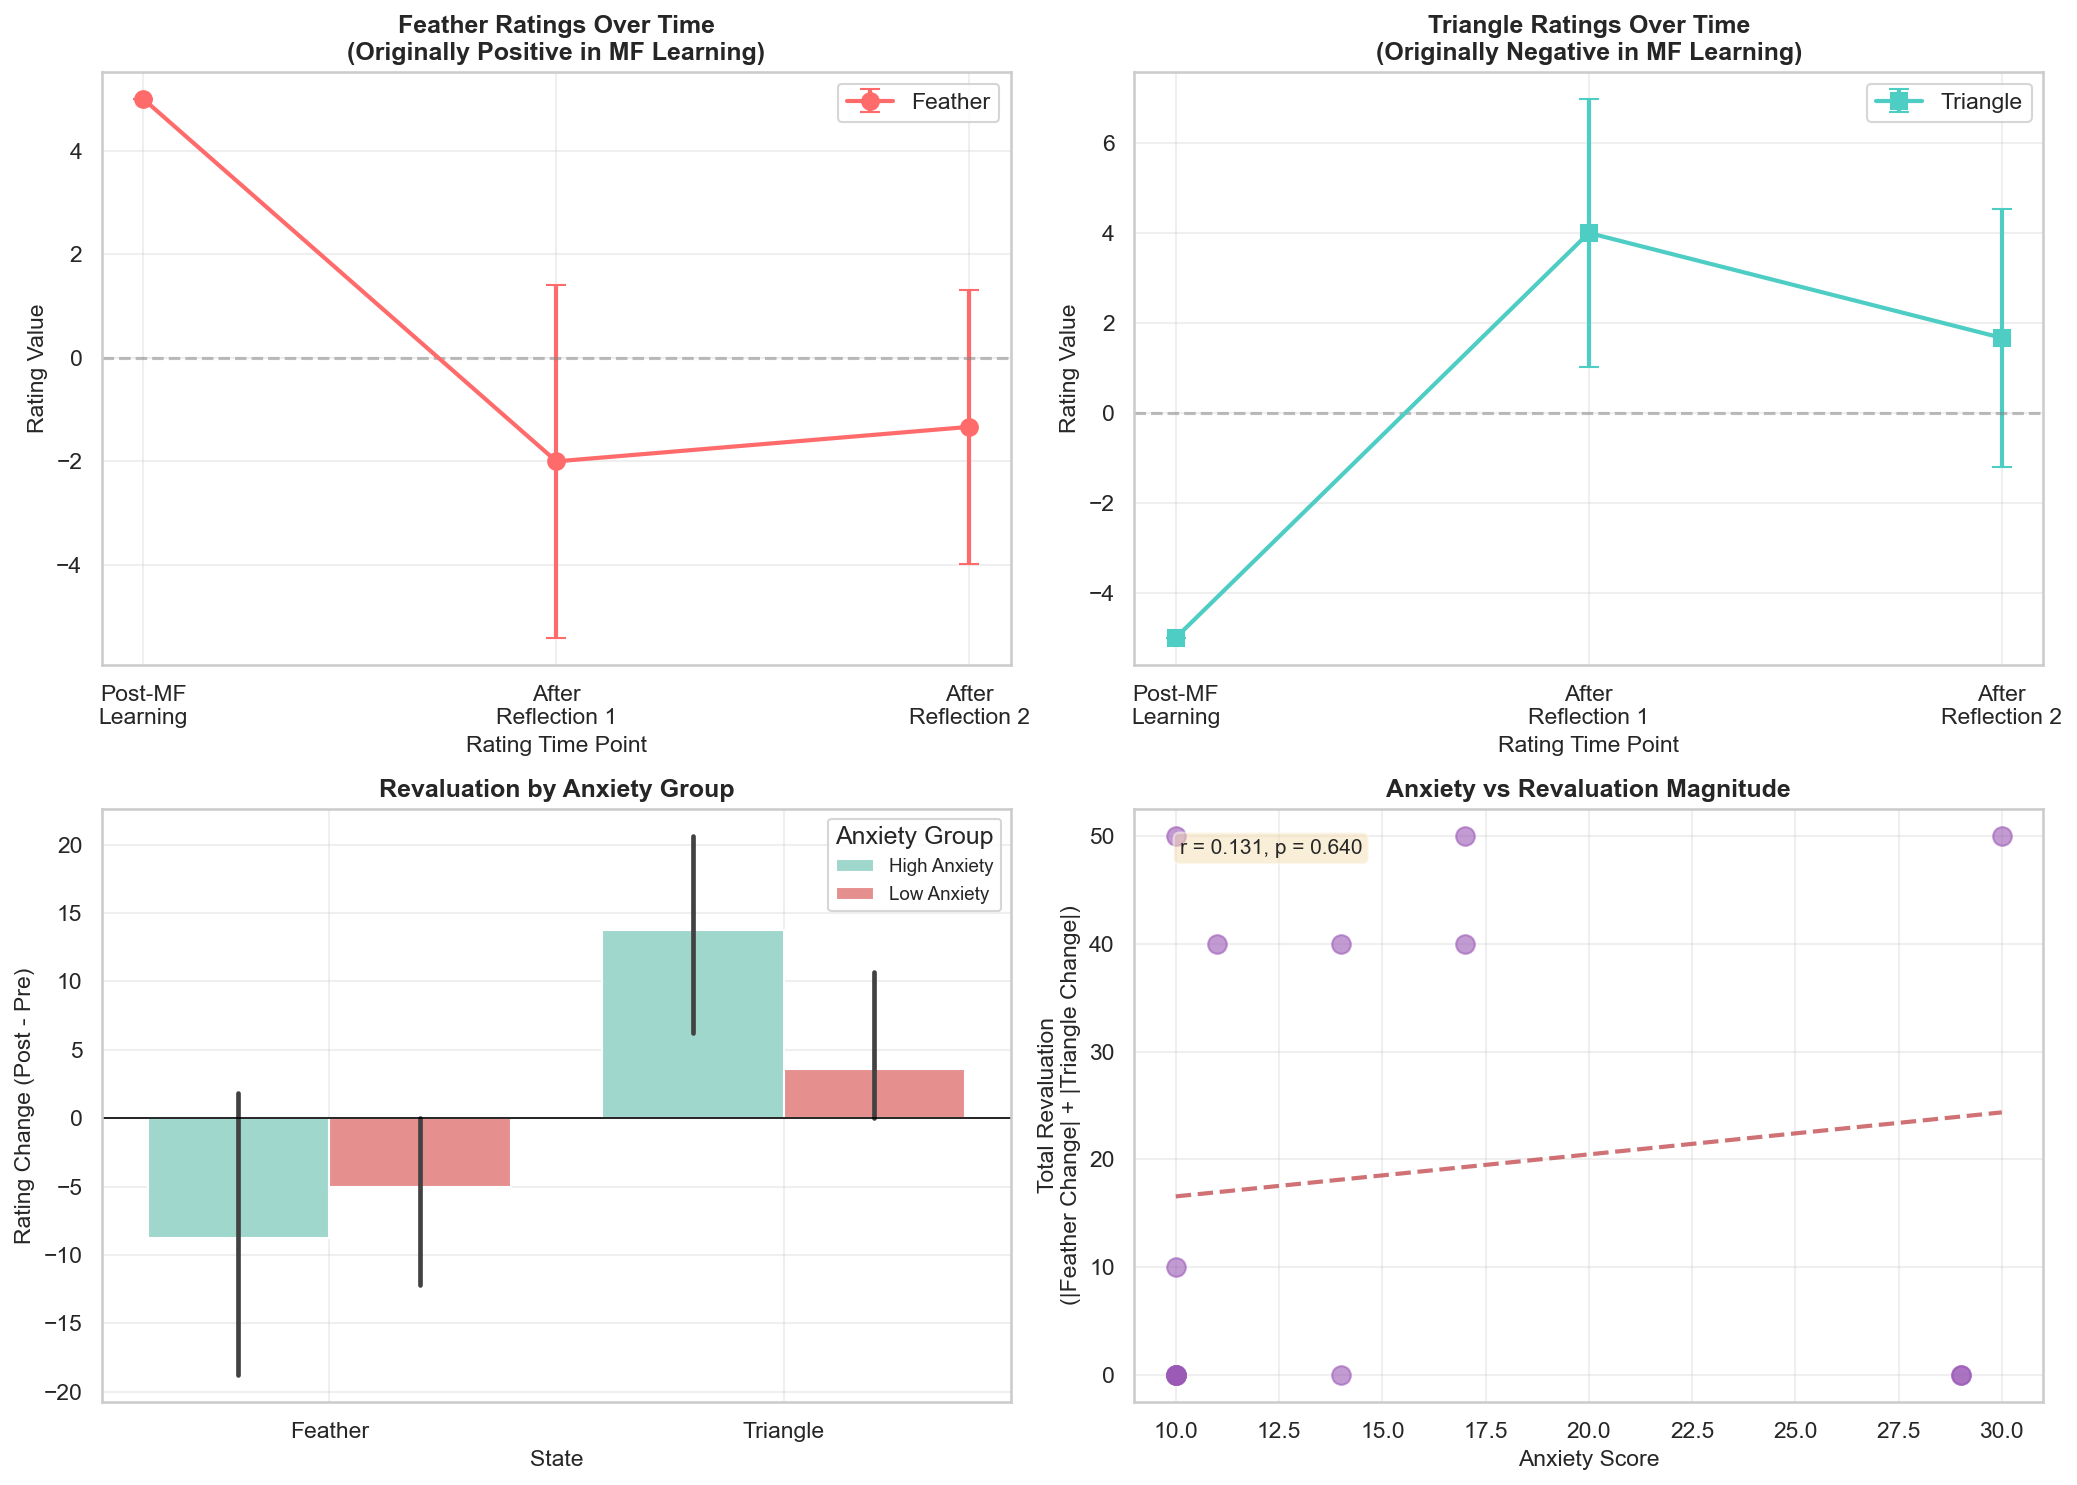

Saved: figure2_query_performance.png


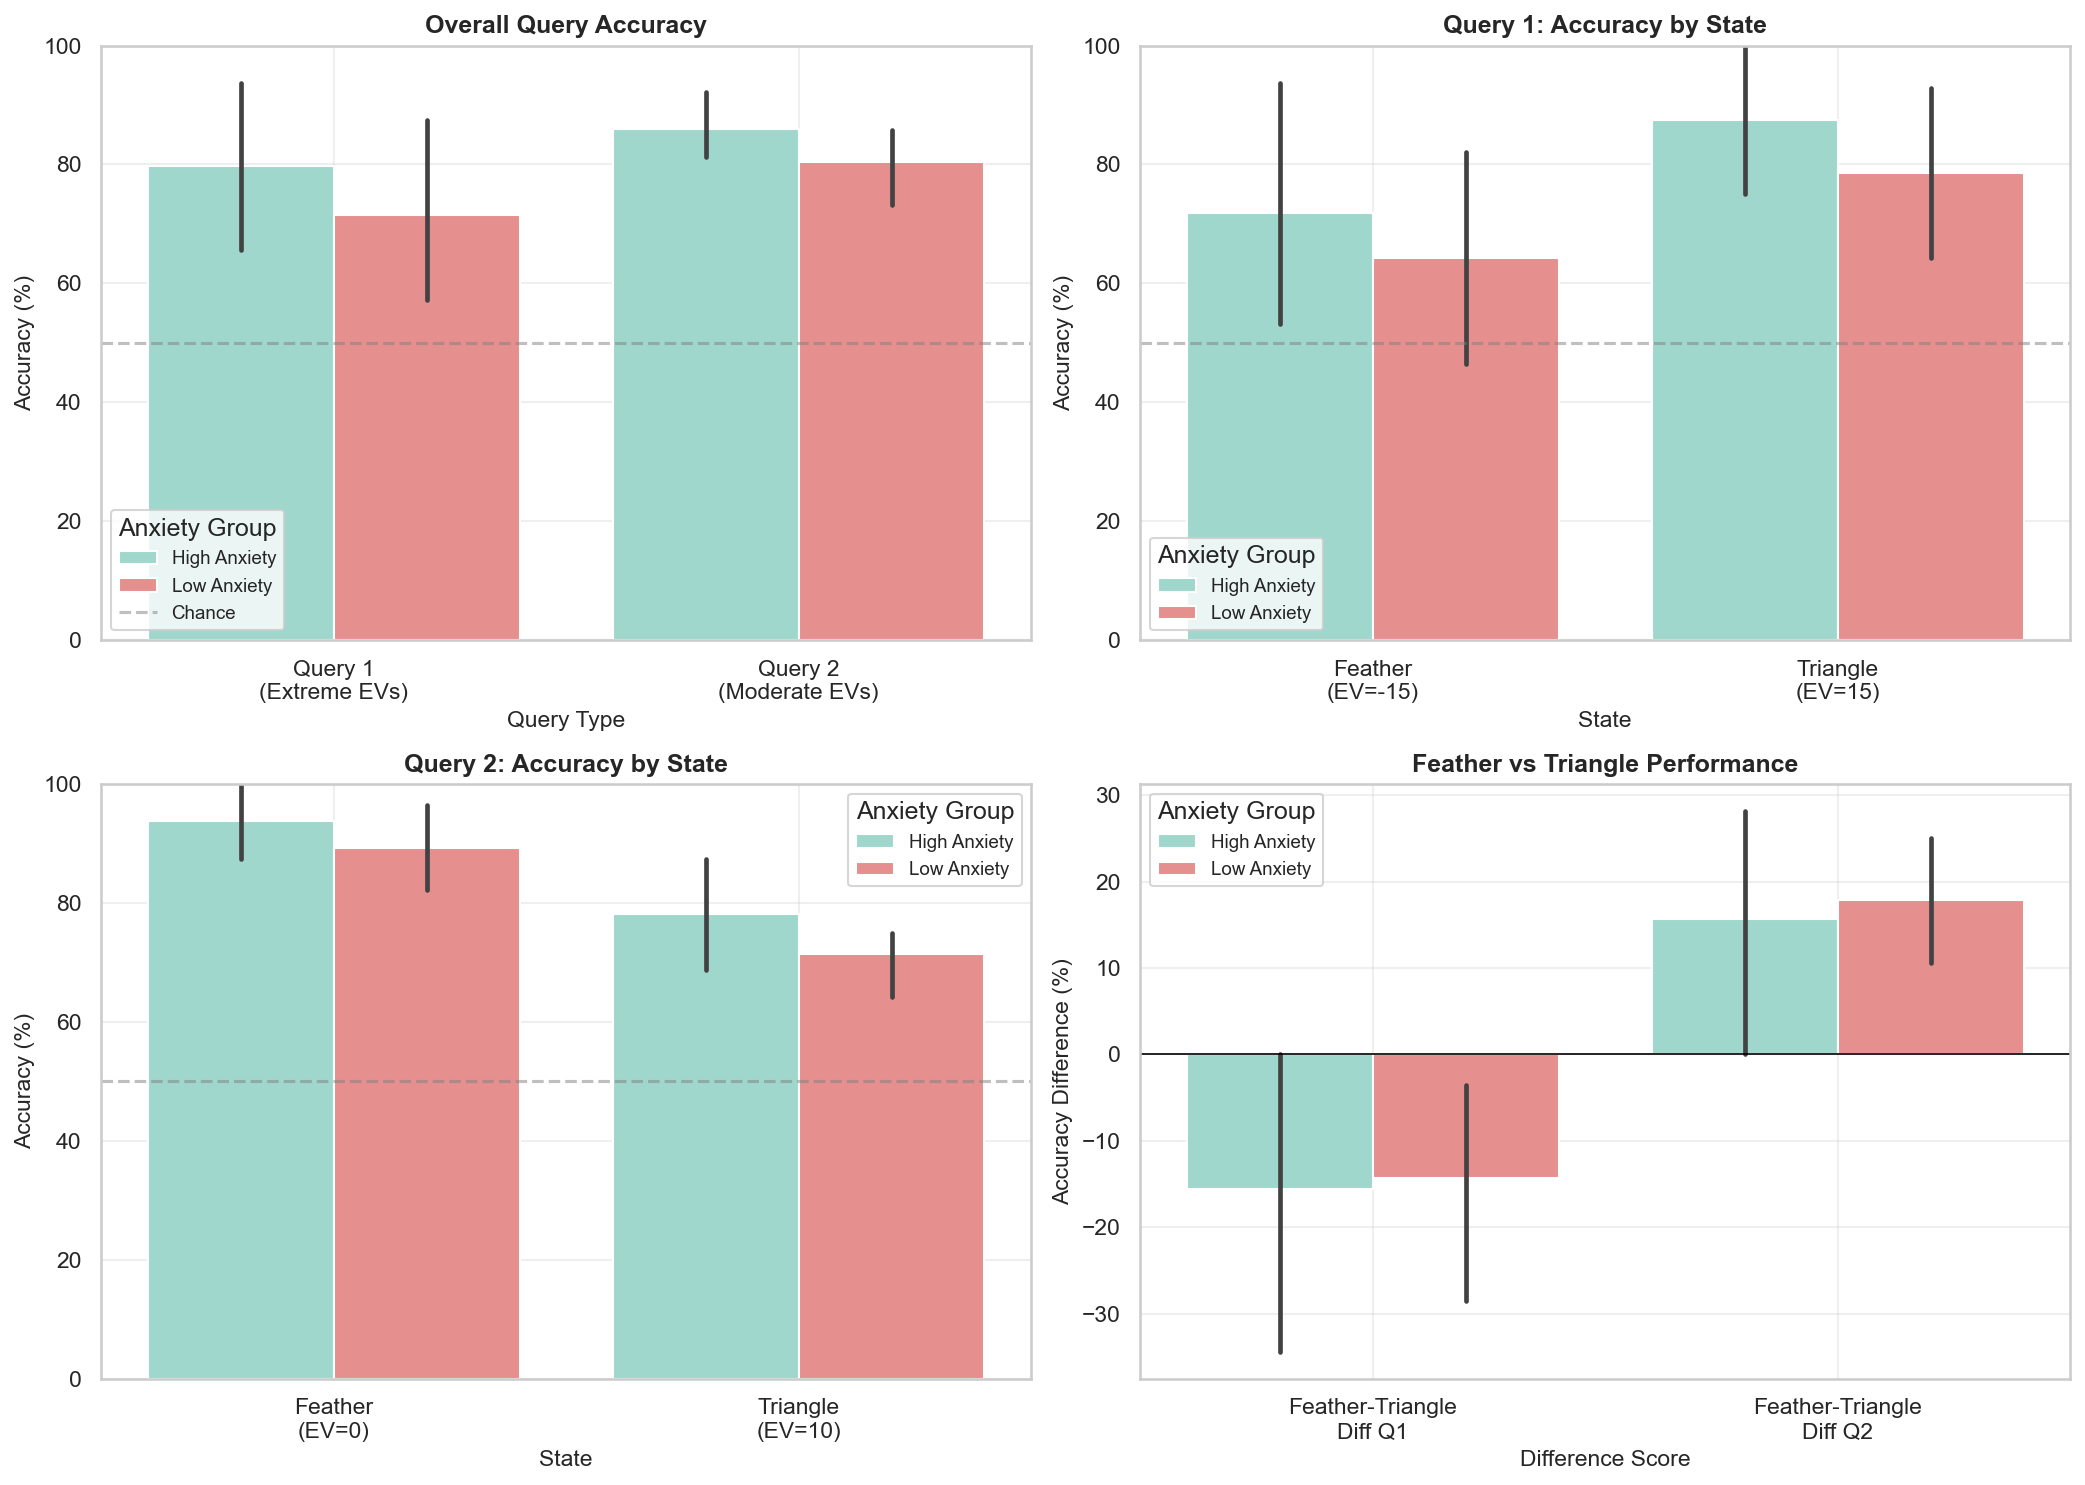

Saved: figure3_ev_difference_analysis.png


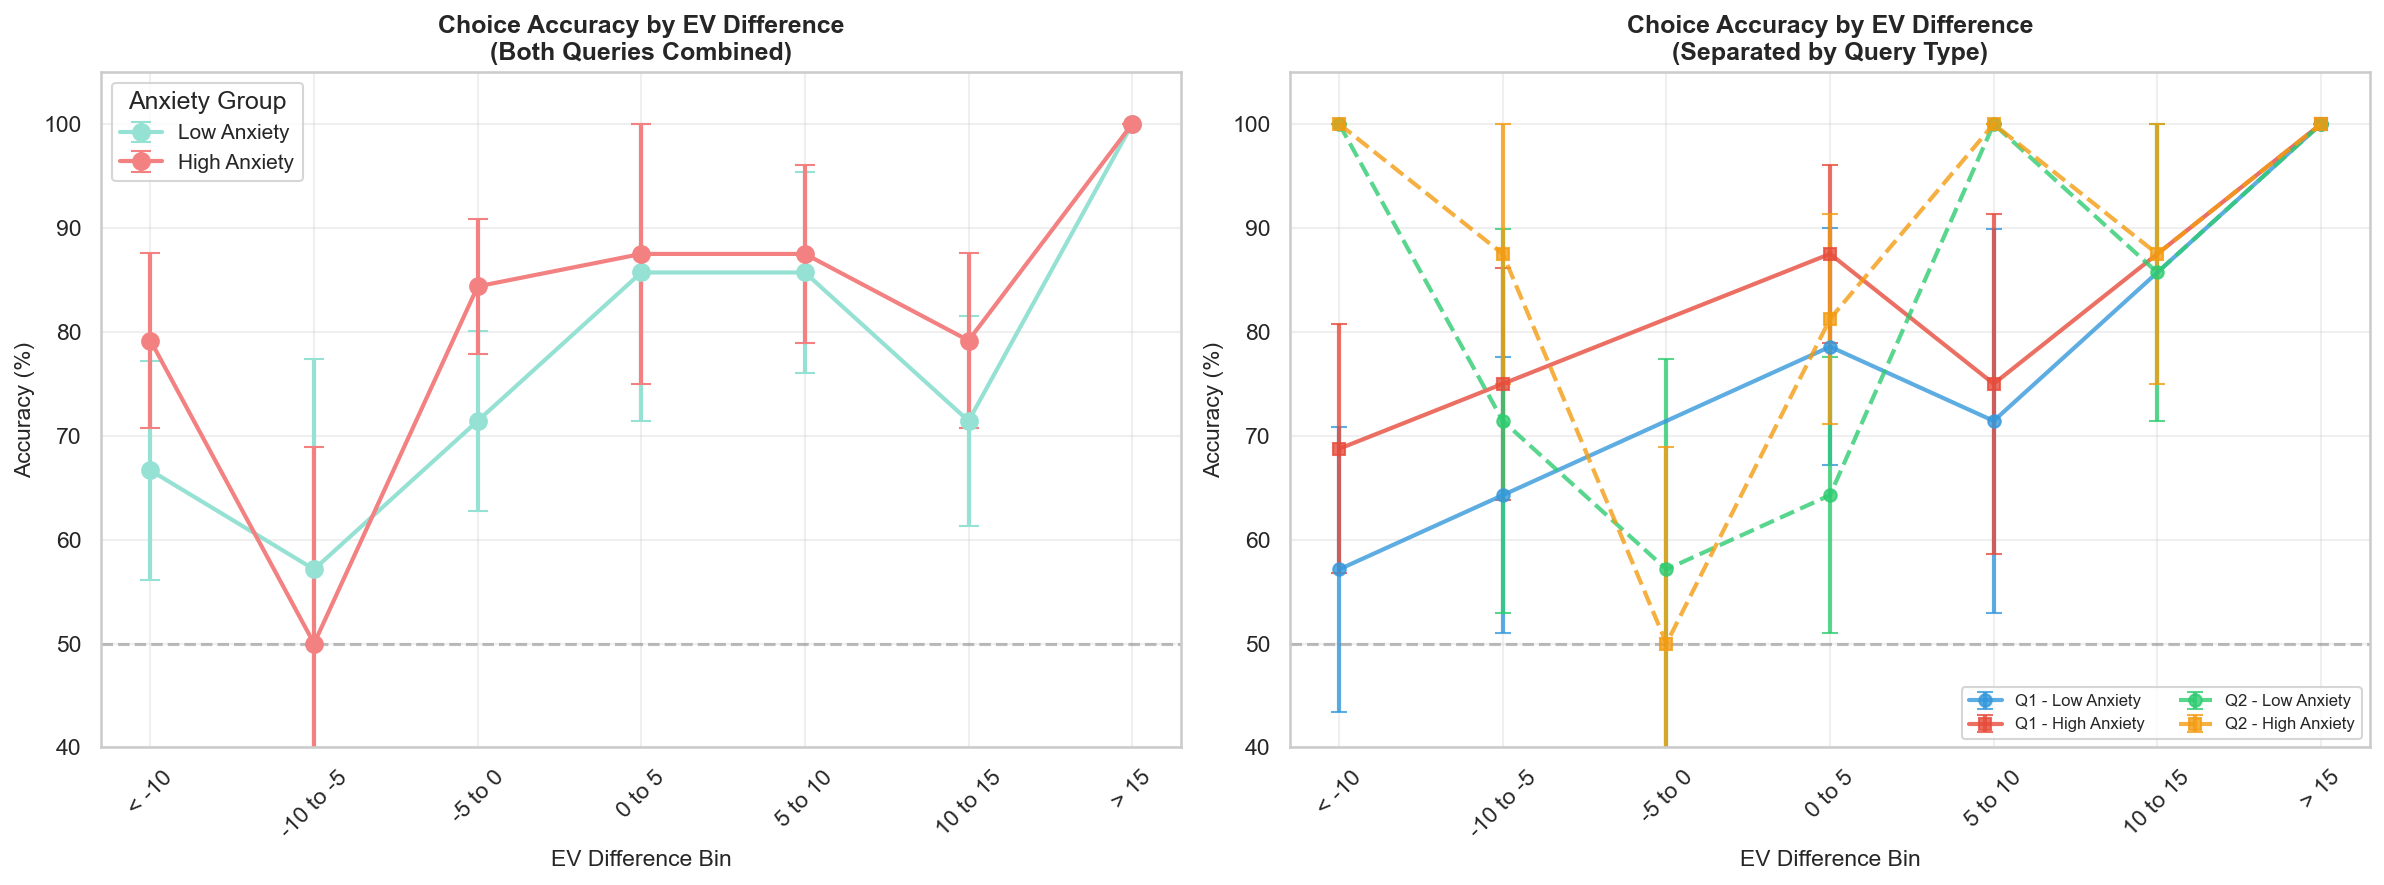

Saved: figure4_anxiety_correlations.png


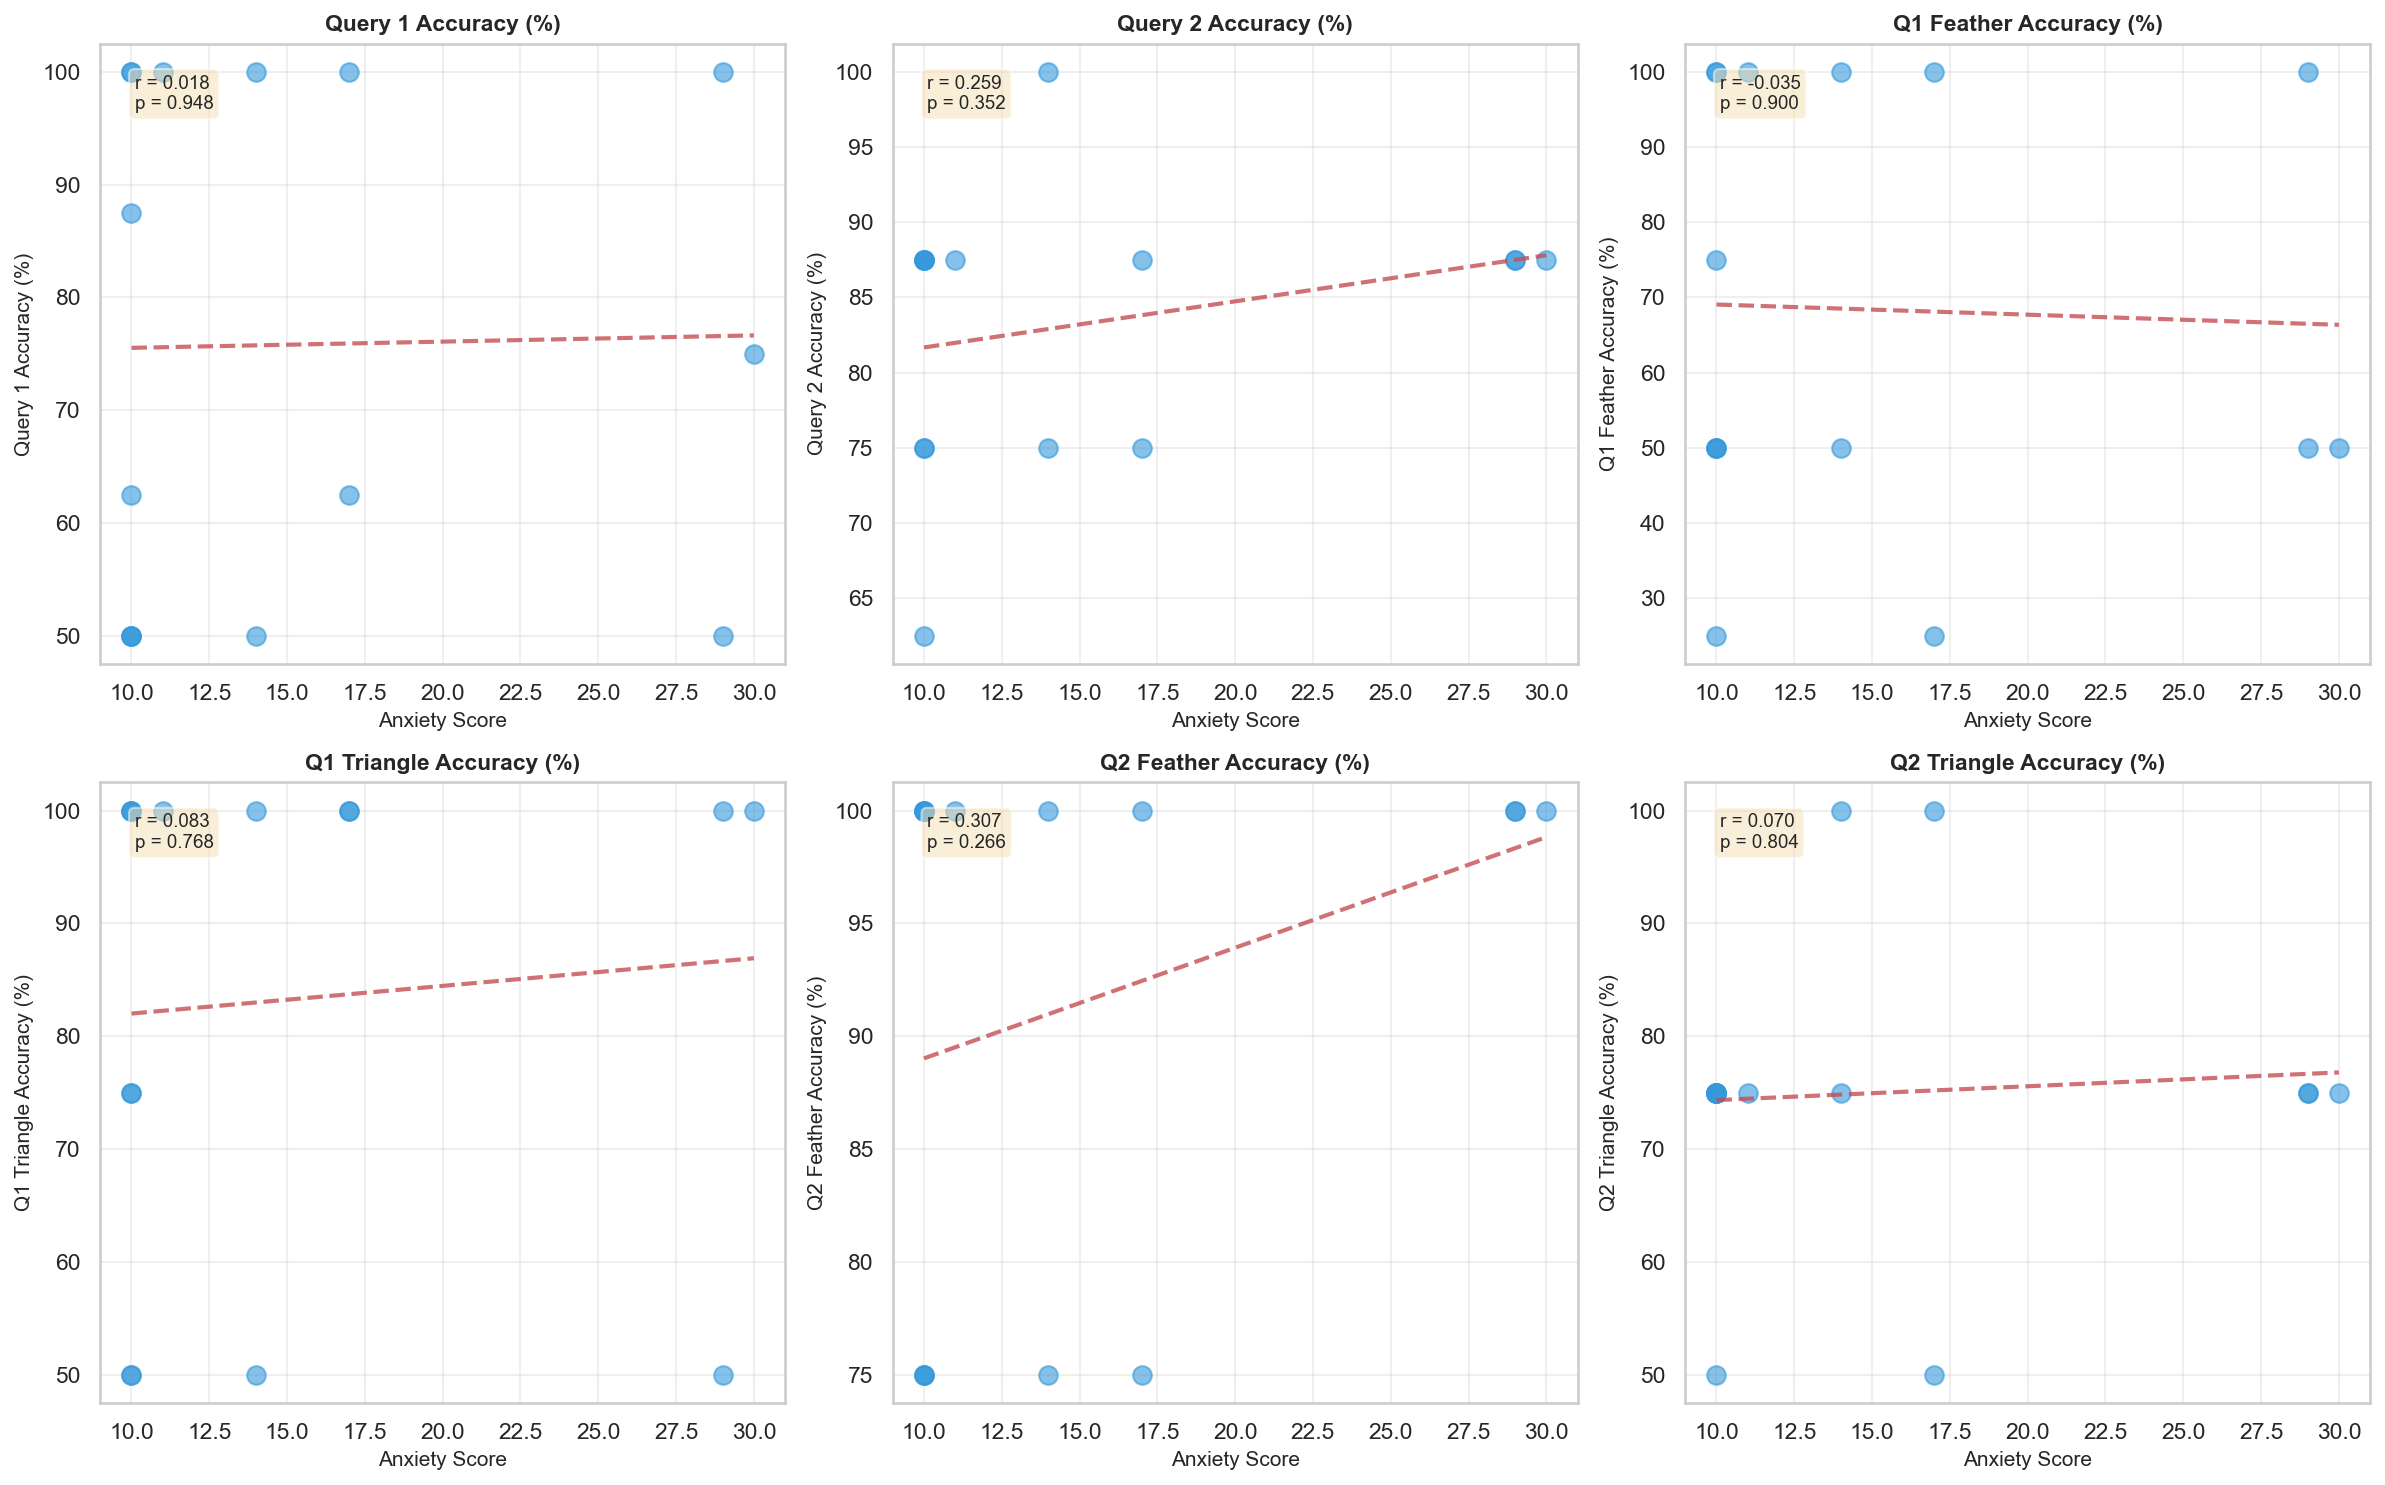

Saved: figure5_additional_analyses.png


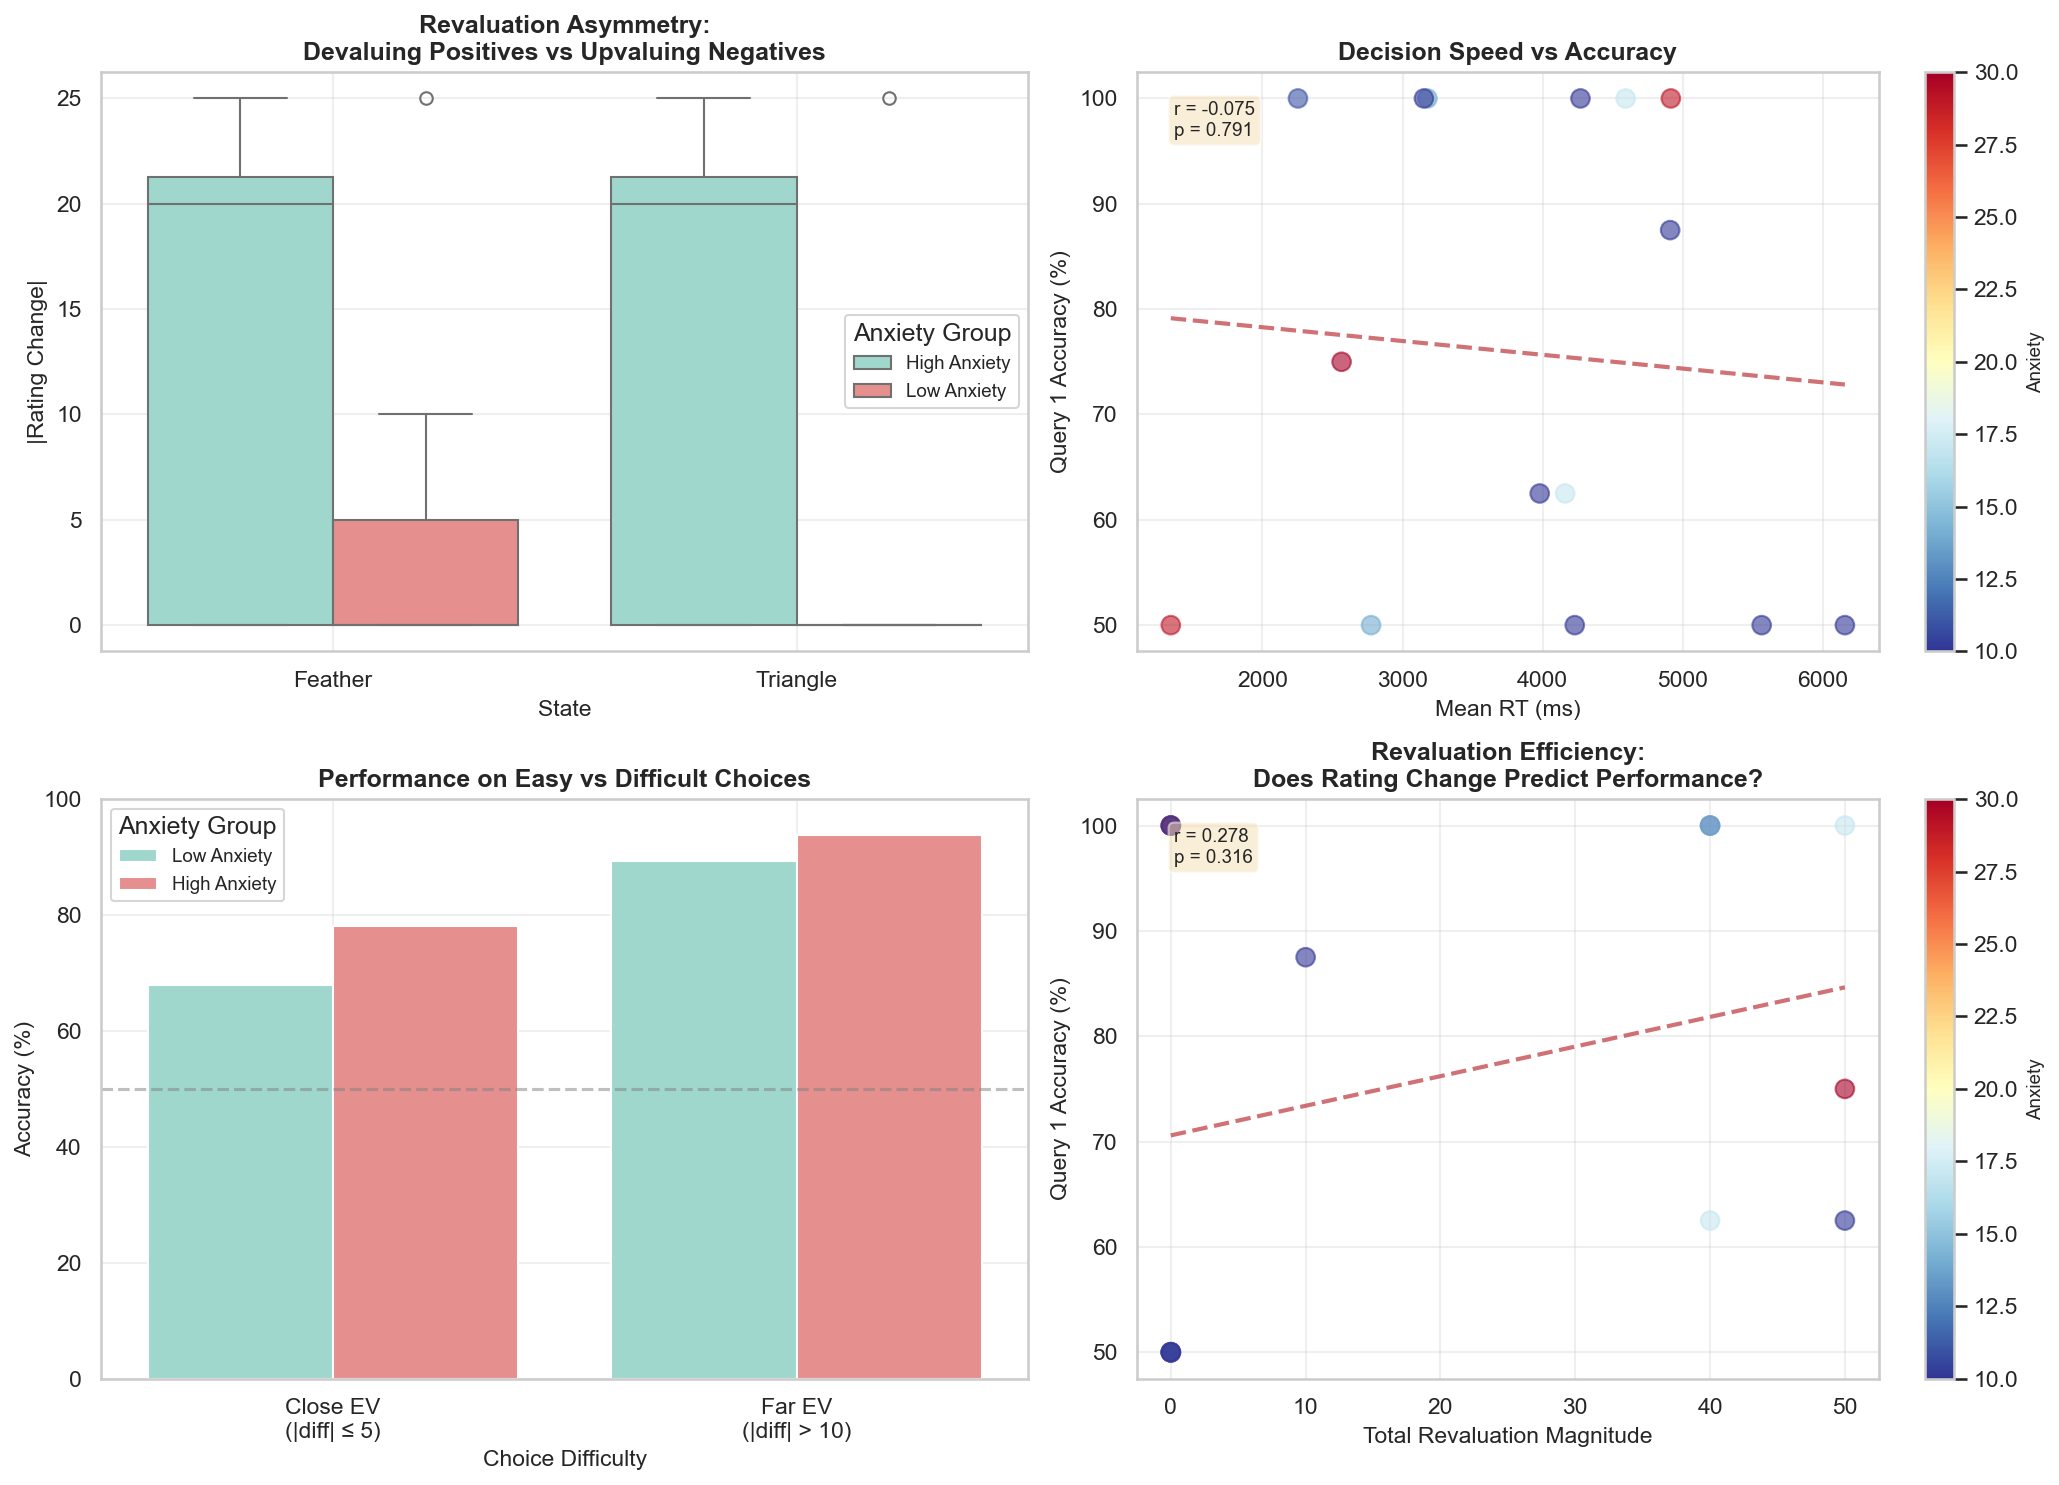

Saved: figure6_correlation_heatmap.png


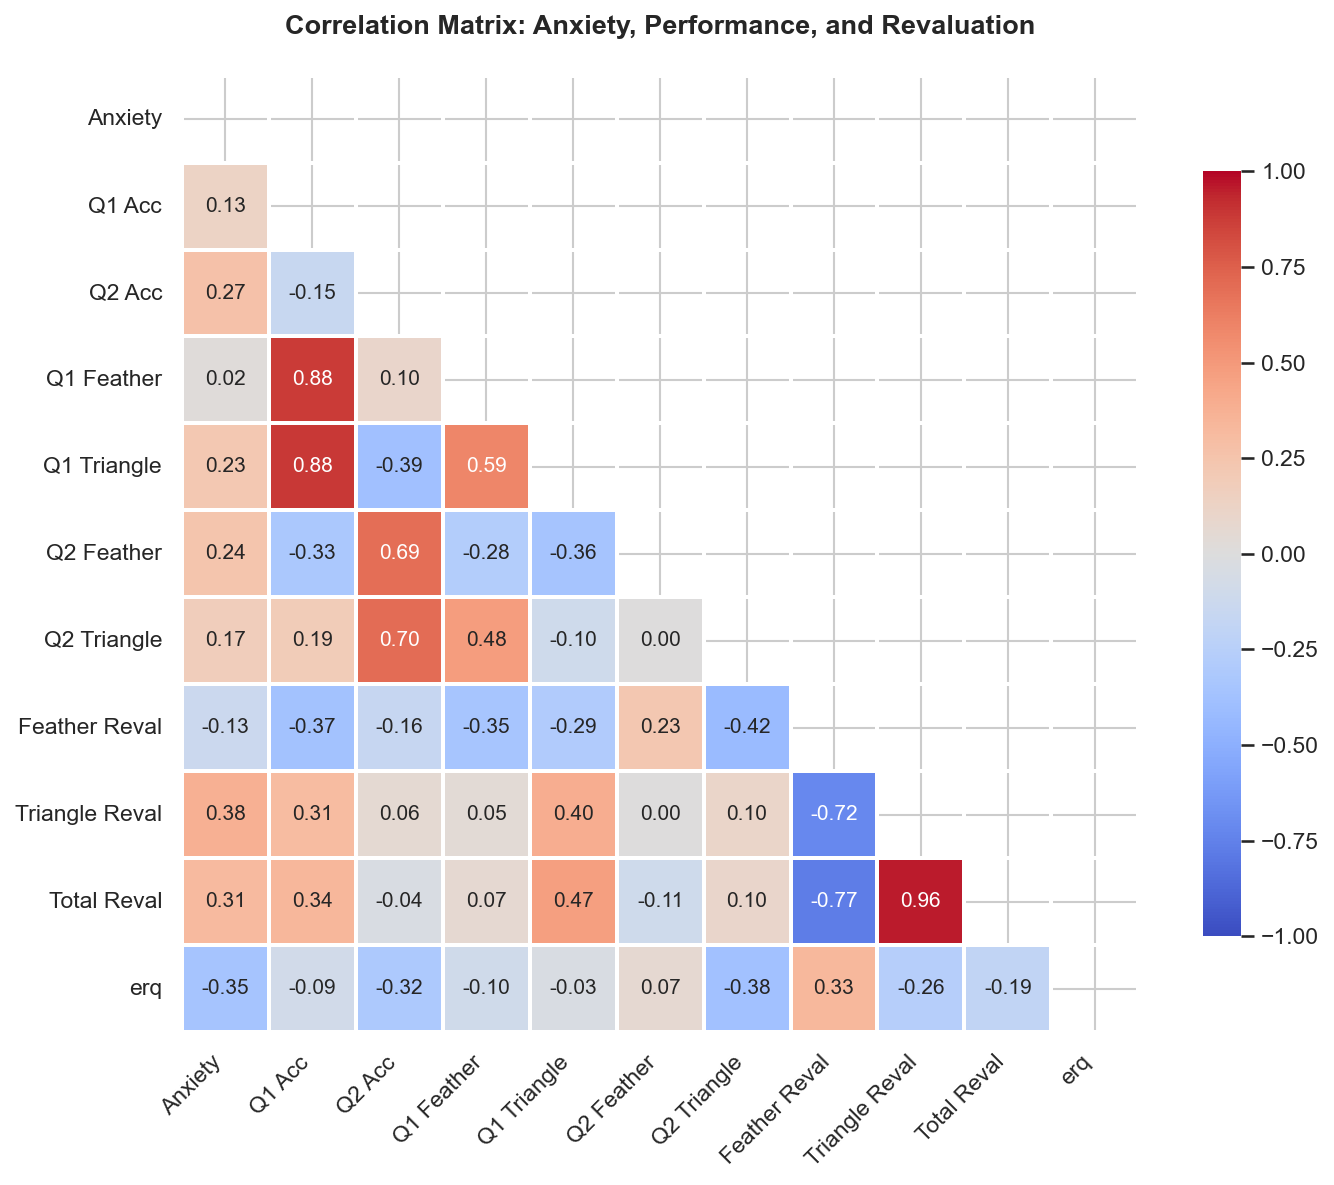


All visualizations created successfully!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_csv('processed_data_with_metrics.csv')
print(len(df))
trial_df = pd.read_csv('trial_level_data.csv')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# ============================================================================
# FIGURE 1: REVALUATION SUCCESS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Rating trajectories for Feather
ax = axes[0, 0]
rating_times = [1, 2, 3]
feather_means = [df['Feather_Rating_1'].mean(), df['Feather_Rating_2'].mean(), df['Feather_Rating_3'].mean()]
feather_sems = [df['Feather_Rating_1'].sem(), df['Feather_Rating_2'].sem(), df['Feather_Rating_3'].sem()]

ax.errorbar(rating_times, feather_means, yerr=feather_sems, marker='o', markersize=8, 
            linewidth=2, capsize=5, label='Feather', color='#FF6B6B')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Rating Value', fontsize=11)
ax.set_title('Feather Ratings Over Time\n(Originally Positive in MF Learning)', fontsize=12, fontweight='bold')
ax.set_xticks(rating_times)
ax.set_xticklabels(['Post-MF\nLearning', 'After\nReflection 1', 'After\nReflection 2'])
ax.legend()
ax.grid(alpha=0.3)

# Panel B: Rating trajectories for Triangle
ax = axes[0, 1]
triangle_means = [df['Triangle_Rating_1'].mean(), df['Triangle_Rating_2'].mean(), df['Triangle_Rating_3'].mean()]
triangle_sems = [df['Triangle_Rating_1'].sem(), df['Triangle_Rating_2'].sem(), df['Triangle_Rating_3'].sem()]

ax.errorbar(rating_times, triangle_means, yerr=triangle_sems, marker='s', markersize=8,
            linewidth=2, capsize=5, label='Triangle', color='#4ECDC4')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Rating Value', fontsize=11)
ax.set_title('Triangle Ratings Over Time\n(Originally Negative in MF Learning)', fontsize=12, fontweight='bold')
ax.set_xticks(rating_times)
ax.set_xticklabels(['Post-MF\nLearning', 'After\nReflection 1', 'After\nReflection 2'])
ax.legend()
ax.grid(alpha=0.3)

# Panel C: Revaluation magnitude by anxiety group
ax = axes[1, 0]
data_for_plot = []
for _, row in df.iterrows():
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'State': 'Feather', 'Revaluation': row['Feather_Revaluation']})
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'State': 'Triangle', 'Revaluation': row['Triangle_Revaluation']})

plot_df = pd.DataFrame(data_for_plot)
sns.barplot(data=plot_df, x='State', y='Revaluation', hue='Anxiety', ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Rating Change (Post - Pre)', fontsize=11)
ax.set_title('Revaluation by Anxiety Group', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Scatter plot - total revaluation vs anxiety
ax = axes[1, 1]
ax.scatter(df['Anxiety_Total'], df['Total_Revaluation'], alpha=0.6, s=80, color='#9B59B6')
z = np.polyfit(df['Anxiety_Total'].dropna(), df['Total_Revaluation'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['Anxiety_Total'].min(), df['Anxiety_Total'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

r, p_val = stats.pearsonr(df['Anxiety_Total'].dropna(), df['Total_Revaluation'].dropna())
ax.text(0.05, 0.95, f'r = {r:.3f}, p = {p_val:.3f}', transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Anxiety Score', fontsize=11)
ax.set_ylabel('Total Revaluation\n(|Feather Change| + |Triangle Change|)', fontsize=11)
ax.set_title('Anxiety vs Revaluation Magnitude', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure1_revaluation.png', dpi=300, bbox_inches='tight')
print("Saved: figure1_revaluation.png")
plt.show()

# ============================================================================
# FIGURE 2: QUERY PERFORMANCE BY STATE AND ANXIETY
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Overall query accuracy by anxiety group
ax = axes[0, 0]
data_for_plot = []
for _, row in df.iterrows():
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'Query': 'Query 1\n(Extreme EVs)', 'Accuracy': row['Q1_Accuracy']})
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'Query': 'Query 2\n(Moderate EVs)', 'Accuracy': row['Q2_Accuracy']})

plot_df = pd.DataFrame(data_for_plot)
sns.barplot(data=plot_df, x='Query', y='Accuracy', hue='Anxiety', ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_xlabel('Query Type', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Overall Query Accuracy', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.set_ylim([0, 100])
ax.grid(alpha=0.3)

# Panel B: State-specific accuracy for Query 1
ax = axes[0, 1]
data_for_plot = []
for _, row in df.iterrows():
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'State': 'Feather\n(EV=-15)', 'Accuracy': row['Q1_Feather_Acc']})
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'State': 'Triangle\n(EV=15)', 'Accuracy': row['Q1_Triangle_Acc']})

plot_df = pd.DataFrame(data_for_plot)
sns.barplot(data=plot_df, x='State', y='Accuracy', hue='Anxiety', ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Query 1: Accuracy by State', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.set_ylim([0, 100])
ax.grid(alpha=0.3)

# Panel C: State-specific accuracy for Query 2
ax = axes[1, 0]
data_for_plot = []
for _, row in df.iterrows():
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'State': 'Feather\n(EV=0)', 'Accuracy': row['Q2_Feather_Acc']})
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'State': 'Triangle\n(EV=10)', 'Accuracy': row['Q2_Triangle_Acc']})

plot_df = pd.DataFrame(data_for_plot)
sns.barplot(data=plot_df, x='State', y='Accuracy', hue='Anxiety', ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Query 2: Accuracy by State', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.set_ylim([0, 100])
ax.grid(alpha=0.3)

# Panel D: Difference scores
ax = axes[1, 1]
data_for_plot = []
for _, row in df.iterrows():
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'Metric': 'Feather-Triangle\nDiff Q1', 'Value': row['Feather_Triangle_Diff_Q1']})
    data_for_plot.append({'Anxiety': row['Anxiety_Group'], 'Metric': 'Feather-Triangle\nDiff Q2', 'Value': row['Feather_Triangle_Diff_Q2']})

plot_df = pd.DataFrame(data_for_plot)
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Anxiety', ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Difference Score', fontsize=11)
ax.set_ylabel('Accuracy Difference (%)', fontsize=11)
ax.set_title('Feather vs Triangle Performance', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure2_query_performance.png', dpi=300, bbox_inches='tight')
print("Saved: figure2_query_performance.png")
plt.show()

# ============================================================================
# FIGURE 3: EV DIFFERENCE ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Accuracy by EV difference (collapsed across queries)
ax = axes[0]
ev_accuracy = trial_df.groupby(['ev_diff_bin', 'anxiety_group'])['correct'].agg(['mean', 'sem']).reset_index()
ev_accuracy['mean'] *= 100
ev_accuracy['sem'] *= 100

for anxiety_group in ['Low Anxiety', 'High Anxiety']:
    data = ev_accuracy[ev_accuracy['anxiety_group'] == anxiety_group]
    color = '#95E1D3' if anxiety_group == 'Low Anxiety' else '#F38181'
    ax.errorbar(range(len(data)), data['mean'], yerr=data['sem'], 
                marker='o', markersize=8, linewidth=2, capsize=5, 
                label=anxiety_group, color=color)

ax.set_xlabel('EV Difference Bin', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Choice Accuracy by EV Difference\n(Both Queries Combined)', fontsize=12, fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels(['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 15', '> 15'], rotation=45)
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.legend(title='Anxiety Group', fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([40, 105])

# Panel B: Accuracy by EV difference separated by query
ax = axes[1]
ev_query_accuracy = trial_df.groupby(['query', 'ev_diff_bin', 'anxiety_group'])['correct'].agg(['mean', 'sem']).reset_index()
ev_query_accuracy['mean'] *= 100
ev_query_accuracy['sem'] *= 100

# Create plot with separate lines for each query x anxiety combination
markers = {'Low Anxiety': 'o', 'High Anxiety': 's'}
colors_q1 = {'Low Anxiety': '#3498DB', 'High Anxiety': '#E74C3C'}
colors_q2 = {'Low Anxiety': '#2ECC71', 'High Anxiety': '#F39C12'}

for query in [1, 2]:
    for anxiety_group in ['Low Anxiety', 'High Anxiety']:
        data = ev_query_accuracy[(ev_query_accuracy['query'] == query) & 
                                  (ev_query_accuracy['anxiety_group'] == anxiety_group)]
        
        color = colors_q1[anxiety_group] if query == 1 else colors_q2[anxiety_group]
        linestyle = '-' if query == 1 else '--'
        label = f'Q{query} - {anxiety_group}'
        
        # Only plot if we have data
        if len(data) > 0:
            x_vals = []
            y_vals = []
            yerr_vals = []
            
            for i, bin_label in enumerate(['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 15', '> 15']):
                bin_data = data[data['ev_diff_bin'] == bin_label]
                if len(bin_data) > 0:
                    x_vals.append(i)
                    y_vals.append(bin_data['mean'].values[0])
                    yerr_vals.append(bin_data['sem'].values[0])
            
            if len(x_vals) > 0:
                ax.errorbar(x_vals, y_vals, yerr=yerr_vals,
                           marker=markers[anxiety_group], markersize=6, linewidth=2, 
                           capsize=4, label=label, color=color, linestyle=linestyle, alpha=0.8)

ax.set_xlabel('EV Difference Bin', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Choice Accuracy by EV Difference\n(Separated by Query Type)', fontsize=12, fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels(['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 15', '> 15'], rotation=45)
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=8, ncol=2, loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim([40, 105])

plt.tight_layout()
plt.savefig('figure3_ev_difference_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: figure3_ev_difference_analysis.png")
plt.show()

# ============================================================================
# FIGURE 4: ANXIETY CORRELATIONS
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Measures to plot
measures = [
    ('Q1_Accuracy', 'Query 1 Accuracy (%)'),
    ('Q2_Accuracy', 'Query 2 Accuracy (%)'),
    ('Q1_Feather_Acc', 'Q1 Feather Accuracy (%)'),
    ('Q1_Triangle_Acc', 'Q1 Triangle Accuracy (%)'),
    ('Q2_Feather_Acc', 'Q2 Feather Accuracy (%)'),
    ('Q2_Triangle_Acc', 'Q2 Triangle Accuracy (%)')
]

for idx, (measure, title) in enumerate(measures):
    ax = axes[idx // 3, idx % 3]
    
    # Scatter plot
    x = df['Anxiety_Total'].dropna()
    y = df[measure].dropna()
    
    # Get overlapping indices
    valid_idx = df[['Anxiety_Total', measure]].dropna().index
    x_vals = df.loc[valid_idx, 'Anxiety_Total']
    y_vals = df.loc[valid_idx, measure]
    
    if len(x_vals) > 0:
        ax.scatter(x_vals, y_vals, alpha=0.6, s=80, color='#3498DB')
        
        # Add regression line
        z = np.polyfit(x_vals, y_vals, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Add correlation
        r, p_val = stats.pearsonr(x_vals, y_vals)
        ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.3f}', 
                transform=ax.transAxes, fontsize=9, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Anxiety Score', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure4_anxiety_correlations.png', dpi=300, bbox_inches='tight')
print("Saved: figure4_anxiety_correlations.png")
plt.show()

# ============================================================================
# FIGURE 5: ADDITIONAL CLEVER ANALYSES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Revaluation asymmetry
ax = axes[0, 0]
abs_changes = pd.DataFrame({
    'State': ['Feather']*len(df) + ['Triangle']*len(df),
    'Absolute Change': list(abs(df['Feather_Revaluation'])) + list(abs(df['Triangle_Revaluation'])),
    'Anxiety': list(df['Anxiety_Group']) + list(df['Anxiety_Group'])
})
sns.boxplot(data=abs_changes, x='State', y='Absolute Change', hue='Anxiety', 
            ax=ax, palette=['#95E1D3', '#F38181'])
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('|Rating Change|', fontsize=11)
ax.set_title('Revaluation Asymmetry:\nDevaluing Positives vs Upvaluing Negatives', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.grid(alpha=0.3)

# Panel B: RT vs Accuracy
ax = axes[0, 1]
if 'Q1_Mean_RT' in df.columns:
    valid_idx = df[['Q1_Mean_RT', 'Q1_Accuracy']].dropna().index
    x_vals = df.loc[valid_idx, 'Q1_Mean_RT']
    y_vals = df.loc[valid_idx, 'Q1_Accuracy']
    
    ax.scatter(x_vals, y_vals, alpha=0.6, s=80, 
               c=df.loc[valid_idx, 'Anxiety_Total'], cmap='RdYlBu_r')
    
    if len(x_vals) > 0:
        z = np.polyfit(x_vals, y_vals, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        r, p_val = stats.pearsonr(x_vals, y_vals)
        ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.3f}', 
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    cbar = plt.colorbar(ax.scatter(x_vals, y_vals, c=df.loc[valid_idx, 'Anxiety_Total'], 
                                   cmap='RdYlBu_r', s=0), ax=ax)
    cbar.set_label('Anxiety', fontsize=9)

ax.set_xlabel('Mean RT (ms)', fontsize=11)
ax.set_ylabel('Query 1 Accuracy (%)', fontsize=11)
ax.set_title('Decision Speed vs Accuracy', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Panel C: Performance on close vs far EV differences
ax = axes[1, 0]
close_ev_trials = trial_df[abs(trial_df['ev_diff']) <= 5]
far_ev_trials = trial_df[abs(trial_df['ev_diff']) > 10]

data_for_plot = []
for group in ['Low Anxiety', 'High Anxiety']:
    close_acc = close_ev_trials[close_ev_trials['anxiety_group']==group]['correct'].mean() * 100
    far_acc = far_ev_trials[far_ev_trials['anxiety_group']==group]['correct'].mean() * 100
    
    data_for_plot.append({'Anxiety': group, 'Difficulty': 'Close EV\n(|diff| ≤ 5)', 'Accuracy': close_acc})
    data_for_plot.append({'Anxiety': group, 'Difficulty': 'Far EV\n(|diff| > 10)', 'Accuracy': far_acc})

plot_df = pd.DataFrame(data_for_plot)
sns.barplot(data=plot_df, x='Difficulty', y='Accuracy', hue='Anxiety', 
            ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Choice Difficulty', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Performance on Easy vs Difficult Choices', fontsize=12, fontweight='bold')
ax.legend(title='Anxiety Group', fontsize=9)
ax.set_ylim([0, 100])
ax.grid(alpha=0.3)

# Panel D: Revaluation efficiency (rating change predicts performance)
ax = axes[1, 1]
valid_idx = df[['Total_Revaluation', 'Q1_Accuracy']].dropna().index
x_vals = df.loc[valid_idx, 'Total_Revaluation']
y_vals = df.loc[valid_idx, 'Q1_Accuracy']

if len(x_vals) > 0:
    ax.scatter(x_vals, y_vals, alpha=0.6, s=80,
               c=df.loc[valid_idx, 'Anxiety_Total'], cmap='RdYlBu_r')
    
    z = np.polyfit(x_vals, y_vals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    r, p_val = stats.pearsonr(x_vals, y_vals)
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.3f}', 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    cbar = plt.colorbar(ax.scatter(x_vals, y_vals, c=df.loc[valid_idx, 'Anxiety_Total'],
                                   cmap='RdYlBu_r', s=0), ax=ax)
    cbar.set_label('Anxiety', fontsize=9)

ax.set_xlabel('Total Revaluation Magnitude', fontsize=11)
ax.set_ylabel('Query 1 Accuracy (%)', fontsize=11)
ax.set_title('Revaluation Efficiency:\nDoes Rating Change Predict Performance?', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure5_additional_analyses.png', dpi=300, bbox_inches='tight')
print("Saved: figure5_additional_analyses.png")
plt.show()

# ============================================================================
# FIGURE 6: COMPREHENSIVE SUMMARY HEATMAP
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Create correlation matrix
measures_for_heatmap = [
    'Anxiety_Total', 'Q1_Accuracy', 'Q2_Accuracy', 
    'Q1_Feather_Acc', 'Q1_Triangle_Acc',
    'Q2_Feather_Acc', 'Q2_Triangle_Acc',
    'Feather_Revaluation', 'Triangle_Revaluation',
    'Total_Revaluation','ERQ_Cognitive_Reappraisal'
]

corr_matrix = df[measures_for_heatmap].corr(method='spearman')

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Correlation Matrix: Anxiety, Performance, and Revaluation', 
             fontsize=13, fontweight='bold', pad=20)

# Better labels
labels = ['Anxiety', 'Q1 Acc', 'Q2 Acc', 'Q1 Feather', 'Q1 Triangle',
          'Q2 Feather', 'Q2 Triangle', 'Feather Reval', 'Triangle Reval', 'Total Reval','erq']
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.savefig('figure6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: figure6_correlation_heatmap.png")
plt.show()

print("\nAll visualizations created successfully!")


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, spearmanr
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("VALUE-CHOICE CONSISTENCY ANALYSIS")
print("="*80)

# Load data
df = pd.read_csv('filtered_data.csv')
print(len(df))
df['subject_id'] = df['prolific_id']

# Get individual difference measures
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}")

# ============================================================================
# PART 1: VALUE-CHOICE CONSISTENCY CALCULATION
# ============================================================================
print("\n" + "="*80)
print("PART 1: CALCULATING VALUE-CHOICE CONSISTENCY")
print("="*80)

print("""
LOGIC:
For each choice trial, we have:
- A rating (e.g., Feather rated at -5)
- An offer (e.g., -10)
- A choice (0 = take offer, 1 = choose gamble)

Value-consistent choice:
- If rating > offer: should choose gamble (choice = 1)
- If rating < offer: should take offer (choice = 0)
- If rating = offer: either choice is acceptable

We calculate the proportion of value-consistent choices.
""")

# Create consistency scores
consistency_data = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    erq_reapp_group = row['ERQ_Reappraisal_Group']
    
    # For each query, get the relevant rating
    # Query 1: Use Rating 2 (after Reflection 1, before Query 1)
    # Query 2: Use Rating 3 (after Reflection 2, before Query 2)
    
    q1_feather_rating = row['Rating_2_Feather_Val']
    q1_triangle_rating = row['Rating_2_Triangle_Val']
    q2_feather_rating = row['Rating_3_Feather_Val']
    q2_triangle_rating = row['Rating_3_Triangle_Val']
    
    # Initialize counters for each query x state combination
    q1_feather_consistent = 0
    q1_feather_total = 0
    q1_triangle_consistent = 0
    q1_triangle_total = 0
    q2_feather_consistent = 0
    q2_feather_total = 0
    q2_triangle_consistent = 0
    q2_triangle_total = 0
    
    # Query 1
    for trial in range(1, 21):
        state_col = f'Query_1_T{trial}_State'
        offer_col = f'Query_1_T{trial}_FixedOffer'
        choice_col = f'Query_1_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        # Get the appropriate rating
        rating = q1_feather_rating if state == 'Feather' else q1_triangle_rating
        
        # Determine value-consistent choice
        if rating > offer:
            expected_choice = 1  # Should choose gamble
        elif rating < offer:
            expected_choice = 0  # Should take offer
        else:  # rating == offer
            expected_choice = choice  # Either choice is consistent
        
        is_consistent = (choice == expected_choice)
        
        if state == 'Feather':
            q1_feather_consistent += is_consistent
            q1_feather_total += 1
        else:
            q1_triangle_consistent += is_consistent
            q1_triangle_total += 1
    
    # Query 2
    for trial in range(1, 21):
        state_col = f'Query_2_T{trial}_State'
        offer_col = f'Query_2_T{trial}_FixedOffer'
        choice_col = f'Query_2_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        # Get the appropriate rating
        rating = q2_feather_rating if state == 'Feather' else q2_triangle_rating
        
        # Determine value-consistent choice
        if rating > offer:
            expected_choice = 1
        elif rating < offer:
            expected_choice = 0
        else:
            expected_choice = choice
        
        is_consistent = (choice == expected_choice)
        
        if state == 'Feather':
            q2_feather_consistent += is_consistent
            q2_feather_total += 1
        else:
            q2_triangle_consistent += is_consistent
            q2_triangle_total += 1
    
    # Calculate proportions
    q1_feather_consistency = (q1_feather_consistent / q1_feather_total) if q1_feather_total > 0 else np.nan
    q1_triangle_consistency = (q1_triangle_consistent / q1_triangle_total) if q1_triangle_total > 0 else np.nan
    q2_feather_consistency = (q2_feather_consistent / q2_feather_total) if q2_feather_total > 0 else np.nan
    q2_triangle_consistency = (q2_triangle_consistent / q2_triangle_total) if q2_triangle_total > 0 else np.nan
    
    # Overall consistency scores
    q1_total_consistency = np.nanmean([q1_feather_consistency, q1_triangle_consistency])
    q2_total_consistency = np.nanmean([q2_feather_consistency, q2_triangle_consistency])
    overall_consistency = np.nanmean([q1_feather_consistency, q1_triangle_consistency,
                                      q2_feather_consistency, q2_triangle_consistency])
    
    consistency_data.append({
        'subject_id': subject_id,
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group,
        'q1_feather_consistency': q1_feather_consistency,
        'q1_triangle_consistency': q1_triangle_consistency,
        'q2_feather_consistency': q2_feather_consistency,
        'q2_triangle_consistency': q2_triangle_consistency,
        'q1_total_consistency': q1_total_consistency,
        'q2_total_consistency': q2_total_consistency,
        'overall_consistency': overall_consistency,
        # Store ratings for reference
        'q1_feather_rating': q1_feather_rating,
        'q1_triangle_rating': q1_triangle_rating,
        'q2_feather_rating': q2_feather_rating,
        'q2_triangle_rating': q2_triangle_rating
    })

consistency_df = pd.DataFrame(consistency_data)

# ============================================================================
# PART 2: DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*80)
print("PART 2: VALUE-CHOICE CONSISTENCY DESCRIPTIVES")
print("="*80)

print("\nOverall Consistency Scores (Proportion of Value-Consistent Choices):")
print(f"  Query 1 Feather: M={consistency_df['q1_feather_consistency'].mean():.3f}, SD={consistency_df['q1_feather_consistency'].std():.3f}")
print(f"  Query 1 Triangle: M={consistency_df['q1_triangle_consistency'].mean():.3f}, SD={consistency_df['q1_triangle_consistency'].std():.3f}")
print(f"  Query 2 Feather: M={consistency_df['q2_feather_consistency'].mean():.3f}, SD={consistency_df['q2_feather_consistency'].std():.3f}")
print(f"  Query 2 Triangle: M={consistency_df['q2_triangle_consistency'].mean():.3f}, SD={consistency_df['q2_triangle_consistency'].std():.3f}")

print("\nAggregated Consistency:")
print(f"  Query 1 Total: M={consistency_df['q1_total_consistency'].mean():.3f}, SD={consistency_df['q1_total_consistency'].std():.3f}")
print(f"  Query 2 Total: M={consistency_df['q2_total_consistency'].mean():.3f}, SD={consistency_df['q2_total_consistency'].std():.3f}")
print(f"  Overall Total: M={consistency_df['overall_consistency'].mean():.3f}, SD={consistency_df['overall_consistency'].std():.3f}")

# Test if consistency differs by query
t_q1_q2, p_q1_q2 = stats.ttest_rel(consistency_df['q1_total_consistency'], 
                                     consistency_df['q2_total_consistency'])
print(f"\nQuery 1 vs Query 2 consistency: t(19)={t_q1_q2:.3f}, p={p_q1_q2:.4f}")

# Test if consistency differs by state within each query
t_q1_state, p_q1_state = stats.ttest_rel(consistency_df['q1_feather_consistency'],
                                          consistency_df['q1_triangle_consistency'])
t_q2_state, p_q2_state = stats.ttest_rel(consistency_df['q2_feather_consistency'],
                                          consistency_df['q2_triangle_consistency'])

print(f"\nQuery 1 Feather vs Triangle: t={t_q1_state:.3f}, p={p_q1_state:.4f}")
print(f"Query 2 Feather vs Triangle: t={t_q2_state:.3f}, p={p_q2_state:.4f}")

# ============================================================================
# PART 3: CORRELATIONS WITH INDIVIDUAL DIFFERENCES
# ============================================================================
print("\n" + "="*80)
print("PART 3: CORRELATIONS WITH ANXIETY AND ERQ")
print("="*80)

consistency_measures = {
    'Q1 Feather': 'q1_feather_consistency',
    'Q1 Triangle': 'q1_triangle_consistency',
    'Q2 Feather': 'q2_feather_consistency',
    'Q2 Triangle': 'q2_triangle_consistency',
    'Q1 Total': 'q1_total_consistency',
    'Q2 Total': 'q2_total_consistency',
    'Overall Total': 'overall_consistency'
}

individual_diffs = {
    'Anxiety': 'anxiety',
    'ERQ Reappraisal': 'erq_reappraisal',
    'ERQ Suppression': 'erq_suppression'
}

print("\nCorrelation Matrix:")
print("-" * 95)
print(f"{'Consistency Measure':<20} | {'Anxiety':>20} | {'ERQ Reappraisal':>20} | {'ERQ Suppression':>20}")
print("-" * 95)

correlation_results = []

for cons_name, cons_var in consistency_measures.items():
    row_data = {'Measure': cons_name}
    result_str = f"{cons_name:<20} | "
    
    for diff_name, diff_var in individual_diffs.items():
        valid_data = consistency_df[[cons_var, diff_var]].dropna()
        
        if len(valid_data) > 2:
            r, p = spearmanr(valid_data[cons_var], valid_data[diff_var])
            row_data[f'{diff_name}_r'] = r
            row_data[f'{diff_name}_p'] = p
            
            sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            result_str += f"r={r:>6.3f} (p={p:.3f}){sig_marker:<3} | "
        else:
            result_str += f"{'N/A':>20} | "
    
    print(result_str)
    correlation_results.append(row_data)

corr_results_df = pd.DataFrame(correlation_results)

# ============================================================================
# PART 4: MEDIAN SPLIT ANALYSES
# ============================================================================
print("\n" + "="*80)
print("PART 4: MEDIAN SPLIT COMPARISONS")
print("="*80)

print("\n--- ANXIETY MEDIAN SPLIT ---")
print(f"Low Anxiety (n={sum(consistency_df['anxiety_group']=='Low')})")
print(f"High Anxiety (n={sum(consistency_df['anxiety_group']=='High')})")
print("-" * 80)

for cons_name, cons_var in consistency_measures.items():
    low = consistency_df[consistency_df['anxiety_group']=='Low'][cons_var].dropna()
    high = consistency_df[consistency_df['anxiety_group']=='High'][cons_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{cons_name:<20}: Low={low.mean():.3f}, High={high.mean():.3f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:.3f}")

print("\n--- ERQ REAPPRAISAL MEDIAN SPLIT ---")
print(f"Low ERQ-R (n={sum(consistency_df['erq_reapp_group']=='Low')})")
print(f"High ERQ-R (n={sum(consistency_df['erq_reapp_group']=='High')})")
print("-" * 80)

for cons_name, cons_var in consistency_measures.items():
    low = consistency_df[consistency_df['erq_reapp_group']=='Low'][cons_var].dropna()
    high = consistency_df[consistency_df['erq_reapp_group']=='High'][cons_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{cons_name:<20}: Low={low.mean():.3f}, High={high.mean():.3f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:.3f}")

# ============================================================================
# SAVE DATA
# ============================================================================
consistency_df.to_csv('value_choice_consistency.csv', index=False)
corr_results_df.to_csv('consistency_correlations.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - value_choice_consistency.csv")
print("  - consistency_correlations.csv")
print("="*80)


VALUE-CHOICE CONSISTENCY ANALYSIS
15

Sample size: 15
Anxiety: M=15.40, SD=7.63
ERQ Reappraisal: M=32.33, SD=4.61
ERQ Suppression: M=15.00, SD=6.08

PART 1: CALCULATING VALUE-CHOICE CONSISTENCY

LOGIC:
For each choice trial, we have:
- A rating (e.g., Feather rated at -5)
- An offer (e.g., -10)
- A choice (0 = take offer, 1 = choose gamble)

Value-consistent choice:
- If rating > offer: should choose gamble (choice = 1)
- If rating < offer: should take offer (choice = 0)
- If rating = offer: either choice is acceptable

We calculate the proportion of value-consistent choices.


PART 2: VALUE-CHOICE CONSISTENCY DESCRIPTIVES

Overall Consistency Scores (Proportion of Value-Consistent Choices):
  Query 1 Feather: M=0.800, SD=0.254
  Query 1 Triangle: M=0.800, SD=0.271
  Query 2 Feather: M=0.917, SD=0.181
  Query 2 Triangle: M=0.900, SD=0.184

Aggregated Consistency:
  Query 1 Total: M=0.800, SD=0.230
  Query 2 Total: M=0.908, SD=0.110
  Overall Total: M=0.854, SD=0.152

Query 1 vs Query 2

Creating value-choice consistency visualizations...
15
Saved: consistency_fig1_heatmaps.png


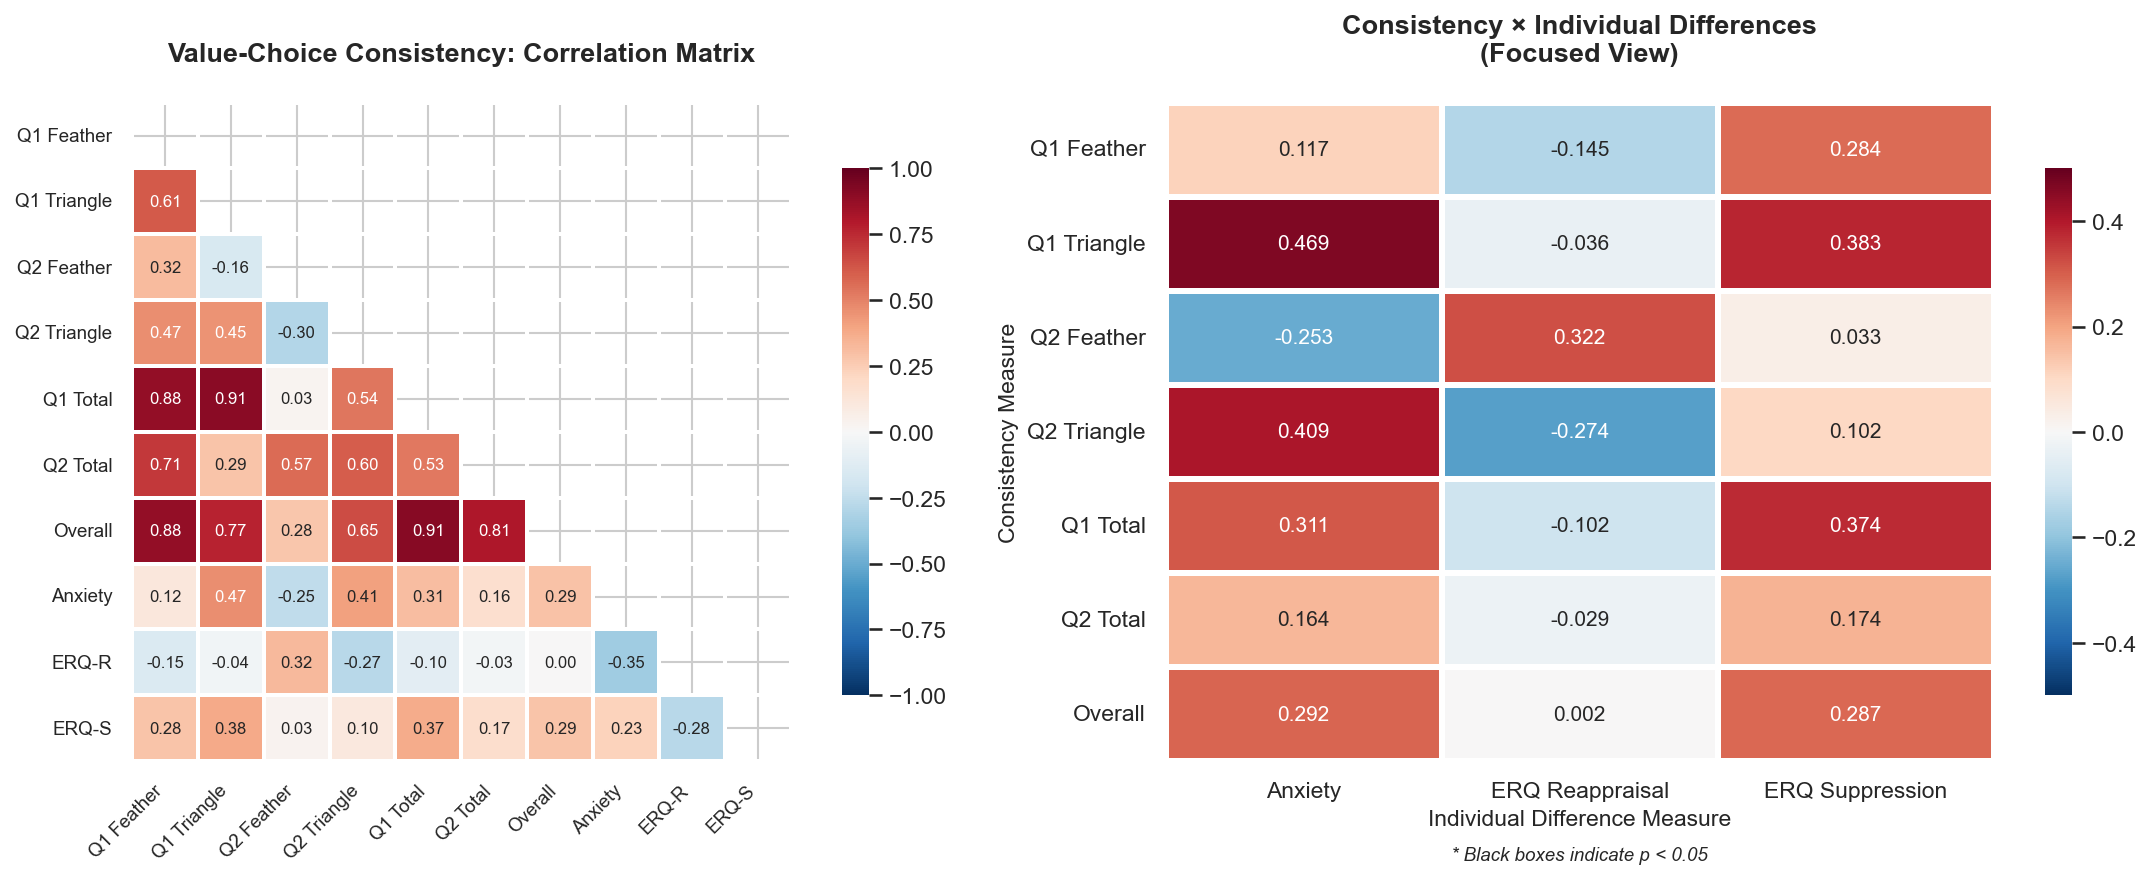

Saved: consistency_fig2_descriptives.png


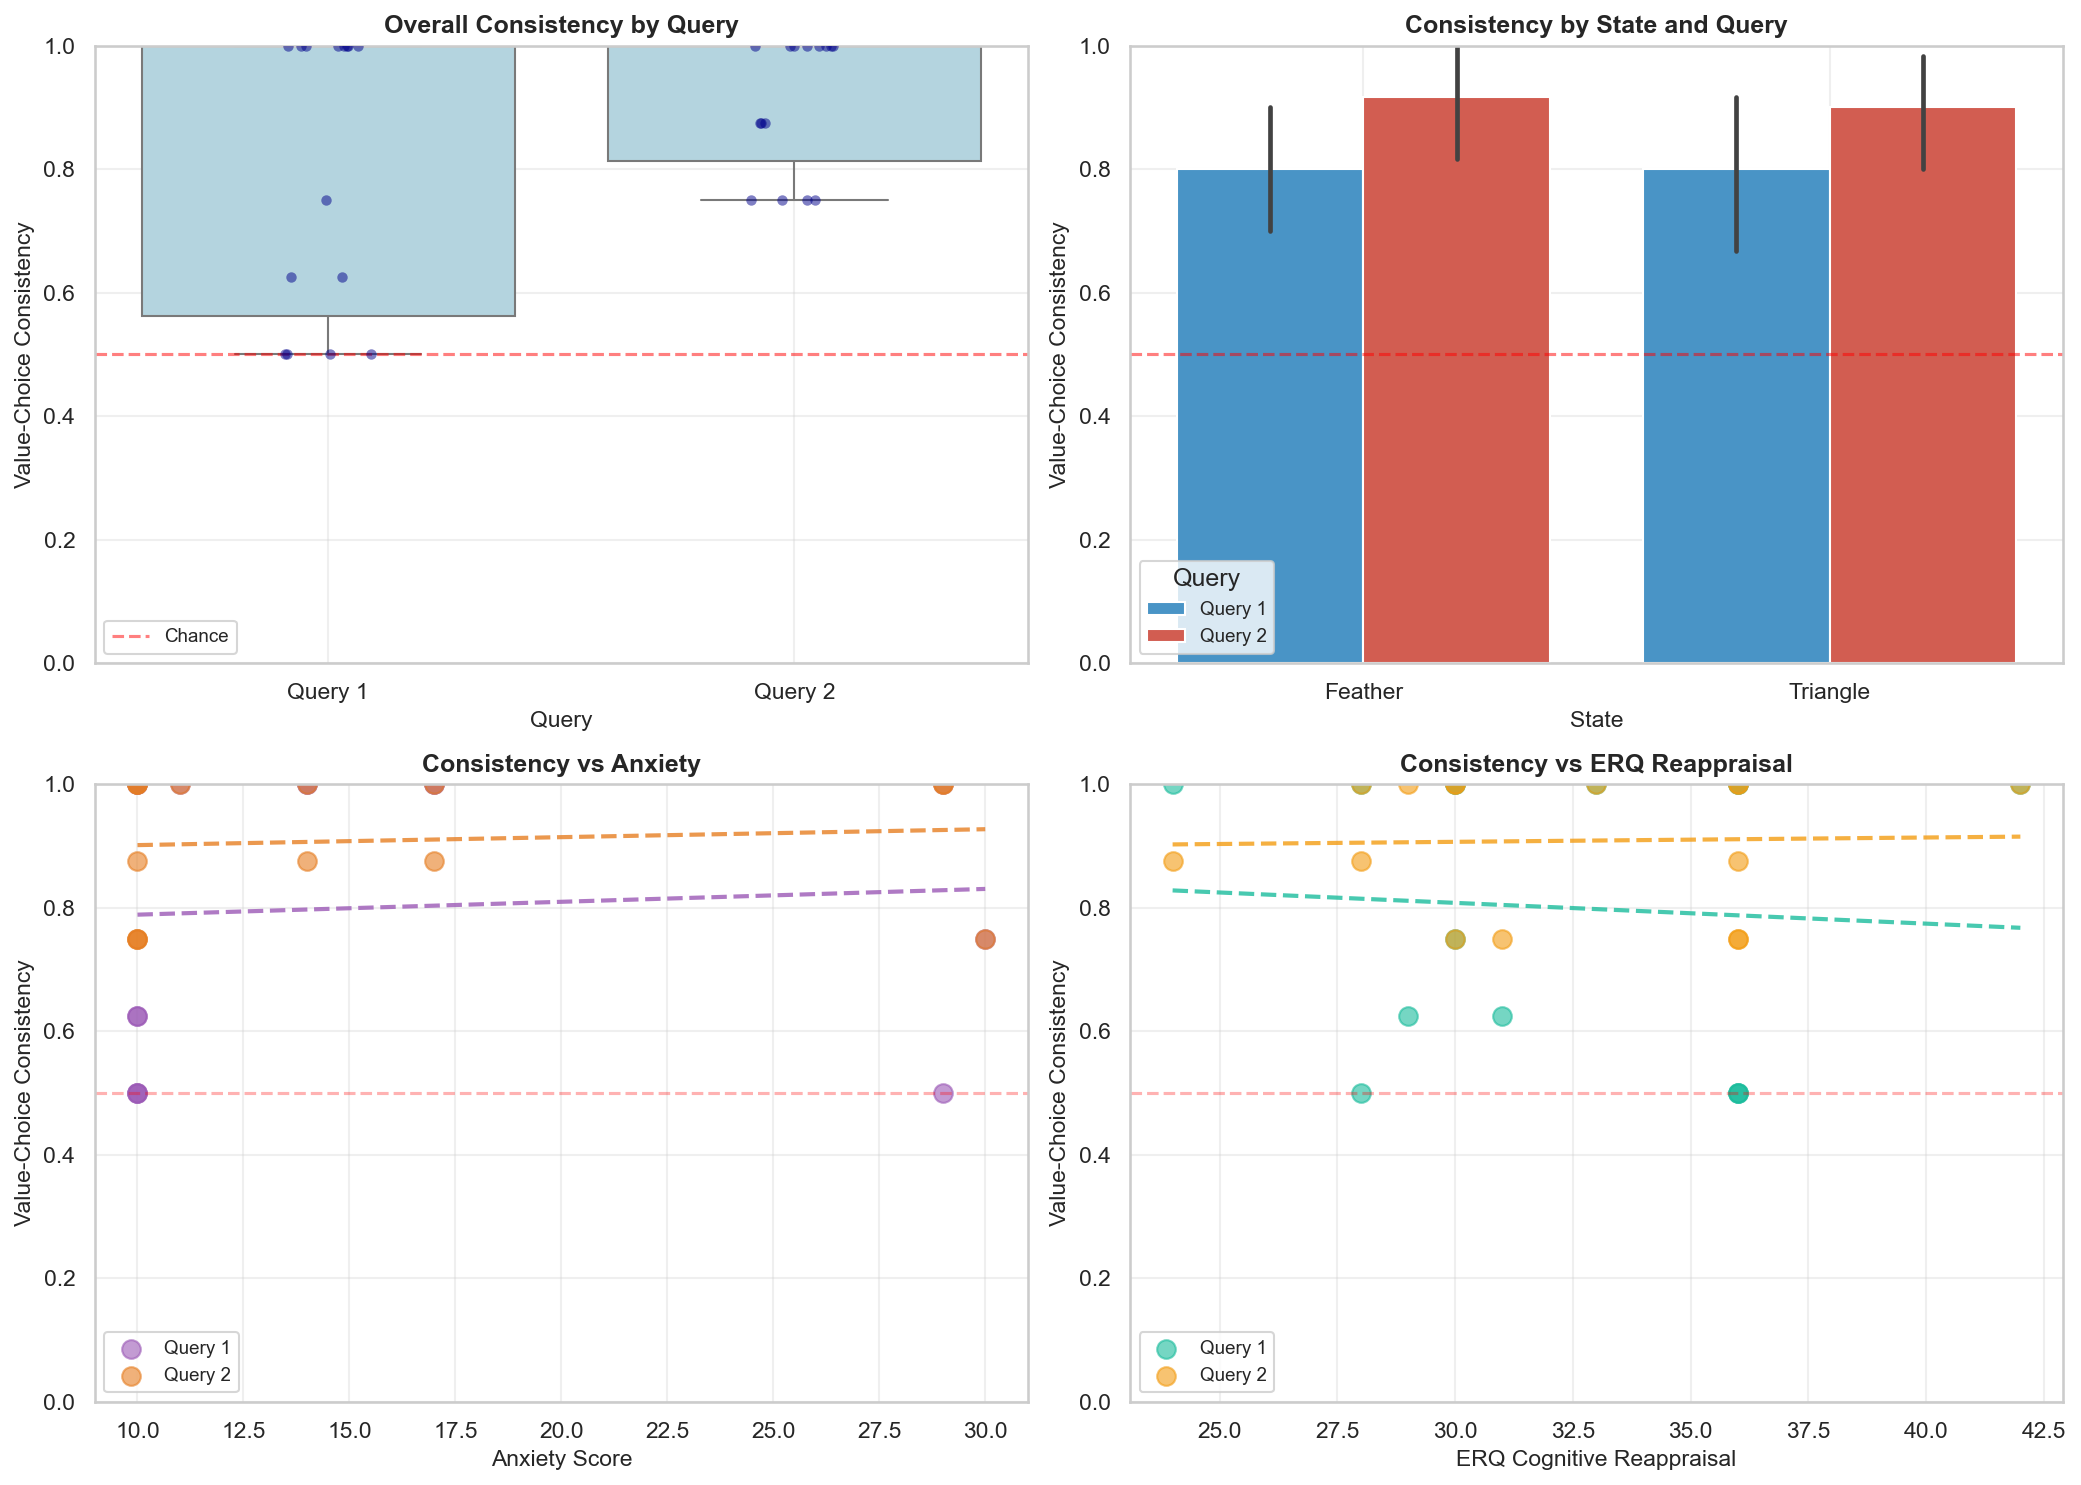

Saved: consistency_fig3_median_splits_anxiety.png


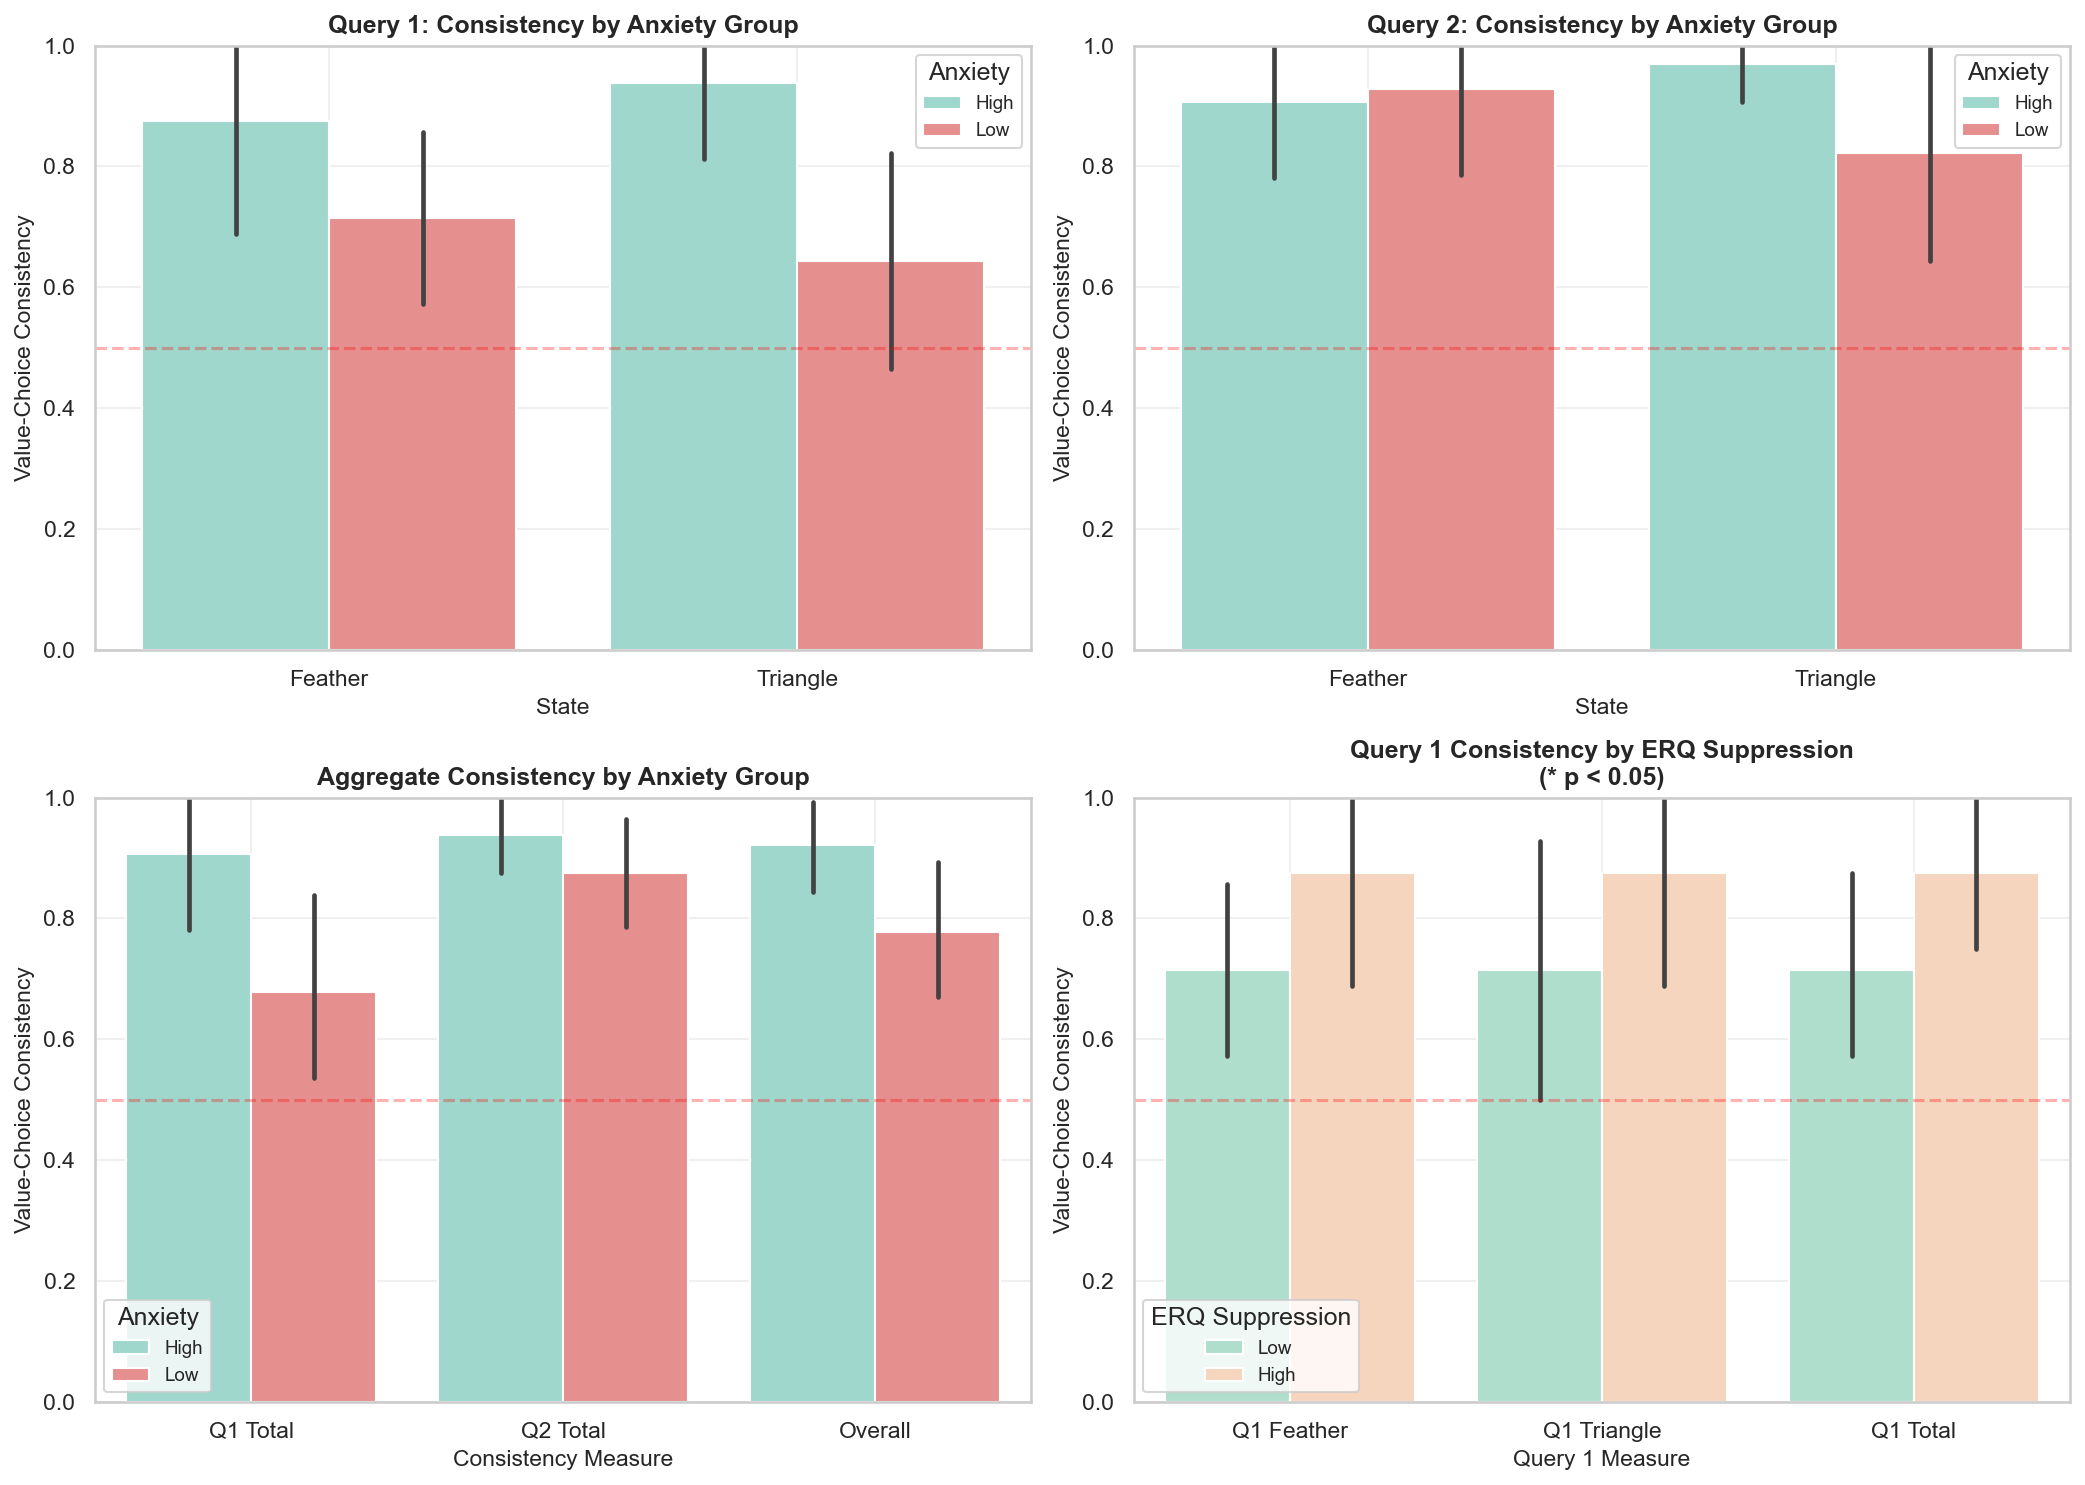

Saved: consistency_fig4_median_splits_erq.png


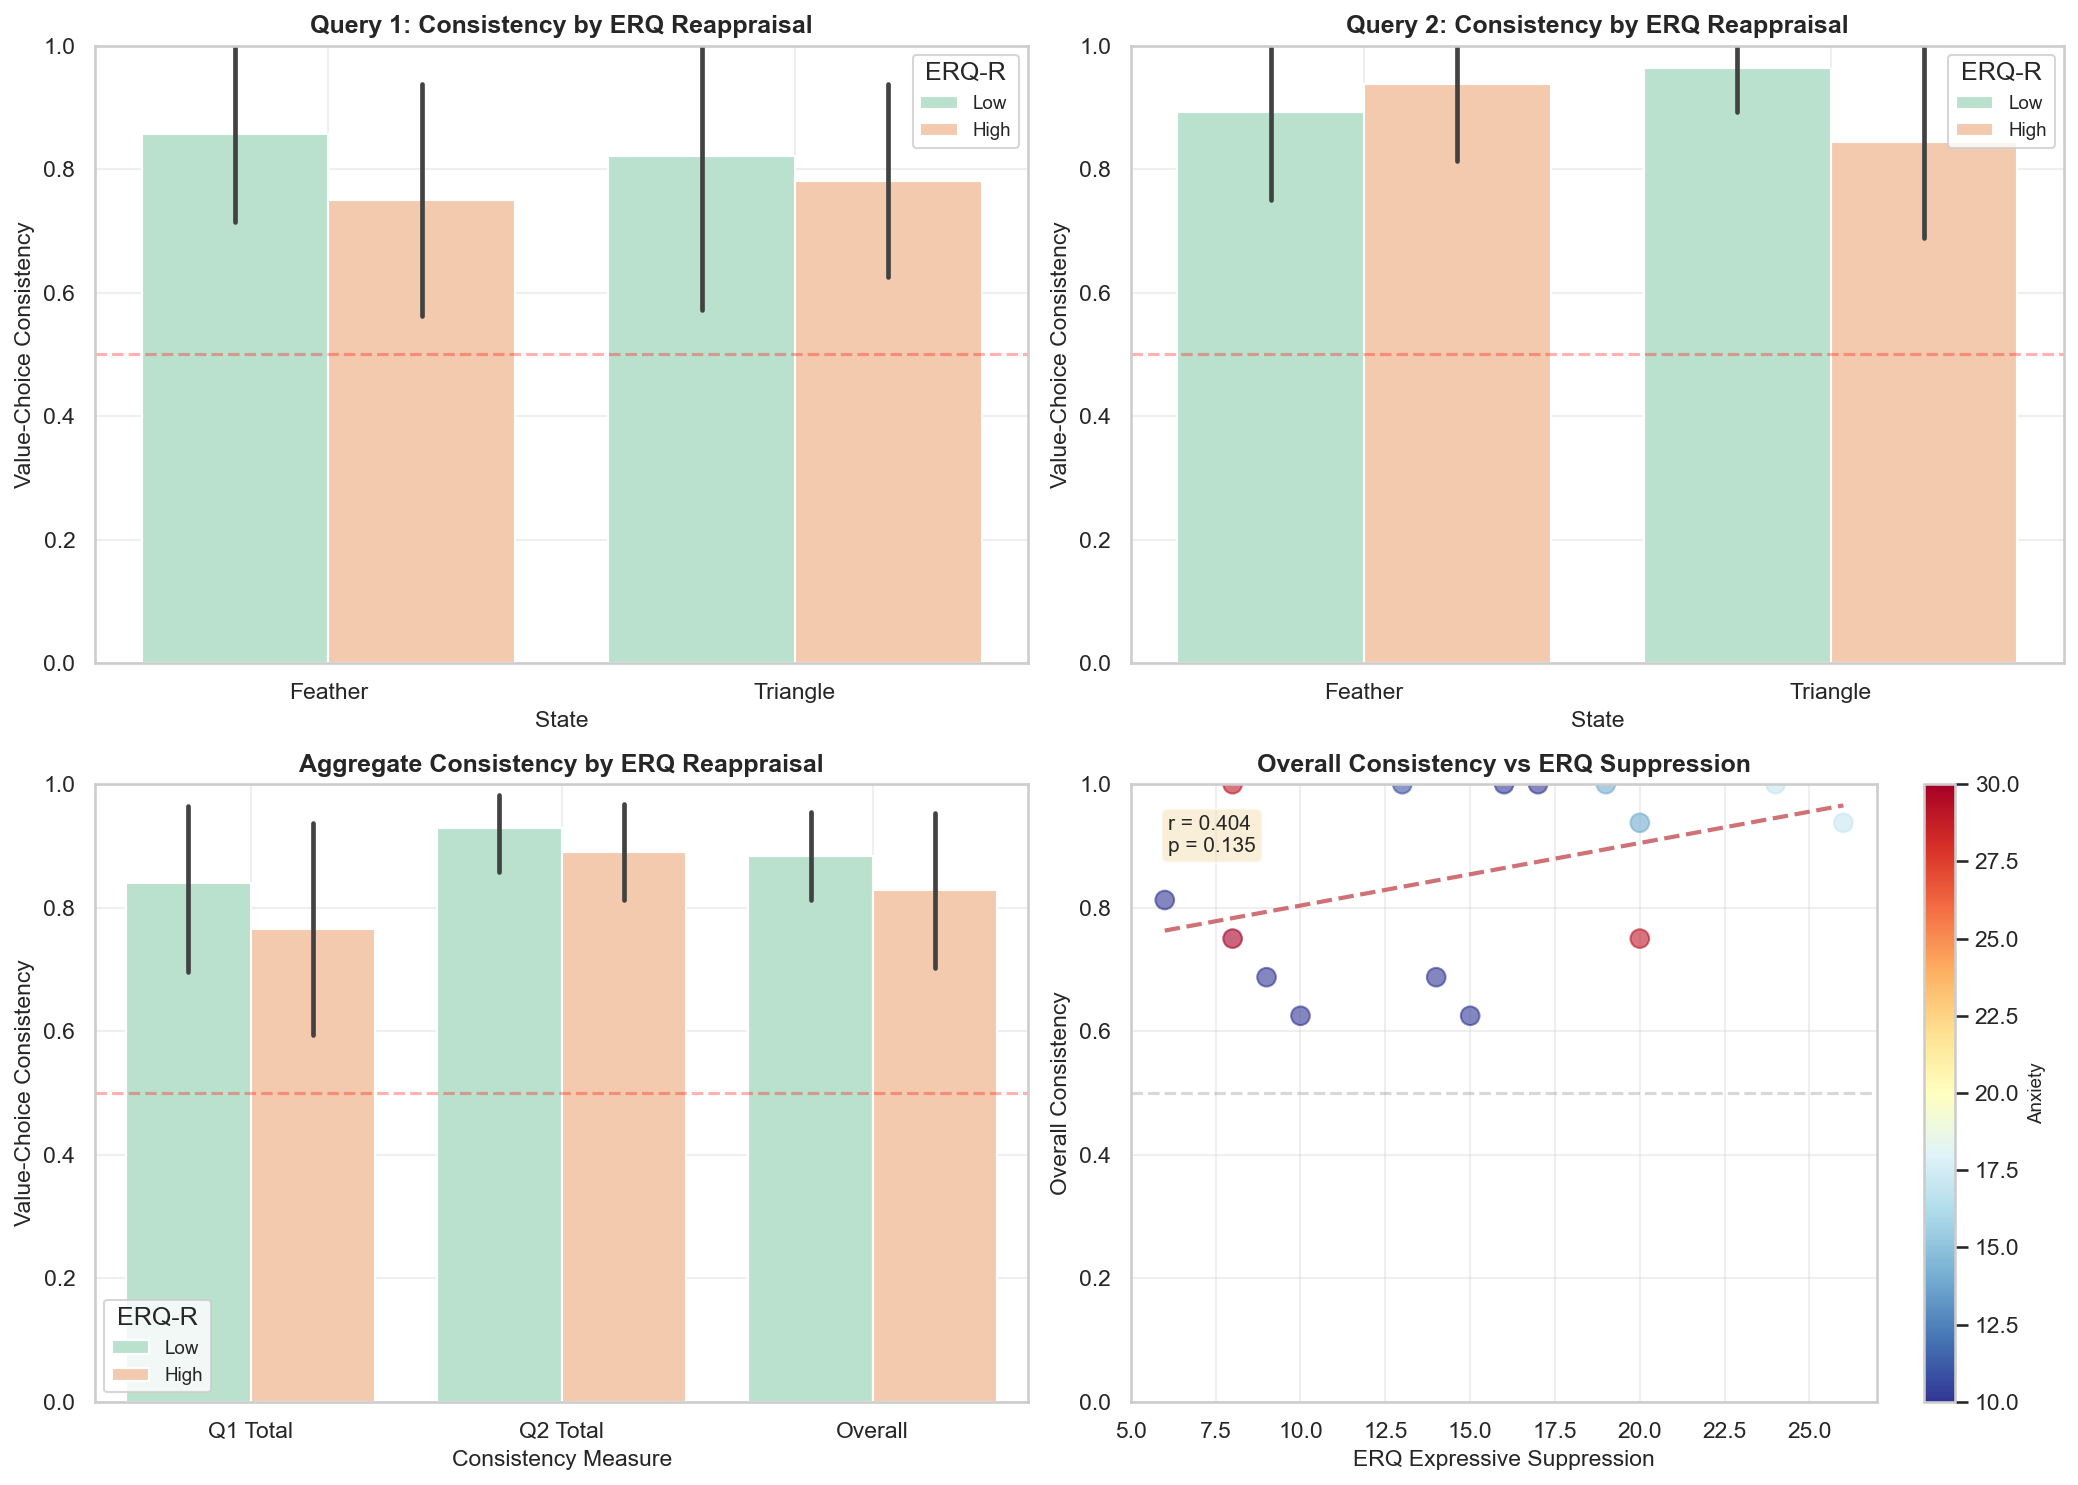


All consistency visualizations created successfully!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
# Load data
consistency_df = pd.read_csv('value_choice_consistency.csv')

print("Creating value-choice consistency visualizations...")
print(len(consistency_df))

# ============================================================================
# FIGURE 1: COMPREHENSIVE HEATMAP
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Correlation heatmap with all measures
ax = axes[0]

consistency_measures = [
    'q1_feather_consistency', 'q1_triangle_consistency',
    'q2_feather_consistency', 'q2_triangle_consistency',
    'q1_total_consistency', 'q2_total_consistency',
    'overall_consistency',
    'anxiety', 'erq_reappraisal', 'erq_suppression'
]

corr_matrix = consistency_df[consistency_measures].corr(method='spearman')

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={'size': 8})

ax.set_title('Value-Choice Consistency: Correlation Matrix', 
             fontsize=13, fontweight='bold', pad=20)

# Better labels
labels = ['Q1 Feather', 'Q1 Triangle', 'Q2 Feather', 'Q2 Triangle',
          'Q1 Total', 'Q2 Total', 'Overall', 'Anxiety', 'ERQ-R', 'ERQ-S']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)

# Panel B: Focused heatmap (consistency measures only with individual differences)
ax = axes[1]

# Create matrix with just consistency x individual differences
consistency_only = [
    'q1_feather_consistency', 'q1_triangle_consistency',
    'q2_feather_consistency', 'q2_triangle_consistency',
    'q1_total_consistency', 'q2_total_consistency',
    'overall_consistency'
]

ind_diffs = ['anxiety', 'erq_reappraisal', 'erq_suppression']

# Calculate correlations
corr_data = []
for cons_measure in consistency_only:
    row = []
    for ind_diff in ind_diffs:
        r = consistency_df[[cons_measure, ind_diff]].corr('spearman').iloc[0, 1]
        row.append(r)
    corr_data.append(row)

corr_matrix_focused = pd.DataFrame(corr_data, 
                                    index=['Q1 Feather', 'Q1 Triangle', 'Q2 Feather', 'Q2 Triangle',
                                           'Q1 Total', 'Q2 Total', 'Overall'],
                                    columns=['Anxiety', 'ERQ Reappraisal', 'ERQ Suppression'])

sns.heatmap(corr_matrix_focused, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, square=False, linewidths=2,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={'size': 10})

ax.set_title('Consistency × Individual Differences\n(Focused View)', 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Individual Difference Measure', fontsize=11)
ax.set_ylabel('Consistency Measure', fontsize=11)

# Highlight significant correlations
for i in range(len(corr_matrix_focused)):
    for j in range(len(corr_matrix_focused.columns)):
        cons_var = consistency_only[i]
        ind_var = ind_diffs[j]
        
        from scipy.stats import pearsonr
        r, p = pearsonr(consistency_df[cons_var].dropna(), 
                        consistency_df[ind_var].dropna())
        
        if p < 0.05:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, 
                                       edgecolor='black', lw=3))

ax.text(0.5, -0.15, '* Black boxes indicate p < 0.05', 
        transform=ax.transAxes, ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('consistency_fig1_heatmaps.png', dpi=300, bbox_inches='tight')
print("Saved: consistency_fig1_heatmaps.png")
plt.show()

# ============================================================================
# FIGURE 2: CONSISTENCY BY QUERY AND STATE
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Overall consistency by query
ax = axes[0, 0]
data_for_plot = pd.DataFrame({
    'Query': ['Query 1']*len(consistency_df) + ['Query 2']*len(consistency_df),
    'Consistency': list(consistency_df['q1_total_consistency']) + 
                   list(consistency_df['q2_total_consistency'])
})

sns.boxplot(data=data_for_plot, x='Query', y='Consistency', ax=ax, color='lightblue')
sns.stripplot(data=data_for_plot, x='Query', y='Consistency', ax=ax,
              color='darkblue', alpha=0.5, size=5)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('Query', fontsize=11)
ax.set_title('Overall Consistency by Query', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: Consistency by query and state
ax = axes[0, 1]
state_data = pd.DataFrame({
    'State': ['Feather']*len(consistency_df)*2 + ['Triangle']*len(consistency_df)*2,
    'Query': (['Query 1']*len(consistency_df) + ['Query 2']*len(consistency_df))*2,
    'Consistency': list(consistency_df['q1_feather_consistency']) + 
                   list(consistency_df['q2_feather_consistency']) +
                   list(consistency_df['q1_triangle_consistency']) + 
                   list(consistency_df['q2_triangle_consistency'])
})

sns.barplot(data=state_data, x='State', y='Consistency', hue='Query', ax=ax,
            palette=['#3498DB', '#E74C3C'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Consistency by State and Query', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='Query', fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Consistency vs Anxiety
ax = axes[1, 0]
for query, color, label in [(1, '#9B59B6', 'Query 1'), (2, '#E67E22', 'Query 2')]:
    cons_col = f'q{query}_total_consistency'
    ax.scatter(consistency_df['anxiety'], consistency_df[cons_col],
               alpha=0.6, s=80, color=color, label=label)
    
    # Regression line
    z = np.polyfit(consistency_df['anxiety'], consistency_df[cons_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(consistency_df['anxiety'].min(), 
                         consistency_df['anxiety'].max(), 100)
    ax.plot(x_line, p(x_line), "--", alpha=0.8, linewidth=2, color=color)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Anxiety Score', fontsize=11)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_title('Consistency vs Anxiety', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

# Panel D: Consistency vs ERQ Reappraisal
ax = axes[1, 1]
for query, color, label in [(1, '#1ABC9C', 'Query 1'), (2, '#F39C12', 'Query 2')]:
    cons_col = f'q{query}_total_consistency'
    ax.scatter(consistency_df['erq_reappraisal'], consistency_df[cons_col],
               alpha=0.6, s=80, color=color, label=label)
    
    # Regression line
    z = np.polyfit(consistency_df['erq_reappraisal'], consistency_df[cons_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(consistency_df['erq_reappraisal'].min(),
                         consistency_df['erq_reappraisal'].max(), 100)
    ax.plot(x_line, p(x_line), "--", alpha=0.8, linewidth=2, color=color)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('ERQ Cognitive Reappraisal', fontsize=11)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_title('Consistency vs ERQ Reappraisal', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('consistency_fig2_descriptives.png', dpi=300, bbox_inches='tight')
print("Saved: consistency_fig2_descriptives.png")
plt.show()

# ============================================================================
# FIGURE 3: MEDIAN SPLIT COMPARISONS - ANXIETY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Query 1 by anxiety group
ax = axes[0, 0]
q1_anxiety_data = pd.DataFrame({
    'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df),
    'Anxiety Group': list(consistency_df['anxiety_group']) + list(consistency_df['anxiety_group']),
    'Consistency': list(consistency_df['q1_feather_consistency']) + 
                   list(consistency_df['q1_triangle_consistency'])
})

sns.barplot(data=q1_anxiety_data, x='State', y='Consistency', hue='Anxiety Group',
            ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Query 1: Consistency by Anxiety Group', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='Anxiety', fontsize=9)
ax.grid(alpha=0.3)

# Panel B: Query 2 by anxiety group
ax = axes[0, 1]
q2_anxiety_data = pd.DataFrame({
    'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df),
    'Anxiety Group': list(consistency_df['anxiety_group']) + list(consistency_df['anxiety_group']),
    'Consistency': list(consistency_df['q2_feather_consistency']) + 
                   list(consistency_df['q2_triangle_consistency'])
})

sns.barplot(data=q2_anxiety_data, x='State', y='Consistency', hue='Anxiety Group',
            ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Query 2: Consistency by Anxiety Group', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='Anxiety', fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Overall by anxiety group
ax = axes[1, 0]
overall_anxiety_data = pd.DataFrame({
    'Measure': ['Q1 Total']*len(consistency_df) + ['Q2 Total']*len(consistency_df) + 
               ['Overall']*len(consistency_df),
    'Anxiety Group': list(consistency_df['anxiety_group'])*3,
    'Consistency': list(consistency_df['q1_total_consistency']) + 
                   list(consistency_df['q2_total_consistency']) +
                   list(consistency_df['overall_consistency'])
})

sns.barplot(data=overall_anxiety_data, x='Measure', y='Consistency', hue='Anxiety Group',
            ax=ax, palette=['#95E1D3', '#F38181'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('Consistency Measure', fontsize=11)
ax.set_title('Aggregate Consistency by Anxiety Group', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='Anxiety', fontsize=9)
ax.grid(alpha=0.3)

# Panel D: ERQ Suppression effect (significant finding)
ax = axes[1, 1]

# Create median split for ERQ Suppression
median_supp = consistency_df['erq_suppression'].median()
consistency_df['erq_supp_group'] = consistency_df['erq_suppression'].apply(
    lambda x: 'High' if x >= median_supp else 'Low'
)

supp_data = pd.DataFrame({
    'Measure': ['Q1 Feather']*len(consistency_df) + ['Q1 Triangle']*len(consistency_df) + 
               ['Q1 Total']*len(consistency_df),
    'ERQ Suppression': list(consistency_df['erq_supp_group'])*3,
    'Consistency': list(consistency_df['q1_feather_consistency']) + 
                   list(consistency_df['q1_triangle_consistency']) +
                   list(consistency_df['q1_total_consistency'])
})

sns.barplot(data=supp_data, x='Measure', y='Consistency', hue='ERQ Suppression',
            ax=ax, palette=['#A8E6CF', '#FFD3B6'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('Query 1 Measure', fontsize=11)
ax.set_title('Query 1 Consistency by ERQ Suppression\n(* p < 0.05)', 
             fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='ERQ Suppression', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('consistency_fig3_median_splits_anxiety.png', dpi=300, bbox_inches='tight')
print("Saved: consistency_fig3_median_splits_anxiety.png")
plt.show()

# ============================================================================
# FIGURE 4: MEDIAN SPLIT COMPARISONS - ERQ REAPPRAISAL
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Query 1 by ERQ group
ax = axes[0, 0]
q1_erq_data = pd.DataFrame({
    'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df),
    'ERQ Reappraisal': list(consistency_df['erq_reapp_group']) + 
                       list(consistency_df['erq_reapp_group']),
    'Consistency': list(consistency_df['q1_feather_consistency']) + 
                   list(consistency_df['q1_triangle_consistency'])
})

sns.barplot(data=q1_erq_data, x='State', y='Consistency', hue='ERQ Reappraisal',
            ax=ax, palette=['#B4E7CE', '#FFC8A2'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Query 1: Consistency by ERQ Reappraisal', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='ERQ-R', fontsize=9)
ax.grid(alpha=0.3)

# Panel B: Query 2 by ERQ group
ax = axes[0, 1]
q2_erq_data = pd.DataFrame({
    'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df),
    'ERQ Reappraisal': list(consistency_df['erq_reapp_group']) + 
                       list(consistency_df['erq_reapp_group']),
    'Consistency': list(consistency_df['q2_feather_consistency']) + 
                   list(consistency_df['q2_triangle_consistency'])
})

sns.barplot(data=q2_erq_data, x='State', y='Consistency', hue='ERQ Reappraisal',
            ax=ax, palette=['#B4E7CE', '#FFC8A2'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Query 2: Consistency by ERQ Reappraisal', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='ERQ-R', fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Overall by ERQ group
ax = axes[1, 0]
overall_erq_data = pd.DataFrame({
    'Measure': ['Q1 Total']*len(consistency_df) + ['Q2 Total']*len(consistency_df) + 
               ['Overall']*len(consistency_df),
    'ERQ Reappraisal': list(consistency_df['erq_reapp_group'])*3,
    'Consistency': list(consistency_df['q1_total_consistency']) + 
                   list(consistency_df['q2_total_consistency']) +
                   list(consistency_df['overall_consistency'])
})

sns.barplot(data=overall_erq_data, x='Measure', y='Consistency', hue='ERQ Reappraisal',
            ax=ax, palette=['#B4E7CE', '#FFC8A2'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Value-Choice Consistency', fontsize=11)
ax.set_xlabel('Consistency Measure', fontsize=11)
ax.set_title('Aggregate Consistency by ERQ Reappraisal', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='ERQ-R', fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Scatter: Overall consistency vs ERQ Suppression
ax = axes[1, 1]
ax.scatter(consistency_df['erq_suppression'], consistency_df['overall_consistency'],
           alpha=0.6, s=80, c=consistency_df['anxiety'], cmap='RdYlBu_r')

z = np.polyfit(consistency_df['erq_suppression'], consistency_df['overall_consistency'], 1)
p = np.poly1d(z)
x_line = np.linspace(consistency_df['erq_suppression'].min(),
                     consistency_df['erq_suppression'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

from scipy.stats import pearsonr
r, p_val = pearsonr(consistency_df['erq_suppression'], consistency_df['overall_consistency'])
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('ERQ Expressive Suppression', fontsize=11)
ax.set_ylabel('Overall Consistency', fontsize=11)
ax.set_title('Overall Consistency vs ERQ Suppression', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])

cbar = plt.colorbar(ax.scatter(consistency_df['erq_suppression'], 
                               consistency_df['overall_consistency'],
                               c=consistency_df['anxiety'], cmap='RdYlBu_r', s=0), ax=ax)
cbar.set_label('Anxiety', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('consistency_fig4_median_splits_erq.png', dpi=300, bbox_inches='tight')
print("Saved: consistency_fig4_median_splits_erq.png")
plt.show()

print("\nAll consistency visualizations created successfully!")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

print("="*80)
print("FLEXIBILITY ANALYSIS: Ratings and Choices Over Revaluation Periods")
print("="*80)

# Load data
df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

# Get anxiety and ERQ scores
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits for categorical analysis
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}, Range={df['Anxiety_Total'].min()}-{df['Anxiety_Total'].max()}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}, Range={df['ERQ_Reappraisal'].min()}-{df['ERQ_Reappraisal'].max()}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}, Range={df['ERQ_Suppression'].min()}-{df['ERQ_Suppression'].max()}")

# ============================================================================
# PART 1: RATING FLEXIBILITY
# ============================================================================
print("\n" + "="*80)
print("PART 1: RATING FLEXIBILITY ACROSS REVALUATION PERIODS")
print("="*80)

# Extract ratings for each state at each time point
rating_data_long = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    erq_reapp_group = row['ERQ_Reappraisal_Group']
    
    # Feather ratings
    for time_point, rating_col in enumerate([
        'Rating_1_Feather_Val',
        'Rating_2_Feather_Val', 
        'Rating_3_Feather_Val'
    ], start=1):
        rating_data_long.append({
            'subject_id': subject_id,
            'anxiety': anxiety,
            'anxiety_group': anxiety_group,
            'erq_reappraisal': erq_reapp,
            'erq_suppression': erq_supp,
            'erq_reapp_group': erq_reapp_group,
            'state': 'Feather',
            'time_point': time_point,
            'rating': row[rating_col]
        })
    
    # Triangle ratings
    for time_point, rating_col in enumerate([
        'Rating_1_Triangle_Val',
        'Rating_2_Triangle_Val',
        'Rating_3_Triangle_Val'
    ], start=1):
        rating_data_long.append({
            'subject_id': subject_id,
            'anxiety': anxiety,
            'anxiety_group': anxiety_group,
            'erq_reappraisal': erq_reapp,
            'erq_suppression': erq_supp,
            'erq_reapp_group': erq_reapp_group,
            'state': 'Triangle',
            'time_point': time_point,
            'rating': row[rating_col]
        })

rating_df = pd.DataFrame(rating_data_long)

# Calculate flexibility metrics for each period
flexibility_ratings = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    
    # Period 1: Post-MF Learning to After Reflection 1 (Rating 1 → Rating 2)
    feather_change_p1 = abs(row['Rating_2_Feather_Val'] - row['Rating_1_Feather_Val'])
    triangle_change_p1 = abs(row['Rating_2_Triangle_Val'] - row['Rating_1_Triangle_Val'])
    total_flex_p1 = feather_change_p1 + triangle_change_p1
    
    # Period 2: After Reflection 1 to After Reflection 2 (Rating 2 → Rating 3)
    feather_change_p2 = abs(row['Rating_3_Feather_Val'] - row['Rating_2_Feather_Val'])
    triangle_change_p2 = abs(row['Rating_3_Triangle_Val'] - row['Rating_2_Triangle_Val'])
    total_flex_p2 = feather_change_p2 + triangle_change_p2
    
    # Overall: Post-MF to Final (Rating 1 → Rating 3)
    feather_change_total = abs(row['Rating_3_Feather_Val'] - row['Rating_1_Feather_Val'])
    triangle_change_total = abs(row['Rating_3_Triangle_Val'] - row['Rating_1_Triangle_Val'])
    total_flex_total = feather_change_total + triangle_change_total
    
    flexibility_ratings.append({
        'subject_id': subject_id,
        'anxiety': anxiety,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'feather_flex_p1': feather_change_p1,
        'triangle_flex_p1': triangle_change_p1,
        'total_flex_p1': total_flex_p1,
        'feather_flex_p2': feather_change_p2,
        'triangle_flex_p2': triangle_change_p2,
        'total_flex_p2': total_flex_p2,
        'feather_flex_total': feather_change_total,
        'triangle_flex_total': triangle_change_total,
        'total_flex_total': total_flex_total
    })

flex_rating_df = pd.DataFrame(flexibility_ratings)

print("\nRating Flexibility by Period:")
print(f"Period 1 (Rating 1→2): M={flex_rating_df['total_flex_p1'].mean():.2f}, SD={flex_rating_df['total_flex_p1'].std():.2f}")
print(f"Period 2 (Rating 2→3): M={flex_rating_df['total_flex_p2'].mean():.2f}, SD={flex_rating_df['total_flex_p2'].std():.2f}")
print(f"Total (Rating 1→3): M={flex_rating_df['total_flex_total'].mean():.2f}, SD={flex_rating_df['total_flex_total'].std():.2f}")

print("\nBy State:")
print(f"Feather Period 1: M={flex_rating_df['feather_flex_p1'].mean():.2f}, SD={flex_rating_df['feather_flex_p1'].std():.2f}")
print(f"Triangle Period 1: M={flex_rating_df['triangle_flex_p1'].mean():.2f}, SD={flex_rating_df['triangle_flex_p1'].std():.2f}")
print(f"Feather Period 2: M={flex_rating_df['feather_flex_p2'].mean():.2f}, SD={flex_rating_df['feather_flex_p2'].std():.2f}")
print(f"Triangle Period 2: M={flex_rating_df['triangle_flex_p2'].mean():.2f}, SD={flex_rating_df['triangle_flex_p2'].std():.2f}")

# ============================================================================
# PART 2: CHOICE FLEXIBILITY
# ============================================================================
print("\n" + "="*80)
print("PART 2: CHOICE FLEXIBILITY ACROSS QUERIES")
print("="*80)

# Calculate choice flexibility
# Query 1 comes after Reflection 1
# Query 2 comes after Reflection 2

flexibility_choices = []

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    
    # Query 1 choices (after Reflection 1)
    q1_feather_choices = []
    q1_triangle_choices = []
    
    for trial in range(1, 21):
        state_col = f'Query_1_T{trial}_State'
        choice_col = f'Query_1_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        if not pd.isna(row[choice_col]):
            if row[state_col] == 'Feather':
                q1_feather_choices.append(row[choice_col])
            else:
                q1_triangle_choices.append(row[choice_col])
    
    # Query 2 choices (after Reflection 2)
    q2_feather_choices = []
    q2_triangle_choices = []
    
    for trial in range(1, 21):
        state_col = f'Query_2_T{trial}_State'
        choice_col = f'Query_2_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        if not pd.isna(row[choice_col]):
            if row[state_col] == 'Feather':
                q2_feather_choices.append(row[choice_col])
            else:
                q2_triangle_choices.append(row[choice_col])
    
    # Calculate acceptance rates (proportion of choosing gamble)
    q1_feather_accept = np.mean(q1_feather_choices) if q1_feather_choices else np.nan
    q1_triangle_accept = np.mean(q1_triangle_choices) if q1_triangle_choices else np.nan
    q2_feather_accept = np.mean(q2_feather_choices) if q2_feather_choices else np.nan
    q2_triangle_accept = np.mean(q2_triangle_choices) if q2_triangle_choices else np.nan
    
    # Choice flexibility = change in acceptance rate between queries
    feather_choice_flex = abs(q2_feather_accept - q1_feather_accept) if not np.isnan(q1_feather_accept) and not np.isnan(q2_feather_accept) else np.nan
    triangle_choice_flex = abs(q2_triangle_accept - q1_triangle_accept) if not np.isnan(q1_triangle_accept) and not np.isnan(q2_triangle_accept) else np.nan
    
    total_choice_flex = np.nanmean([feather_choice_flex, triangle_choice_flex])
    
    flexibility_choices.append({
        'subject_id': subject_id,
        'anxiety': anxiety,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'q1_feather_accept': q1_feather_accept,
        'q1_triangle_accept': q1_triangle_accept,
        'q2_feather_accept': q2_feather_accept,
        'q2_triangle_accept': q2_triangle_accept,
        'feather_choice_flex': feather_choice_flex,
        'triangle_choice_flex': triangle_choice_flex,
        'total_choice_flex': total_choice_flex
    })

flex_choice_df = pd.DataFrame(flexibility_choices)

print("\nChoice Flexibility (Change in Acceptance Rate Q1→Q2):")
print(f"Feather: M={flex_choice_df['feather_choice_flex'].mean():.3f}, SD={flex_choice_df['feather_choice_flex'].std():.3f}")
print(f"Triangle: M={flex_choice_df['triangle_choice_flex'].mean():.3f}, SD={flex_choice_df['triangle_choice_flex'].std():.3f}")
print(f"Overall: M={flex_choice_df['total_choice_flex'].mean():.3f}, SD={flex_choice_df['total_choice_flex'].std():.3f}")

print("\nAcceptance Rates:")
print(f"Q1 Feather: M={flex_choice_df['q1_feather_accept'].mean():.3f}")
print(f"Q1 Triangle: M={flex_choice_df['q1_triangle_accept'].mean():.3f}")
print(f"Q2 Feather: M={flex_choice_df['q2_feather_accept'].mean():.3f}")
print(f"Q2 Triangle: M={flex_choice_df['q2_triangle_accept'].mean():.3f}")

# ============================================================================
# PART 3: COMBINED FLEXIBILITY METRICS
# ============================================================================
print("\n" + "="*80)
print("PART 3: COMBINED FLEXIBILITY ANALYSIS")
print("="*80)

# Merge rating and choice flexibility
combined_flex = flex_rating_df.merge(flex_choice_df, on=['subject_id', 'anxiety', 'erq_reappraisal', 'erq_suppression'])

# Create composite flexibility scores
combined_flex['overall_rating_flex'] = combined_flex['total_flex_total']
combined_flex['overall_choice_flex'] = combined_flex['total_choice_flex']

# Standardize and combine
from scipy.stats import zscore
combined_flex['rating_flex_z'] = zscore(combined_flex['overall_rating_flex'].dropna())
combined_flex['choice_flex_z'] = zscore(combined_flex['overall_choice_flex'].dropna())
combined_flex['combined_flexibility'] = (combined_flex['rating_flex_z'] + combined_flex['choice_flex_z']) / 2

print("\nCombined Flexibility Score:")
print(f"M={combined_flex['combined_flexibility'].mean():.3f}, SD={combined_flex['combined_flexibility'].std():.3f}")

# ============================================================================
# PART 4: CORRELATIONS WITH INDIVIDUAL DIFFERENCES
# ============================================================================
print("\n" + "="*80)
print("PART 4: CORRELATIONS WITH ANXIETY AND ERQ")
print("="*80)

# Define flexibility measures to test
flex_measures = {
    'Rating Flex Period 1': 'total_flex_p1',
    'Rating Flex Period 2': 'total_flex_p2',
    'Rating Flex Total': 'total_flex_total',
    'Feather Rating Flex Total': 'feather_flex_total',
    'Triangle Rating Flex Total': 'triangle_flex_total',
    'Choice Flex (Feather)': 'feather_choice_flex',
    'Choice Flex (Triangle)': 'triangle_choice_flex',
    'Choice Flex Total': 'total_choice_flex',
    'Combined Flexibility': 'combined_flexibility'
}

individual_diffs = {
    'Anxiety': 'anxiety',
    'ERQ Reappraisal': 'erq_reappraisal',
    'ERQ Suppression': 'erq_suppression'
}

print("\nCorrelation Matrix:")
print("-" * 80)
print(f"{'Flexibility Measure':<30} | {'Anxiety':>15} | {'ERQ Reapp':>15} | {'ERQ Supp':>15}")
print("-" * 80)

correlation_results = []

for flex_name, flex_var in flex_measures.items():
    row_data = {'Measure': flex_name}
    
    for diff_name, diff_var in individual_diffs.items():
        valid_data = combined_flex[[flex_var, diff_var]].dropna()
        
        if len(valid_data) > 2:
            r, p = pearsonr(valid_data[flex_var], valid_data[diff_var])
            row_data[f'{diff_name}_r'] = r
            row_data[f'{diff_name}_p'] = p
            
            sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            print(f"{flex_name:<30} | {r:>7.3f} (p={p:.3f}){sig_marker:>3} | ", end="")
        else:
            print(f"{flex_name:<30} | {'N/A':>15} | ", end="")
    
    print()
    correlation_results.append(row_data)

corr_results_df = pd.DataFrame(correlation_results)

# ============================================================================
# PART 5: LINEAR MIXED MODELS
# ============================================================================
print("\n" + "="*80)
print("PART 5: LINEAR MIXED MODELS")
print("="*80)

# Try to use statsmodels for mixed models
try:
    import statsmodels.api as sm
    from statsmodels.formula.api import mixedlm
    
    print("\nFitting Linear Mixed Models...")
    
    # Model 1: Rating flexibility over time
    print("\n" + "-"*80)
    print("MODEL 1: Rating Flexibility Over Time")
    print("-"*80)
    
    # Create period variable (1 vs 2)
    rating_period_data = []
    
    for idx, row in combined_flex.iterrows():
        # Period 1
        rating_period_data.append({
            'subject_id': row['subject_id'],
            'period': 1,
            'flexibility': row['total_flex_p1'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Period 2
        rating_period_data.append({
            'subject_id': row['subject_id'],
            'period': 2,
            'flexibility': row['total_flex_p2'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
    
    rating_period_df = pd.DataFrame(rating_period_data)
    
    # Fit model with random intercepts for subjects
    model1 = mixedlm("flexibility ~ period + anxiety + erq_reappraisal + period:anxiety + period:erq_reappraisal",
                     rating_period_df, groups=rating_period_df["subject_id"])
    result1 = model1.fit()
    print(result1.summary())
    
    # Model 2: State-specific rating flexibility
    print("\n" + "-"*80)
    print("MODEL 2: State-Specific Rating Flexibility")
    print("-"*80)
    
    state_flex_data = []
    
    for idx, row in combined_flex.iterrows():
        # Feather - Period 1
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Feather',
            'period': 1,
            'flexibility': row['feather_flex_p1'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Feather - Period 2
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Feather',
            'period': 2,
            'flexibility': row['feather_flex_p2'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Triangle - Period 1
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Triangle',
            'period': 1,
            'flexibility': row['triangle_flex_p1'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Triangle - Period 2
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Triangle',
            'period': 2,
            'flexibility': row['triangle_flex_p2'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
    
    state_flex_df = pd.DataFrame(state_flex_data)
    
    # Dummy code state (Feather=0, Triangle=1)
    state_flex_df['state_code'] = (state_flex_df['state'] == 'Triangle').astype(int)
    
    model2 = mixedlm("flexibility ~ period + state_code + anxiety + erq_reappraisal + " +
                     "period:state_code + state_code:anxiety + state_code:erq_reappraisal",
                     state_flex_df, groups=state_flex_df["subject_id"])
    result2 = model2.fit()
    print(result2.summary())
    
    # Model 3: Rating trajectories over all 3 time points
    print("\n" + "-"*80)
    print("MODEL 3: Rating Values Over All Time Points")
    print("-"*80)
    
    # Use long-format rating data
    rating_df['time_code'] = rating_df['time_point'] - 1  # 0, 1, 2
    rating_df['state_code'] = (rating_df['state'] == 'Triangle').astype(int)
    
    model3 = mixedlm("rating ~ time_code + state_code + anxiety + erq_reappraisal + " +
                     "time_code:state_code + time_code:anxiety + time_code:erq_reappraisal",
                     rating_df, groups=rating_df["subject_id"])
    result3 = model3.fit()
    print(result3.summary())
    
    # Save model summaries
    with open('/home/claude/lmm_results.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("LINEAR MIXED MODEL RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write("MODEL 1: Rating Flexibility Over Time\n")
        f.write("-"*80 + "\n")
        f.write(str(result1.summary()) + "\n\n")
        
        f.write("MODEL 2: State-Specific Rating Flexibility\n")
        f.write("-"*80 + "\n")
        f.write(str(result2.summary()) + "\n\n")
        
        f.write("MODEL 3: Rating Values Over All Time Points\n")
        f.write("-"*80 + "\n")
        f.write(str(result3.summary()) + "\n\n")
    
    print("\nModel summaries saved to lmm_results.txt")
    
    # Store results for later use
    lmm_available = True
    
except ImportError:
    print("\nWARNING: statsmodels not available. Installing...")
    import subprocess
    subprocess.run(['pip', 'install', 'statsmodels', '--break-system-packages'], 
                   capture_output=True)
    print("Please re-run this script after installation.")
    lmm_available = False
except Exception as e:
    print(f"\nError fitting mixed models: {e}")
    lmm_available = False

# ============================================================================
# SAVE OUTPUT DATA
# ============================================================================

# Save flexibility dataframes
combined_flex.to_csv('flexibility_analysis.csv', index=False)
rating_df.to_csv('rating_trajectories_long.csv', index=False)
corr_results_df.to_csv('flexibility_correlations.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - flexibility_analysis.csv (subject-level flexibility metrics)")
print("  - rating_trajectories_long.csv (long-format rating data)")
print("  - flexibility_correlations.csv (correlation results)")
if lmm_available:
    print("  - lmm_results.txt (linear mixed model summaries)")
print("="*80)

FLEXIBILITY ANALYSIS: Ratings and Choices Over Revaluation Periods

Sample size: 15
Anxiety: M=15.40, SD=7.63, Range=10-30
ERQ Reappraisal: M=32.33, SD=4.61, Range=24-42
ERQ Suppression: M=15.00, SD=6.08, Range=6-26

PART 1: RATING FLEXIBILITY ACROSS REVALUATION PERIODS

Rating Flexibility by Period:
Period 1 (Rating 1→2): M=18.67, SD=22.64
Period 2 (Rating 2→3): M=11.00, SD=14.90
Total (Rating 1→3): M=15.00, SD=15.92

By State:
Feather Period 1: M=9.67, SD=11.25
Triangle Period 1: M=9.00, SD=11.53
Feather Period 2: M=4.67, SD=8.34
Triangle Period 2: M=6.33, SD=10.77

PART 2: CHOICE FLEXIBILITY ACROSS QUERIES

Choice Flexibility (Change in Acceptance Rate Q1→Q2):
Feather: M=0.233, SD=0.291
Triangle: M=0.167, SD=0.309
Overall: M=0.200, SD=0.182

Acceptance Rates:
Q1 Feather: M=0.567
Q1 Triangle: M=0.617
Q2 Feather: M=0.767
Q2 Triangle: M=0.483

PART 3: COMBINED FLEXIBILITY ANALYSIS

Combined Flexibility Score:
M=-0.000, SD=0.697

PART 4: CORRELATIONS WITH ANXIETY AND ERQ

Correlation Ma

c:\Users\adip1\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\adip1\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\adip1\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


MIXED-EFFECTS APPROXIMATIONS & VISUALIZATION

REPEATED MEASURES ANALYSIS (MIXED-EFFECTS APPROXIMATION)

ANALYSIS 1: Rating Flexibility Over Time
--------------------------------------------------------------------------------
Period 1 vs Period 2 (Paired t-test):
  Period 1: M=18.67, SD=22.64
  Period 2: M=11.00, SD=14.90
  t(14) = 1.479, p = 0.1613

Period 1 Flexibility correlations:
  Anxiety: r=0.131, p=0.6405
  ERQ Reappraisal: r=-0.331, p=0.2282
  ERQ Suppression: r=0.275, p=0.3213

Period 2 Flexibility correlations:
  Anxiety: r=0.028, p=0.9221
  ERQ Reappraisal: r=0.047, p=0.8685
  ERQ Suppression: r=0.485, p=0.0672

ANALYSIS 2: State-Specific Flexibility
--------------------------------------------------------------------------------
Period 1: Feather vs Triangle
  Feather: M=9.67, SD=11.25
  Triangle: M=9.00, SD=11.53
  t(14) = 1.000, p = 0.3343

Period 2: Feather vs Triangle
  Feather: M=4.67, SD=8.34
  Triangle: M=6.33, SD=10.77
  t(14) = -0.529, p = 0.6050

ANALYSIS 3: Rati

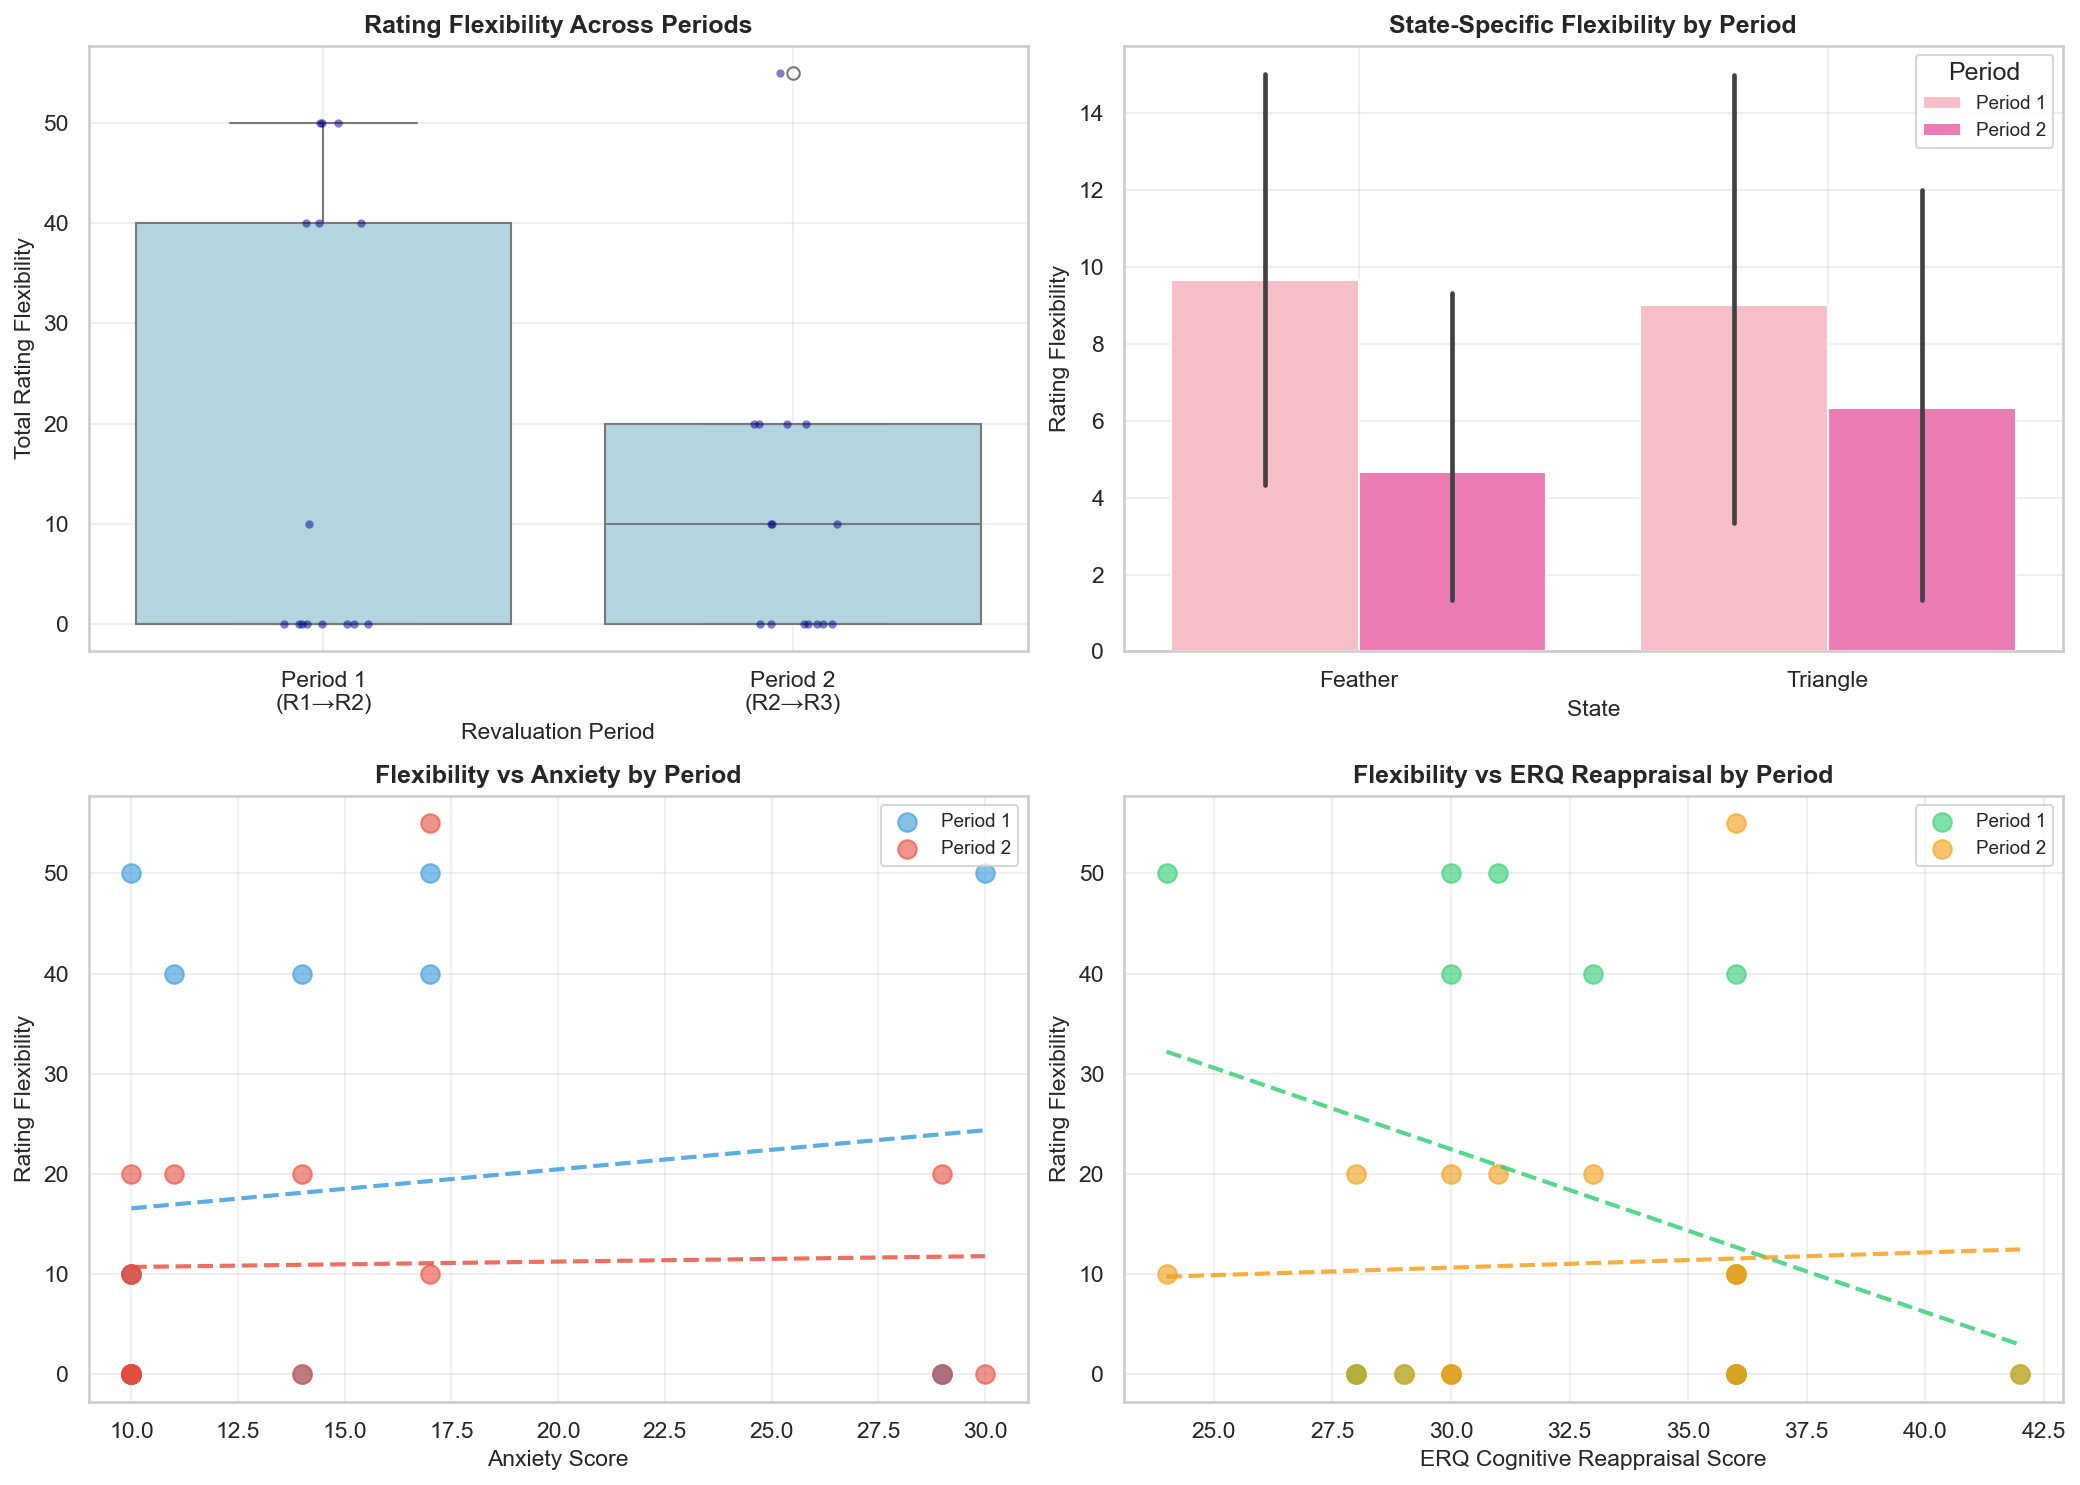

Saved: flexibility_fig2_rating_trajectories.png


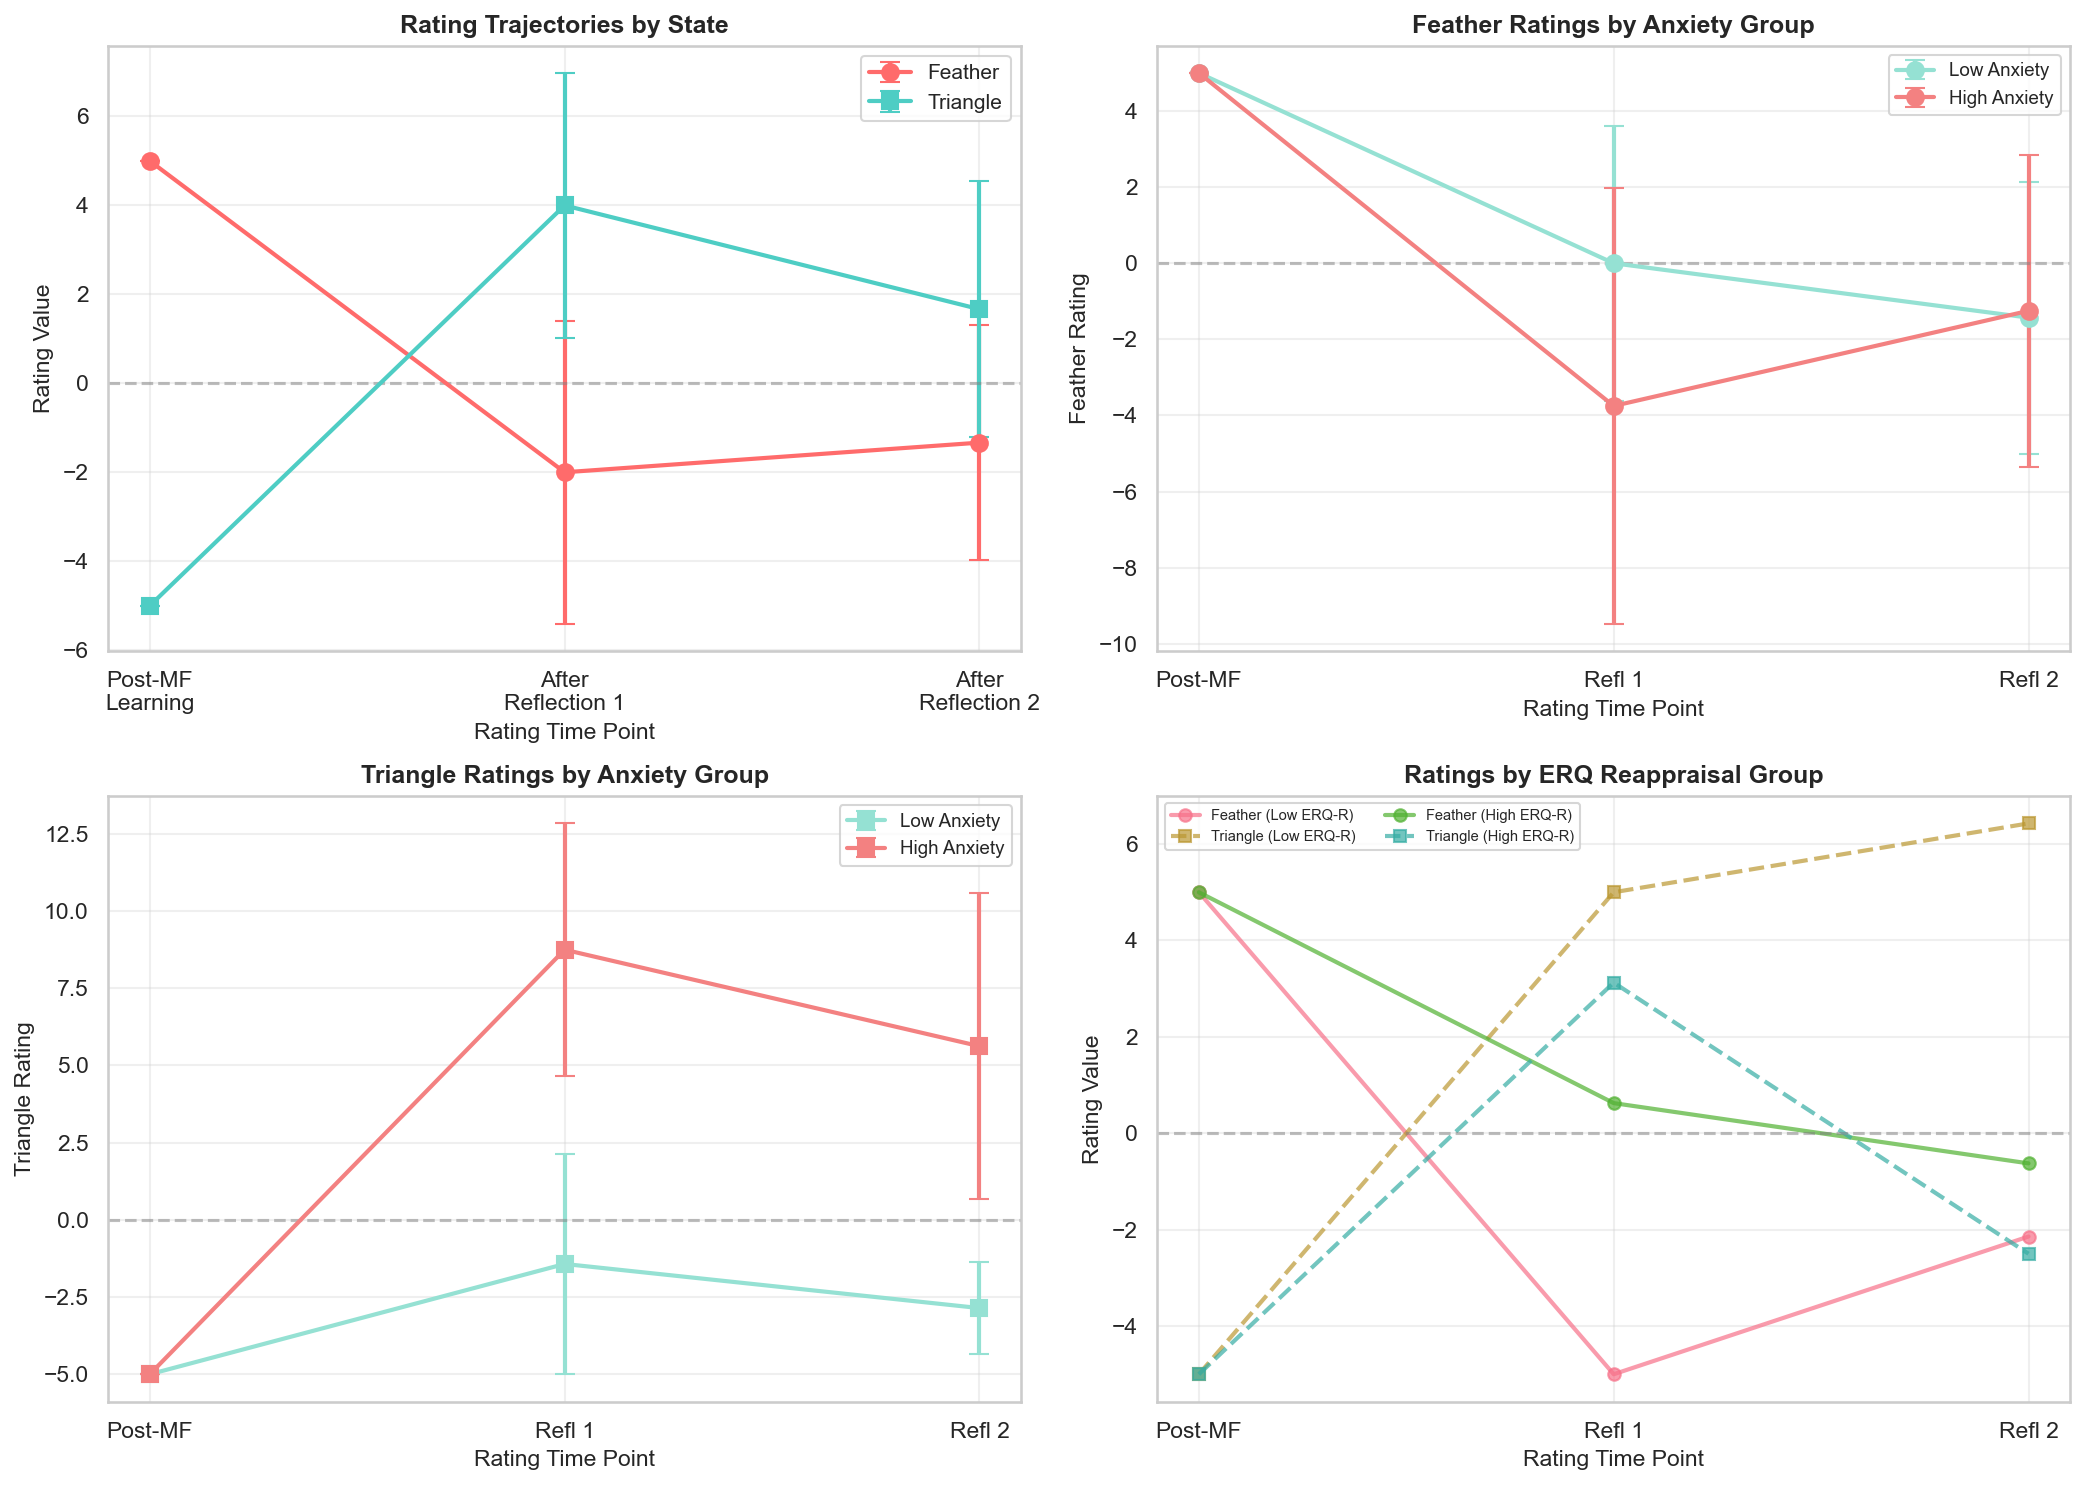

Saved: flexibility_fig3_choice_flexibility.png


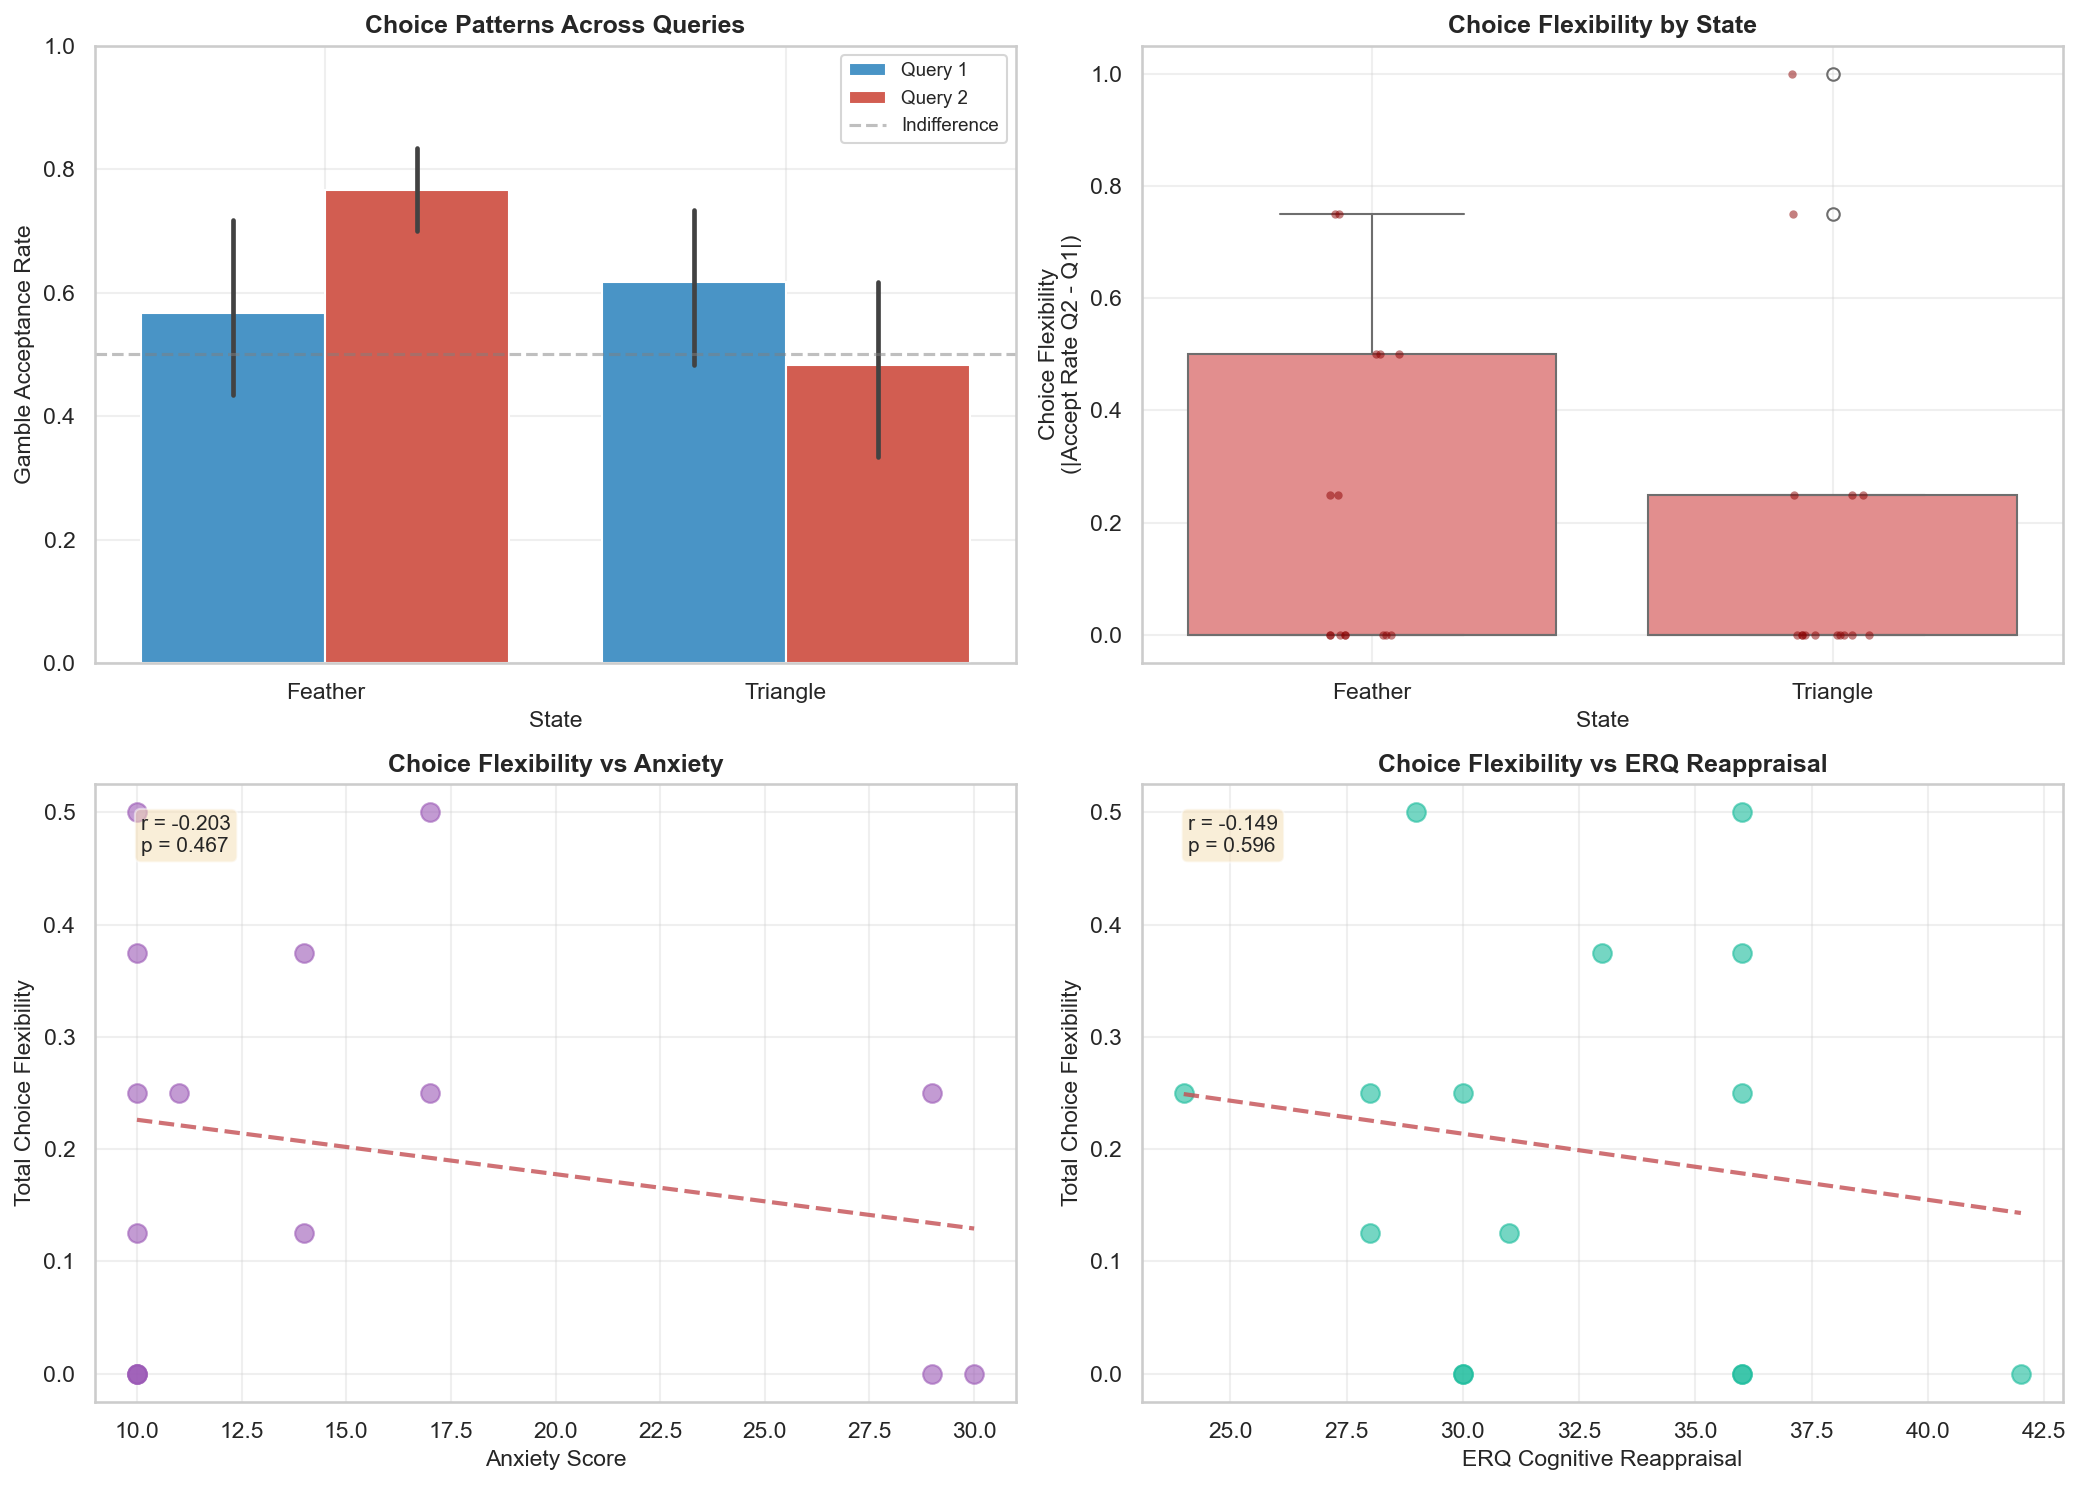

Saved: flexibility_fig4_correlation_matrix.png


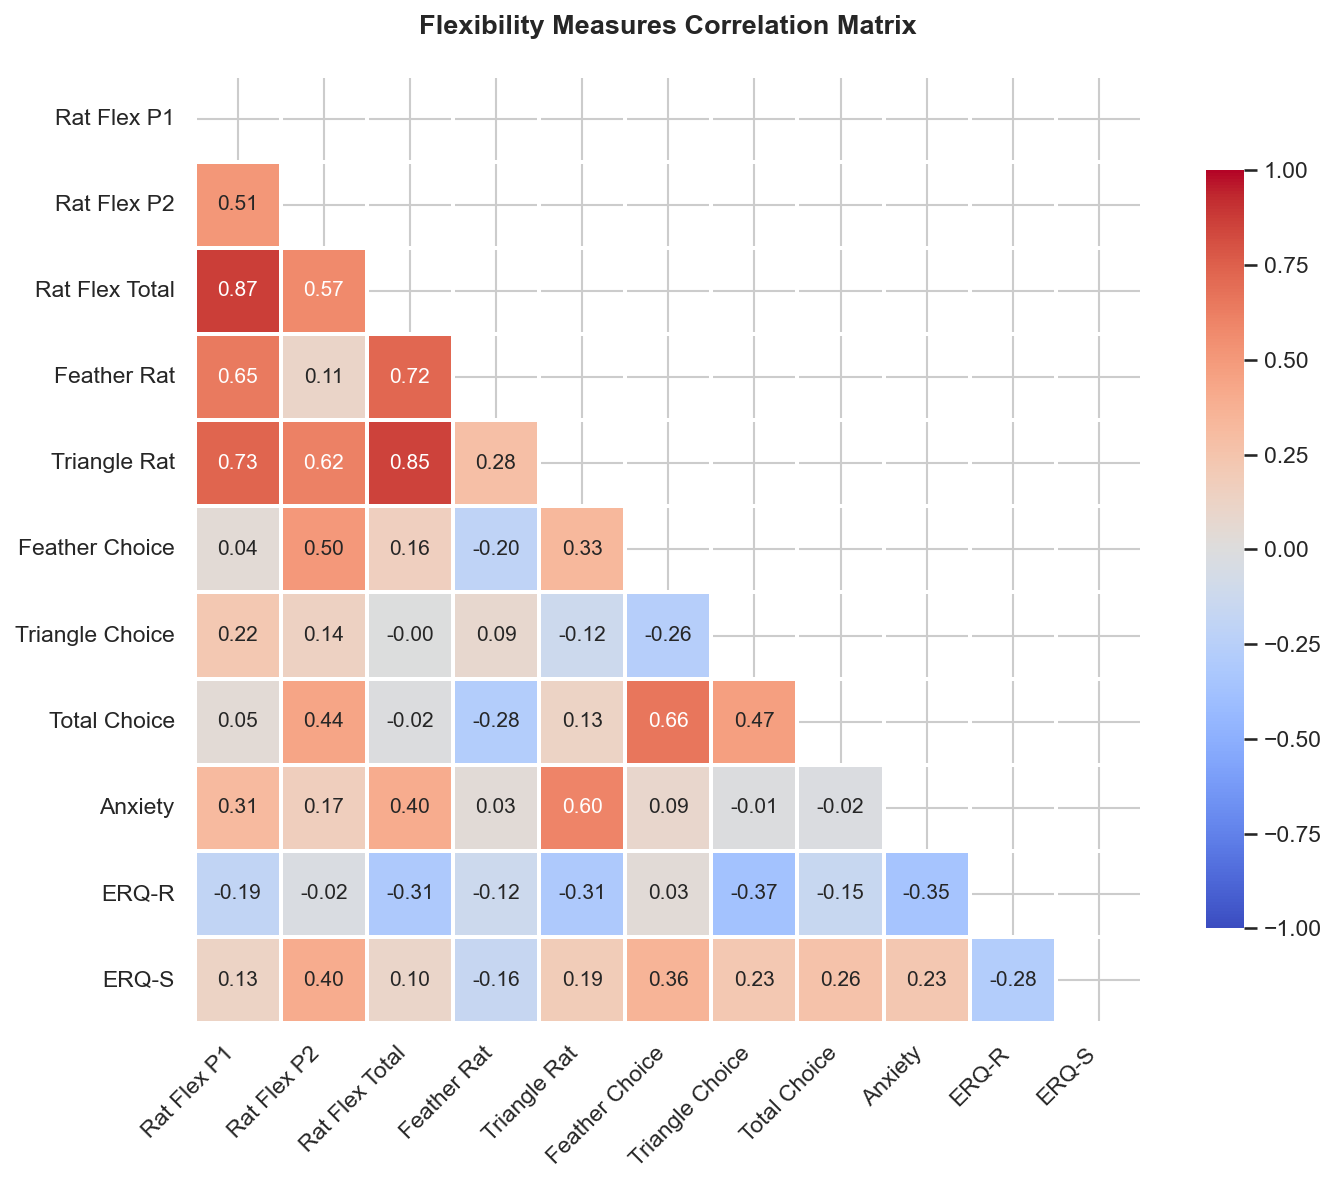


Flexibility analysis complete!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MIXED-EFFECTS APPROXIMATIONS & VISUALIZATION")
print("="*80)

# Load the flexibility data we already created
combined_flex = pd.read_csv('flexibility_analysis.csv')
rating_df = pd.read_csv('rating_trajectories_long.csv')

# ============================================================================
# APPROXIMATING MIXED MODELS WITH REPEATED MEASURES ANOVA
# ============================================================================
print("\n" + "="*80)
print("REPEATED MEASURES ANALYSIS (MIXED-EFFECTS APPROXIMATION)")
print("="*80)

# Since we can't use statsmodels, we'll use repeated measures approaches

# Analysis 1: Rating flexibility across periods
print("\nANALYSIS 1: Rating Flexibility Over Time")
print("-" * 80)

# Paired t-test: Period 1 vs Period 2
t_stat, p_val = stats.ttest_rel(combined_flex['total_flex_p1'], 
                                  combined_flex['total_flex_p2'])
print(f"Period 1 vs Period 2 (Paired t-test):")
print(f"  Period 1: M={combined_flex['total_flex_p1'].mean():.2f}, SD={combined_flex['total_flex_p1'].std():.2f}")
print(f"  Period 2: M={combined_flex['total_flex_p2'].mean():.2f}, SD={combined_flex['total_flex_p2'].std():.2f}")
print(f"  t({len(combined_flex)-1}) = {t_stat:.3f}, p = {p_val:.4f}")

# Correlation with individual differences within each period
print("\nPeriod 1 Flexibility correlations:")
for var, name in [('anxiety', 'Anxiety'), ('erq_reappraisal', 'ERQ Reappraisal'), ('erq_suppression', 'ERQ Suppression')]:
    r, p = pearsonr(combined_flex[var], combined_flex['total_flex_p1'])
    print(f"  {name}: r={r:.3f}, p={p:.4f}")

print("\nPeriod 2 Flexibility correlations:")
for var, name in [('anxiety', 'Anxiety'), ('erq_reappraisal', 'ERQ Reappraisal'), ('erq_suppression', 'ERQ Suppression')]:
    r, p = pearsonr(combined_flex[var], combined_flex['total_flex_p2'])
    print(f"  {name}: r={r:.3f}, p={p:.4f}")

# Analysis 2: State-specific differences
print("\n" + "="*80)
print("ANALYSIS 2: State-Specific Flexibility")
print("-" * 80)

# Compare Feather vs Triangle flexibility within each period
t1, p1 = stats.ttest_rel(combined_flex['feather_flex_p1'], combined_flex['triangle_flex_p1'])
t2, p2 = stats.ttest_rel(combined_flex['feather_flex_p2'], combined_flex['triangle_flex_p2'])

print("Period 1: Feather vs Triangle")
print(f"  Feather: M={combined_flex['feather_flex_p1'].mean():.2f}, SD={combined_flex['feather_flex_p1'].std():.2f}")
print(f"  Triangle: M={combined_flex['triangle_flex_p1'].mean():.2f}, SD={combined_flex['triangle_flex_p1'].std():.2f}")
print(f"  t({len(combined_flex)-1}) = {t1:.3f}, p = {p1:.4f}")

print("\nPeriod 2: Feather vs Triangle")
print(f"  Feather: M={combined_flex['feather_flex_p2'].mean():.2f}, SD={combined_flex['feather_flex_p2'].std():.2f}")
print(f"  Triangle: M={combined_flex['triangle_flex_p2'].mean():.2f}, SD={combined_flex['triangle_flex_p2'].std():.2f}")
print(f"  t({len(combined_flex)-1}) = {t2:.3f}, p = {p2:.4f}")

# Analysis 3: Rating trajectories
print("\n" + "="*80)
print("ANALYSIS 3: Rating Trajectories Over Time")
print("-" * 80)

for state in ['Feather', 'Triangle']:
    state_data = rating_df[rating_df['state'] == state]
    
    print(f"\n{state}:")
    for time in [1, 2, 3]:
        time_data = state_data[state_data['time_point'] == time]['rating']
        print(f"  Time {time}: M={time_data.mean():.2f}, SD={time_data.std():.2f}")
    
    # Correlations with time
    r_time, p_time = pearsonr(state_data['time_point'], state_data['rating'])
    print(f"  Linear trend over time: r={r_time:.3f}, p={p_time:.4f}")
    
    # Interaction with anxiety
    high_anx = state_data[state_data['anxiety_group'] == 'High']
    low_anx = state_data[state_data['anxiety_group'] == 'Low']
    
    r_high, p_high = pearsonr(high_anx['time_point'], high_anx['rating'])
    r_low, p_low = pearsonr(low_anx['time_point'], low_anx['rating'])
    
    print(f"  High Anxiety trend: r={r_high:.3f}, p={p_high:.4f}")
    print(f"  Low Anxiety trend: r={r_low:.3f}, p={p_low:.4f}")

# ============================================================================
# COMPREHENSIVE VISUALIZATIONS
# ============================================================================

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# FIGURE 1: Rating Flexibility Over Periods
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Overall flexibility by period
ax = axes[0, 0]
period_data = pd.DataFrame({
    'Period': ['Period 1\n(R1→R2)']*len(combined_flex) + ['Period 2\n(R2→R3)']*len(combined_flex),
    'Flexibility': list(combined_flex['total_flex_p1']) + list(combined_flex['total_flex_p2']),
    'Anxiety': list(combined_flex['anxiety']) + list(combined_flex['anxiety'])
})

sns.boxplot(data=period_data, x='Period', y='Flexibility', ax=ax, color='lightblue')
sns.stripplot(data=period_data, x='Period', y='Flexibility', ax=ax, 
              color='darkblue', alpha=0.5, size=4)
ax.set_ylabel('Total Rating Flexibility', fontsize=11)
ax.set_xlabel('Revaluation Period', fontsize=11)
ax.set_title('Rating Flexibility Across Periods', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Panel B: State-specific flexibility
ax = axes[0, 1]
state_period_data = pd.DataFrame({
    'State': ['Feather']*len(combined_flex)*2 + ['Triangle']*len(combined_flex)*2,
    'Period': (['Period 1']*len(combined_flex) + ['Period 2']*len(combined_flex))*2,
    'Flexibility': list(combined_flex['feather_flex_p1']) + list(combined_flex['feather_flex_p2']) + 
                   list(combined_flex['triangle_flex_p1']) + list(combined_flex['triangle_flex_p2'])
})

sns.barplot(data=state_period_data, x='State', y='Flexibility', hue='Period', ax=ax,
            palette=['#FFB6C1', '#FF69B4'])
ax.set_ylabel('Rating Flexibility', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('State-Specific Flexibility by Period', fontsize=12, fontweight='bold')
ax.legend(title='Period', fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Flexibility vs Anxiety
ax = axes[1, 0]
for period, color, label in [(1, '#3498DB', 'Period 1'), (2, '#E74C3C', 'Period 2')]:
    flex_col = f'total_flex_p{period}'
    ax.scatter(combined_flex['anxiety'], combined_flex[flex_col], 
               alpha=0.6, s=80, color=color, label=label)
    
    # Regression line
    z = np.polyfit(combined_flex['anxiety'], combined_flex[flex_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(combined_flex['anxiety'].min(), combined_flex['anxiety'].max(), 100)
    ax.plot(x_line, p(x_line), "--", alpha=0.8, linewidth=2, color=color)

ax.set_xlabel('Anxiety Score', fontsize=11)
ax.set_ylabel('Rating Flexibility', fontsize=11)
ax.set_title('Flexibility vs Anxiety by Period', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Flexibility vs ERQ Reappraisal
ax = axes[1, 1]
for period, color, label in [(1, '#2ECC71', 'Period 1'), (2, '#F39C12', 'Period 2')]:
    flex_col = f'total_flex_p{period}'
    ax.scatter(combined_flex['erq_reappraisal'], combined_flex[flex_col],
               alpha=0.6, s=80, color=color, label=label)
    
    # Regression line
    z = np.polyfit(combined_flex['erq_reappraisal'], combined_flex[flex_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(combined_flex['erq_reappraisal'].min(), 
                         combined_flex['erq_reappraisal'].max(), 100)
    ax.plot(x_line, p(x_line), "--", alpha=0.8, linewidth=2, color=color)

ax.set_xlabel('ERQ Cognitive Reappraisal Score', fontsize=11)
ax.set_ylabel('Rating Flexibility', fontsize=11)
ax.set_title('Flexibility vs ERQ Reappraisal by Period', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('flexibility_fig1_rating_flexibility.png', dpi=300, bbox_inches='tight')
print("\nSaved: flexibility_fig1_rating_flexibility.png")
plt.show()

# FIGURE 2: Rating Trajectories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Overall trajectories by state
ax = axes[0, 0]
for state, color, marker in [('Feather', '#FF6B6B', 'o'), ('Triangle', '#4ECDC4', 's')]:
    state_data = rating_df[rating_df['state'] == state]
    means = state_data.groupby('time_point')['rating'].mean()
    sems = state_data.groupby('time_point')['rating'].sem()
    
    ax.errorbar([1, 2, 3], means, yerr=sems, marker=marker, markersize=8,
                linewidth=2, capsize=5, label=state, color=color)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Rating Value', fontsize=11)
ax.set_title('Rating Trajectories by State', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF\nLearning', 'After\nReflection 1', 'After\nReflection 2'])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Panel B: Trajectories by anxiety group (Feather)
ax = axes[0, 1]
for group, color in [('Low', '#95E1D3'), ('High', '#F38181')]:
    group_data = rating_df[(rating_df['state'] == 'Feather') & 
                           (rating_df['anxiety_group'] == group)]
    means = group_data.groupby('time_point')['rating'].mean()
    sems = group_data.groupby('time_point')['rating'].sem()
    
    ax.errorbar([1, 2, 3], means, yerr=sems, marker='o', markersize=8,
                linewidth=2, capsize=5, label=f'{group} Anxiety', color=color)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Feather Rating', fontsize=11)
ax.set_title('Feather Ratings by Anxiety Group', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF', 'Refl 1', 'Refl 2'])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Trajectories by anxiety group (Triangle)
ax = axes[1, 0]
for group, color in [('Low', '#95E1D3'), ('High', '#F38181')]:
    group_data = rating_df[(rating_df['state'] == 'Triangle') & 
                           (rating_df['anxiety_group'] == group)]
    means = group_data.groupby('time_point')['rating'].mean()
    sems = group_data.groupby('time_point')['rating'].sem()
    
    ax.errorbar([1, 2, 3], means, yerr=sems, marker='s', markersize=8,
                linewidth=2, capsize=5, label=f'{group} Anxiety', color=color)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Triangle Rating', fontsize=11)
ax.set_title('Triangle Ratings by Anxiety Group', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF', 'Refl 1', 'Refl 2'])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Trajectories by ERQ Reappraisal
ax = axes[1, 1]
for group, color in [('Low', '#A8E6CF'), ('High', '#FFD3B6')]:
    group_data = rating_df[rating_df['erq_reapp_group'] == group]
    
    for state, marker, linestyle in [('Feather', 'o', '-'), ('Triangle', 's', '--')]:
        state_group_data = group_data[group_data['state'] == state]
        means = state_group_data.groupby('time_point')['rating'].mean()
        
        ax.plot([1, 2, 3], means, marker=marker, markersize=6,
                linewidth=2, label=f'{state} ({group} ERQ-R)', 
                linestyle=linestyle, alpha=0.7)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Rating Value', fontsize=11)
ax.set_title('Ratings by ERQ Reappraisal Group', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF', 'Refl 1', 'Refl 2'])
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('flexibility_fig2_rating_trajectories.png', dpi=300, bbox_inches='tight')
print("Saved: flexibility_fig2_rating_trajectories.png")
plt.show()

# FIGURE 3: Choice Flexibility
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Acceptance rates by query
ax = axes[0, 0]
accept_data = pd.DataFrame({
    'Query': ['Query 1']*len(combined_flex)*2 + ['Query 2']*len(combined_flex)*2,
    'State': ['Feather']*len(combined_flex) + ['Triangle']*len(combined_flex) + 
             ['Feather']*len(combined_flex) + ['Triangle']*len(combined_flex),
    'Accept Rate': list(combined_flex['q1_feather_accept']) + list(combined_flex['q1_triangle_accept']) +
                   list(combined_flex['q2_feather_accept']) + list(combined_flex['q2_triangle_accept'])
})

sns.barplot(data=accept_data, x='State', y='Accept Rate', hue='Query', ax=ax,
            palette=['#3498DB', '#E74C3C'])
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Indifference')
ax.set_ylabel('Gamble Acceptance Rate', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Choice Patterns Across Queries', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

# Panel B: Choice flexibility by state
ax = axes[0, 1]
choice_flex_data = pd.DataFrame({
    'State': ['Feather']*len(combined_flex) + ['Triangle']*len(combined_flex),
    'Flexibility': list(combined_flex['feather_choice_flex']) + list(combined_flex['triangle_choice_flex'])
})

sns.boxplot(data=choice_flex_data, x='State', y='Flexibility', ax=ax, color='lightcoral')
sns.stripplot(data=choice_flex_data, x='State', y='Flexibility', ax=ax,
              color='darkred', alpha=0.5, size=4)
ax.set_ylabel('Choice Flexibility\n(|Accept Rate Q2 - Q1|)', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.set_title('Choice Flexibility by State', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Panel C: Choice flexibility vs anxiety
ax = axes[1, 0]
ax.scatter(combined_flex['anxiety'], combined_flex['total_choice_flex'],
           alpha=0.6, s=80, color='#9B59B6')

z = np.polyfit(combined_flex['anxiety'].dropna(), 
               combined_flex['total_choice_flex'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(combined_flex['anxiety'].min(), combined_flex['anxiety'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

r, p_val = pearsonr(combined_flex['anxiety'].dropna(), 
                     combined_flex['total_choice_flex'].dropna())
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Anxiety Score', fontsize=11)
ax.set_ylabel('Total Choice Flexibility', fontsize=11)
ax.set_title('Choice Flexibility vs Anxiety', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Panel D: Choice flexibility vs ERQ
ax = axes[1, 1]
ax.scatter(combined_flex['erq_reappraisal'], combined_flex['total_choice_flex'],
           alpha=0.6, s=80, color='#1ABC9C')

z = np.polyfit(combined_flex['erq_reappraisal'].dropna(),
               combined_flex['total_choice_flex'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(combined_flex['erq_reappraisal'].min(),
                     combined_flex['erq_reappraisal'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

r, p_val = pearsonr(combined_flex['erq_reappraisal'].dropna(),
                     combined_flex['total_choice_flex'].dropna())
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('ERQ Cognitive Reappraisal', fontsize=11)
ax.set_ylabel('Total Choice Flexibility', fontsize=11)
ax.set_title('Choice Flexibility vs ERQ Reappraisal', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('flexibility_fig3_choice_flexibility.png', dpi=300, bbox_inches='tight')
print("Saved: flexibility_fig3_choice_flexibility.png")
plt.show()

# FIGURE 4: Combined Flexibility Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create correlation matrix for all flexibility measures
flex_measures = [
    'total_flex_p1', 'total_flex_p2', 'total_flex_total',
    'feather_flex_total', 'triangle_flex_total',
    'feather_choice_flex', 'triangle_choice_flex', 'total_choice_flex',
    'anxiety', 'erq_reappraisal', 'erq_suppression'
]

corr_matrix = combined_flex[flex_measures].corr(method='spearman')

# Mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Flexibility Measures Correlation Matrix', fontsize=13, fontweight='bold', pad=20)

labels = ['Rat Flex P1', 'Rat Flex P2', 'Rat Flex Total',
          'Feather Rat', 'Triangle Rat',
          'Feather Choice', 'Triangle Choice', 'Total Choice',
          'Anxiety', 'ERQ-R', 'ERQ-S']
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.savefig('flexibility_fig4_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: flexibility_fig4_correlation_matrix.png")
plt.show()

print("\n" + "="*80)
print("Flexibility analysis complete!")
print("="*80)

Loaded 15 subjects (low knowledge filtered out)

Complete cases for analysis: 15

--- Descriptive Statistics ---
Triangle preference rate: 0.333
  (Proportion rating Triangle > Feather)

ERQ Cognitive Reappraisal:
  Mean: 32.33
  SD: 4.61
  Range: 24 - 42

Total Anxiety Score:
  Mean: 15.40
  SD: 7.63
  Range: 10 - 30

--- Bivariate Correlations ---
ERQ-Reappraisal × Triangle Preference: r=-0.434, p=0.106
Anxiety × Triangle Preference: r=0.096, p=0.734
ERQ-Reappraisal × Anxiety: r=-0.221, p=0.428

LOGISTIC REGRESSION: Predicting Triangle > Feather Preference

FULL LOGISTIC REGRESSION RESULTS TABLE
                           Logit Regression Results                           
Dep. Variable:       prefers_triangle   No. Observations:                   15
Model:                          Logit   Df Residuals:                       12
Method:                           MLE   Df Model:                            2
Date:                Wed, 04 Feb 2026   Pseudo R-squ.:                  0.1680


UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 4: character maps to <undefined>

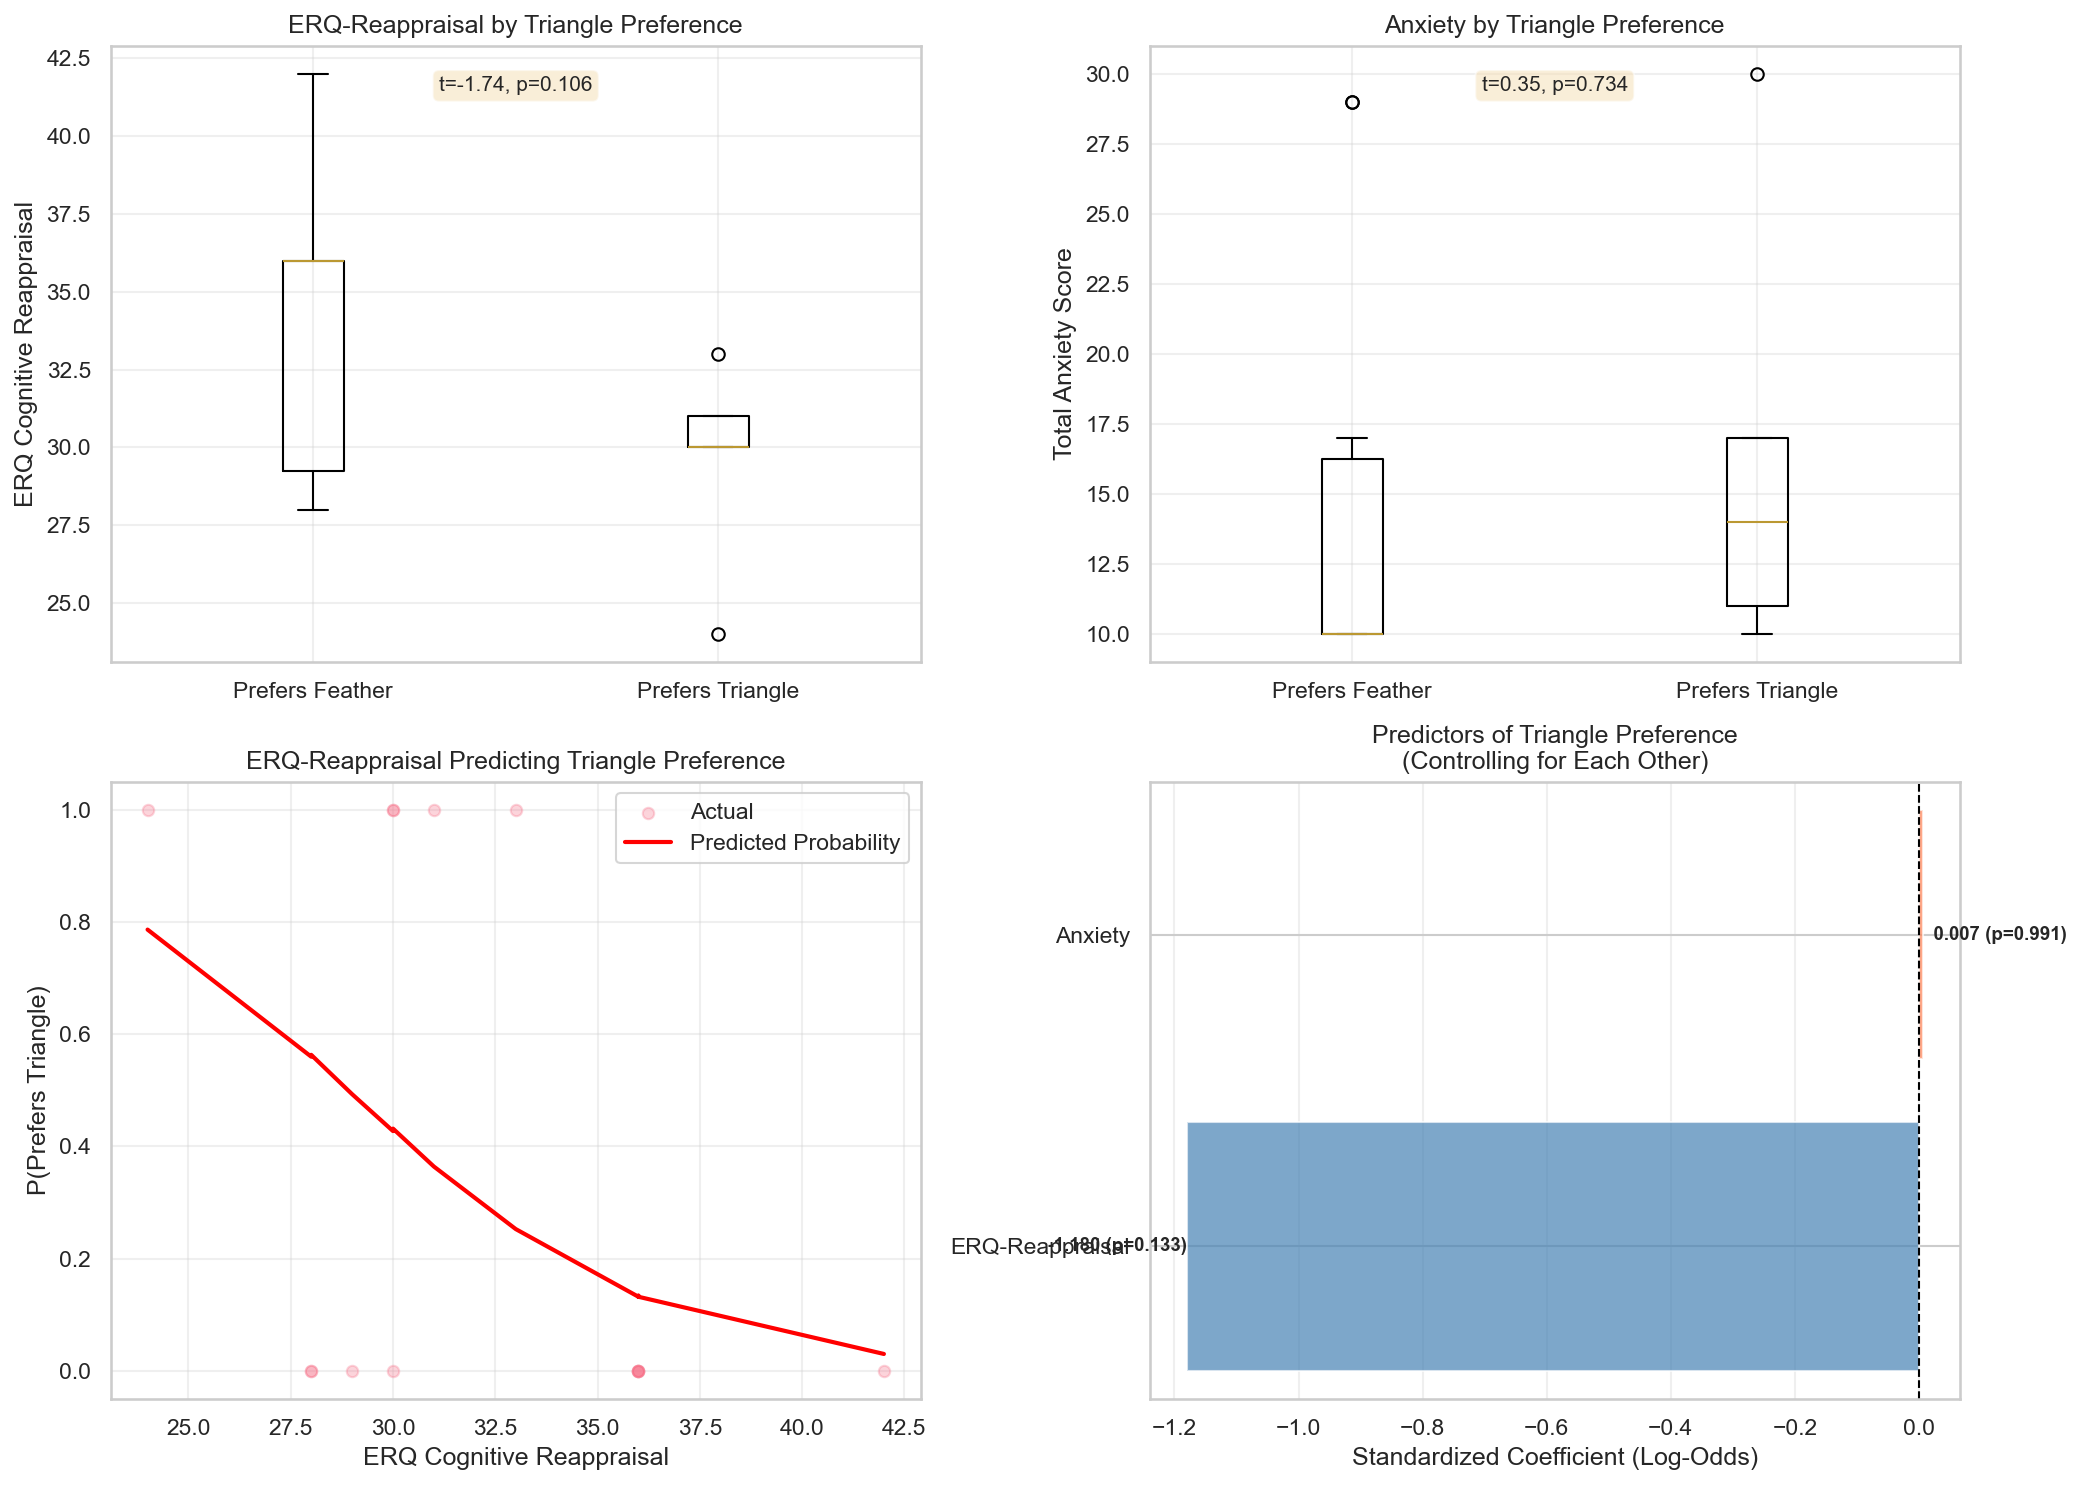

In [13]:
#!/usr/bin/env python3
"""
Analysis: Query 2 - ERQ Reappraisal predicting Triangle > Feather preference
Controlling for anxiety
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load filtered data (no low knowledge subjects)
df = pd.read_csv('filtered_data.csv')
print(f"Loaded {len(df)} subjects (low knowledge filtered out)")
print("="*70)


# Get Query 2 choice and state info
query_2_data = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    
    # Get Query 2 trials (T1-T8)
    query_2_choices = []
    for trial in range(1, 9):
        choice_col = f'Query_2_T{trial}_Choice'
        state_col = f'Query_2_T{trial}_State'
        
        if choice_col in df.columns and not pd.isna(row[choice_col]):
            choice = row[choice_col]
            state = row.get(state_col, np.nan)
            query_2_choices.append({'trial': trial, 'choice': choice, 'state': state})
    
    # Get ratings to determine preference
    # We'll use average across all three revaluations
    triangle_ratings = []
    feather_ratings = []
    for r in [1, 2, 3]:
        t_val = row.get(f'Rating_{r}_Triangle_Val')
        f_val = row.get(f'Rating_{r}_Feather_Val')
        if not pd.isna(t_val):
            triangle_ratings.append(t_val)
        if not pd.isna(f_val):
            feather_ratings.append(f_val)
    
    # Calculate preference
    if triangle_ratings and feather_ratings:
        mean_triangle = np.mean(triangle_ratings)
        mean_feather = np.mean(feather_ratings)
        prefers_triangle = 1 if mean_triangle > mean_feather else 0
        rating_diff = mean_triangle - mean_feather
        
        # Get ERQ and Anxiety scores
        erq_reappraisal = row.get('ERQ_Cognitive_Reappraisal', np.nan)
        anxiety_total = row.get('Score_Anxiety_Total', np.nan)
        
        # Count Query 2 choices
        n_query2_trials = len(query_2_choices)
        
        query_2_data.append({
            'subject_id': subj_id,
            'prefers_triangle': prefers_triangle,
            'triangle_rating': mean_triangle,
            'feather_rating': mean_feather,
            'rating_diff': rating_diff,
            'erq_reappraisal': erq_reappraisal,
            'anxiety_total': anxiety_total,
            'n_query2_trials': n_query2_trials
        })

q2_df = pd.DataFrame(query_2_data)

# Remove subjects with missing data
q2_df_complete = q2_df.dropna(subset=['erq_reappraisal', 'anxiety_total'])
print(f"\nComplete cases for analysis: {len(q2_df_complete)}")

# Descriptive statistics
print(f"\n--- Descriptive Statistics ---")
print(f"Triangle preference rate: {q2_df_complete['prefers_triangle'].mean():.3f}")
print(f"  (Proportion rating Triangle > Feather)")
print(f"\nERQ Cognitive Reappraisal:")
print(f"  Mean: {q2_df_complete['erq_reappraisal'].mean():.2f}")
print(f"  SD: {q2_df_complete['erq_reappraisal'].std():.2f}")
print(f"  Range: {q2_df_complete['erq_reappraisal'].min():.0f} - {q2_df_complete['erq_reappraisal'].max():.0f}")
print(f"\nTotal Anxiety Score:")
print(f"  Mean: {q2_df_complete['anxiety_total'].mean():.2f}")
print(f"  SD: {q2_df_complete['anxiety_total'].std():.2f}")
print(f"  Range: {q2_df_complete['anxiety_total'].min():.0f} - {q2_df_complete['anxiety_total'].max():.0f}")

# Bivariate correlations
print(f"\n--- Bivariate Correlations ---")
corr_erq_pref = stats.pointbiserialr(q2_df_complete['prefers_triangle'], 
                                      q2_df_complete['erq_reappraisal'])
print(f"ERQ-Reappraisal × Triangle Preference: r={corr_erq_pref[0]:.3f}, p={corr_erq_pref[1]:.3f}")

corr_anx_pref = stats.pointbiserialr(q2_df_complete['prefers_triangle'], 
                                      q2_df_complete['anxiety_total'])
print(f"Anxiety × Triangle Preference: r={corr_anx_pref[0]:.3f}, p={corr_anx_pref[1]:.3f}")

corr_erq_anx = stats.pearsonr(q2_df_complete['erq_reappraisal'], 
                               q2_df_complete['anxiety_total'])
print(f"ERQ-Reappraisal × Anxiety: r={corr_erq_anx[0]:.3f}, p={corr_erq_anx[1]:.3f}")

# Logistic Regression with statsmodels (for proper p-values)
print(f"\n" + "="*70)
print("LOGISTIC REGRESSION: Predicting Triangle > Feather Preference")
print("="*70)

# Prepare data - standardize for better interpretation
from scipy.stats import zscore

# Create standardized versions
q2_df_complete['erq_reappraisal_z'] = zscore(q2_df_complete['erq_reappraisal'])
q2_df_complete['anxiety_total_z'] = zscore(q2_df_complete['anxiety_total'])

# Fit full model using statsmodels
X_full = sm.add_constant(q2_df_complete[['erq_reappraisal_z', 'anxiety_total_z']])
y = q2_df_complete['prefers_triangle']

logit_model_full = sm.Logit(y, X_full)
results_full = logit_model_full.fit(disp=0)

# Print full results table
print("\n" + "="*70)
print("FULL LOGISTIC REGRESSION RESULTS TABLE")
print("="*70)
print(results_full.summary())
print("\n")

# Also print odds ratios
print("="*70)
print("ODDS RATIOS (exp(coefficient))")
print("="*70)
odds_ratios = np.exp(results_full.params)
conf_int = np.exp(results_full.conf_int())
odds_table = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    '95% CI Lower': conf_int[0],
    '95% CI Upper': conf_int[1],
    'p-value': results_full.pvalues
})
print(odds_table)
print("\n")

# Fit ERQ-only model for comparison
X_erq = sm.add_constant(q2_df_complete[['erq_reappraisal_z']])
logit_model_erq = sm.Logit(y, X_erq)
results_erq = logit_model_erq.fit(disp=0)

print("="*70)
print("ERQ-REAPPRAISAL ONLY MODEL (for comparison)")
print("="*70)
print(results_erq.summary())
print("\n")

# Model comparison
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"ERQ-only Pseudo R² (McFadden): {results_erq.prsquared:.4f}")
print(f"Full model Pseudo R² (McFadden): {results_full.prsquared:.4f}")
print(f"ΔR² from adding Anxiety: {results_full.prsquared - results_erq.prsquared:.4f}")
print(f"Log-Likelihood ERQ-only: {results_erq.llf:.4f}")
print(f"Log-Likelihood Full: {results_full.llf:.4f}")
print(f"LR test statistic: {2*(results_full.llf - results_erq.llf):.4f}")
print(f"LR test p-value: {stats.chi2.sf(2*(results_full.llf - results_erq.llf), 1):.4f}")

# Store predictions for plotting
y_pred_proba = results_full.predict(X_full)
erq_coef = results_full.params['erq_reappraisal_z']
anx_coef = results_full.params['anxiety_total_z']

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ERQ distribution by preference
ax = axes[0, 0]
triangle_erq = q2_df_complete[q2_df_complete['prefers_triangle'] == 1]['erq_reappraisal']
feather_erq = q2_df_complete[q2_df_complete['prefers_triangle'] == 0]['erq_reappraisal']
ax.boxplot([feather_erq, triangle_erq], labels=['Prefers Feather', 'Prefers Triangle'])
ax.set_ylabel('ERQ Cognitive Reappraisal')
ax.set_title('ERQ-Reappraisal by Triangle Preference')
ax.grid(True, alpha=0.3)

# Add stats
t_test = stats.ttest_ind(triangle_erq, feather_erq)
ax.text(0.5, 0.95, f't={t_test.statistic:.2f}, p={t_test.pvalue:.3f}',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Anxiety distribution by preference
ax = axes[0, 1]
triangle_anx = q2_df_complete[q2_df_complete['prefers_triangle'] == 1]['anxiety_total']
feather_anx = q2_df_complete[q2_df_complete['prefers_triangle'] == 0]['anxiety_total']
ax.boxplot([feather_anx, triangle_anx], labels=['Prefers Feather', 'Prefers Triangle'])
ax.set_ylabel('Total Anxiety Score')
ax.set_title('Anxiety by Triangle Preference')
ax.grid(True, alpha=0.3)

t_test_anx = stats.ttest_ind(triangle_anx, feather_anx)
ax.text(0.5, 0.95, f't={t_test_anx.statistic:.2f}, p={t_test_anx.pvalue:.3f}',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. ERQ vs predicted probability
ax = axes[1, 0]
# Sort by ERQ for smooth line
sort_idx = np.argsort(q2_df_complete['erq_reappraisal'].values)
ax.scatter(q2_df_complete['erq_reappraisal'], 
          q2_df_complete['prefers_triangle'],
          alpha=0.3, s=30, label='Actual')
ax.plot(q2_df_complete['erq_reappraisal'].values[sort_idx], 
       y_pred_proba[sort_idx],
       color='red', linewidth=2, label='Predicted Probability')
ax.set_xlabel('ERQ Cognitive Reappraisal')
ax.set_ylabel('P(Prefers Triangle)')
ax.set_title('ERQ-Reappraisal Predicting Triangle Preference')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Coefficient comparison
ax = axes[1, 1]
coeffs = [results_full.params['erq_reappraisal_z'], results_full.params['anxiety_total_z']]
p_vals = [results_full.pvalues['erq_reappraisal_z'], results_full.pvalues['anxiety_total_z']]
labels = ['ERQ-Reappraisal', 'Anxiety']
colors = ['steelblue', 'coral']
bars = ax.barh(labels, coeffs, color=colors, alpha=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Standardized Coefficient (Log-Odds)')
ax.set_title('Predictors of Triangle Preference\n(Controlling for Each Other)')
ax.grid(True, alpha=0.3, axis='x')

# Add values and p-values on bars
for i, (bar, coef, p) in enumerate(zip(bars, coeffs, p_vals)):
    stars = ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    elif p < 0.1:
        stars = '.'
    
    ax.text(coef, bar.get_y() + bar.get_height()/2, 
           f'  {coef:.3f}{stars} (p={p:.3f})',
           va='center', ha='left' if coef > 0 else 'right',
           fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('query2_erq_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n\nSaved: query2_erq_analysis.png")

# Save results to file
with open('query2_erq_analysis_results.txt', 'w') as f:
    f.write("QUERY 2 ANALYSIS: ERQ-REAPPRAISAL AND TRIANGLE PREFERENCE\n")
    f.write("="*70 + "\n\n")
    f.write(f"Sample Size: {len(q2_df_complete)}\n")
    f.write(f"Triangle Preference Rate: {q2_df_complete['prefers_triangle'].mean():.3f}\n\n")
    
    f.write("BIVARIATE CORRELATIONS:\n")
    f.write(f"  ERQ-Reappraisal × Triangle Pref: r={corr_erq_pref[0]:.3f}, p={corr_erq_pref[1]:.3f}\n")
    f.write(f"  Anxiety × Triangle Pref: r={corr_anx_pref[0]:.3f}, p={corr_anx_pref[1]:.3f}\n")
    f.write(f"  ERQ-Reappraisal × Anxiety: r={corr_erq_anx[0]:.3f}, p={corr_erq_anx[1]:.3f}\n\n")
    
    f.write("="*70 + "\n")
    f.write("LOGISTIC REGRESSION: FULL RESULTS TABLE\n")
    f.write("="*70 + "\n\n")
    f.write(str(results_full.summary()))
    f.write("\n\n")
    
    f.write("="*70 + "\n")
    f.write("ODDS RATIOS\n")
    f.write("="*70 + "\n\n")
    f.write(str(odds_table))
    f.write("\n\n")
    
    f.write("INTERPRETATION:\n")
    f.write(f"  ERQ-Reappraisal: p={results_full.pvalues['erq_reappraisal_z']:.4f}\n")
    if results_full.pvalues['erq_reappraisal_z'] < 0.05:
        if results_full.params['erq_reappraisal_z'] > 0:
            f.write("    → Higher ERQ-Reappraisal SIGNIFICANTLY associated with INCREASED Triangle preference.\n")
        else:
            f.write("    → Higher ERQ-Reappraisal SIGNIFICANTLY associated with DECREASED Triangle preference.\n")
    else:
        f.write("    → No significant relationship with Triangle preference.\n")
    
    f.write(f"\n  Anxiety: p={results_full.pvalues['anxiety_total_z']:.4f}\n")
    if results_full.pvalues['anxiety_total_z'] < 0.05:
        if results_full.params['anxiety_total_z'] > 0:
            f.write("    → Higher Anxiety SIGNIFICANTLY associated with INCREASED Triangle preference.\n")
        else:
            f.write("    → Higher Anxiety SIGNIFICANTLY associated with DECREASED Triangle preference.\n")
    else:
        f.write("    → No significant relationship with Triangle preference (when controlling for ERQ).\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("ERQ-REAPPRAISAL ONLY MODEL\n")
    f.write("="*70 + "\n\n")
    f.write(str(results_erq.summary()))
    f.write("\n\n")
    
    f.write("MODEL COMPARISON:\n")
    f.write(f"  ERQ-only Pseudo R²: {results_erq.prsquared:.4f}\n")
    f.write(f"  Full model Pseudo R²: {results_full.prsquared:.4f}\n")
    f.write(f"  ΔR² from adding Anxiety: {results_full.prsquared - results_erq.prsquared:.4f}\n")

print("\nSaved: query2_erq_analysis_results.txt")
print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

In [ ]:
#!/usr/bin/env python3
"""
Analysis: ERQ Reappraisal predicting Triangle > Feather preference BASED ON RATINGS
Controlling for anxiety
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Load filtered data (no low knowledge subjects)
df = pd.read_csv('filtered_data.csv')
print(f"Loaded {len(df)} subjects (low knowledge filtered out)")
print("="*70)

# Extract rating-based preference
print("\nRATING-BASED PREFERENCE ANALYSIS")
print("="*70)

preference_data = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    
    # Get ratings to determine preference
    # Average across all three revaluations
    triangle_ratings = []
    feather_ratings = []
    for r in [2]:
        t_val = row.get(f'Rating_{r}_Feather_Val')
        f_val = row.get(f'Rating_{r+1}_Feather_Val')
        if not pd.isna(t_val):
            triangle_ratings.append(t_val)
        if not pd.isna(f_val):
            feather_ratings.append(f_val)
    
    # Calculate preference based on RATINGS
    if triangle_ratings and feather_ratings:
        mean_triangle = np.mean(triangle_ratings)
        mean_feather = np.mean(feather_ratings)
        prefers_triangle = 1 if mean_triangle > mean_feather else 0
        rating_diff = mean_triangle-mean_feather
        
        # Get ERQ and Anxiety scores
        erq_reappraisal = row.get('ERQ_Cognitive_Reappraisal', np.nan)
        anxiety_total = row.get('Score_Anxiety_Total', np.nan)
        
        preference_data.append({
            'subject_id': subj_id,
            'prefers_triangle': prefers_triangle,
            'triangle_rating': mean_triangle,
            'feather_rating': mean_feather,
            'rating_diff': rating_diff,
            'erq_reappraisal': erq_reappraisal,
            'anxiety_total': anxiety_total
        })

pref_df = pd.DataFrame(preference_data)

# Remove subjects with missing data
pref_df_complete = pref_df.dropna(subset=['erq_reappraisal', 'anxiety_total'])
print(f"\nComplete cases for analysis: {len(pref_df_complete)}")
print(f"\nOUTCOME: Triangle preference based on RATINGS (average across 3 revaluations)")
print(f"  - Triangle rating > Feather rating = 1")
print(f"  - Triangle rating ≤ Feather rating = 0")

# Descriptive statistics
print(f"\n--- Descriptive Statistics ---")
print(f"Triangle preference rate: {pref_df_complete['prefers_triangle'].mean():.3f}")
print(f"  ({pref_df_complete['prefers_triangle'].sum()}/{len(pref_df_complete)} subjects prefer Triangle)")
print(f"\nMean Triangle rating: {pref_df_complete['triangle_rating'].mean():.2f} (SD={pref_df_complete['triangle_rating'].std():.2f})")
print(f"Mean Feather rating: {pref_df_complete['feather_rating'].mean():.2f} (SD={pref_df_complete['feather_rating'].std():.2f})")
print(f"Mean rating difference (T-F): {pref_df_complete['rating_diff'].mean():.2f} (SD={pref_df_complete['rating_diff'].std():.2f})")

print(f"\nERQ Cognitive Reappraisal:")
print(f"  Mean: {pref_df_complete['erq_reappraisal'].mean():.2f}")
print(f"  SD: {pref_df_complete['erq_reappraisal'].std():.2f}")
print(f"  Range: {pref_df_complete['erq_reappraisal'].min():.0f} - {pref_df_complete['erq_reappraisal'].max():.0f}")
print(f"\nTotal Anxiety Score:")
print(f"  Mean: {pref_df_complete['anxiety_total'].mean():.2f}")
print(f"  SD: {pref_df_complete['anxiety_total'].std():.2f}")
print(f"  Range: {pref_df_complete['anxiety_total'].min():.0f} - {pref_df_complete['anxiety_total'].max():.0f}")

# Bivariate correlations
print(f"\n--- Bivariate Correlations ---")
corr_erq_pref = stats.pointbiserialr(pref_df_complete['prefers_triangle'], 
                                      pref_df_complete['erq_reappraisal'])
print(f"ERQ-Reappraisal × Triangle Preference: r={corr_erq_pref[0]:.3f}, p={corr_erq_pref[1]:.3f}")

corr_anx_pref = stats.pointbiserialr(pref_df_complete['prefers_triangle'], 
                                      pref_df_complete['anxiety_total'])
print(f"Anxiety × Triangle Preference: r={corr_anx_pref[0]:.3f}, p={corr_anx_pref[1]:.3f}")

corr_erq_anx = stats.pearsonr(pref_df_complete['erq_reappraisal'], 
                               pref_df_complete['anxiety_total'])
print(f"ERQ-Reappraisal × Anxiety: r={corr_erq_anx[0]:.3f}, p={corr_erq_anx[1]:.3f}")

# Logistic Regression with full statistical inference
print(f"\n" + "="*70)
print("LOGISTIC REGRESSION: Predicting Triangle > Feather Preference")
print("="*70)

# Prepare data - standardize for better interpretation
from scipy.stats import zscore
from scipy.optimize import minimize
from scipy.stats import norm

# Create standardized versions
pref_df_complete['erq_reappraisal_z'] = zscore(pref_df_complete['erq_reappraisal'])
pref_df_complete['anxiety_total_z'] = zscore(pref_df_complete['anxiety_total'])

def fit_logistic_regression(X, y, var_names):
    """
    Fit logistic regression with full statistical inference
    Returns: dictionary with coefficients, SEs, z-stats, p-values, CIs
    """
    # Add intercept
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    
    def negative_log_likelihood(beta):
        """Negative log-likelihood for logistic regression"""
        linear_pred = X_with_intercept @ beta
        # Numerically stable log-likelihood
        log_likelihood = np.sum(y * linear_pred - np.log(1 + np.exp(linear_pred)))
        return -log_likelihood
    
    # Optimize
    n_params = X_with_intercept.shape[1]
    beta_init = np.zeros(n_params)
    result = minimize(negative_log_likelihood, beta_init, method='BFGS')
    beta_hat = result.x
    
    # Compute Hessian for standard errors
    linear_pred = X_with_intercept @ beta_hat
    p_pred = 1 / (1 + np.exp(-linear_pred))
    W = np.diag(p_pred * (1 - p_pred))
    
    # Variance-covariance matrix (inverse of information matrix)
    try:
        var_covar = np.linalg.inv(X_with_intercept.T @ W @ X_with_intercept)
        se = np.sqrt(np.diag(var_covar))
    except:
        # If matrix is singular, use a small regularization
        var_covar = np.linalg.inv(X_with_intercept.T @ W @ X_with_intercept + 1e-6 * np.eye(n_params))
        se = np.sqrt(np.diag(var_covar))
    
    # Z-statistics and p-values
    z_stats = beta_hat / se
    p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))
    
    # 95% Confidence intervals
    ci_lower = beta_hat - 1.96 * se
    ci_upper = beta_hat + 1.96 * se
    
    # Log-likelihood
    ll = -negative_log_likelihood(beta_hat)
    
    # Null model log-likelihood
    p_null = y.mean()
    ll_null = np.sum(y * np.log(p_null + 1e-10) + (1 - y) * np.log(1 - p_null + 1e-10))
    
    # McFadden's Pseudo R²
    pseudo_r2 = 1 - (ll / ll_null)
    
    return {
        'coefficients': beta_hat,
        'se': se,
        'z_stats': z_stats,
        'p_values': p_values,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'var_names': ['const'] + var_names,
        'predictions': p_pred,
        'll': ll,
        'll_null': ll_null,
        'pseudo_r2': pseudo_r2,
        'n_obs': len(y)
    }

# Fit full model (ERQ + Anxiety)
X_full = pref_df_complete[['erq_reappraisal_z', 'anxiety_total_z']].values
y = pref_df_complete['prefers_triangle'].values
var_names_full = ['erq_reappraisal_z', 'anxiety_total_z']

results_full = fit_logistic_regression(X_full, y, var_names_full)

# Print full results table
print("\n" + "="*70)
print("FULL LOGISTIC REGRESSION RESULTS")
print("="*70)
print(f"\nDependent Variable: Triangle Preference (1 = prefers Triangle > Feather)")
print(f"Model: Logit")
print(f"Method: Maximum Likelihood Estimation")
print(f"Number of observations: {results_full['n_obs']}")
print(f"Pseudo R-squared (McFadden): {results_full['pseudo_r2']:.4f}")
print(f"Log-Likelihood: {results_full['ll']:.4f}")
print(f"Log-Likelihood (null): {results_full['ll_null']:.4f}")

print("\n" + "="*70)
print(f"{'Variable':<20} {'Coef.':>10} {'Std.Err.':>10} {'z':>10} {'P>|z|':>10} {'[0.025':>10} {'0.975]':>10}")
print("-"*70)

for i, var_name in enumerate(results_full['var_names']):
    coef = results_full['coefficients'][i]
    se = results_full['se'][i]
    z = results_full['z_stats'][i]
    p = results_full['p_values'][i]
    ci_low = results_full['ci_lower'][i]
    ci_high = results_full['ci_upper'][i]
    
    # Significance stars
    stars = ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    elif p < 0.1:
        stars = '.'
    
    print(f"{var_name:<20} {coef:10.4f} {se:10.4f} {z:10.3f} {p:10.4f}{stars:>3} {ci_low:10.4f} {ci_high:10.4f}")

print("-"*70)
print("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")
print("\n")

# Odds ratios table
print("="*70)
print("ODDS RATIOS (exp(coef)) - Per 1 SD increase for continuous variables")
print("="*70)
print(f"{'Variable':<20} {'Odds Ratio':>12} {'[0.025':>10} {'0.975]':>10} {'P>|z|':>10}")
print("-"*70)

for i, var_name in enumerate(results_full['var_names'][1:], start=1):  # Skip intercept
    or_val = np.exp(results_full['coefficients'][i])
    or_ci_low = np.exp(results_full['ci_lower'][i])
    or_ci_high = np.exp(results_full['ci_upper'][i])
    p = results_full['p_values'][i]
    
    stars = ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    elif p < 0.1:
        stars = '.'
    
    print(f"{var_name:<20} {or_val:12.4f} {or_ci_low:10.4f} {or_ci_high:10.4f} {p:10.4f}{stars:>3}")

print("-"*70)
print("\nInterpretation of Odds Ratios:")
print("  - OR > 1: Positive association (higher predictor → higher odds of Triangle preference)")
print("  - OR < 1: Negative association (higher predictor → lower odds of Triangle preference)")
print("  - OR = 1: No association")
print("\n")

# Fit ERQ-only model for comparison
X_erq = pref_df_complete[['erq_reappraisal_z']].values
var_names_erq = ['erq_reappraisal_z']
results_erq = fit_logistic_regression(X_erq, y, var_names_erq)

print("="*70)
print("ERQ-REAPPRAISAL ONLY MODEL (for comparison)")
print("="*70)
print(f"\nPseudo R-squared (McFadden): {results_erq['pseudo_r2']:.4f}")
print(f"Log-Likelihood: {results_erq['ll']:.4f}")

print("\n" + "-"*70)
print(f"{'Variable':<20} {'Coef.':>10} {'Std.Err.':>10} {'z':>10} {'P>|z|':>10} {'OR':>10}")
print("-"*70)

for i, var_name in enumerate(results_erq['var_names']):
    coef = results_erq['coefficients'][i]
    se = results_erq['se'][i]
    z = results_erq['z_stats'][i]
    p = results_erq['p_values'][i]
    or_val = np.exp(coef) if i > 0 else np.nan
    
    stars = ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    elif p < 0.1:
        stars = '.'
    
    if i > 0:
        print(f"{var_name:<20} {coef:10.4f} {se:10.4f} {z:10.3f} {p:10.4f}{stars:>3} {or_val:10.4f}")
    else:
        print(f"{var_name:<20} {coef:10.4f} {se:10.4f} {z:10.3f} {p:10.4f}{stars:>3} {'---':>10}")

print("-"*70)
print("\n")

# Model comparison
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"ERQ-only Pseudo R²: {results_erq['pseudo_r2']:.4f}")
print(f"Full model Pseudo R²: {results_full['pseudo_r2']:.4f}")
print(f"Improvement (ΔR²): {results_full['pseudo_r2'] - results_erq['pseudo_r2']:.4f}")
print(f"\nLog-Likelihood Ratio Test:")
lr_stat = 2 * (results_full['ll'] - results_erq['ll'])
lr_p = stats.chi2.sf(lr_stat, 1)  # 1 df for adding anxiety
print(f"  LR χ² statistic: {lr_stat:.4f}")
print(f"  df: 1")
print(f"  p-value: {lr_p:.4f}")
if lr_p < 0.05:
    print(f"  → Full model provides SIGNIFICANT improvement over ERQ-only model")
else:
    print(f"  → Full model does NOT provide significant improvement over ERQ-only model")

# Store predictions and coefficients for plotting
y_pred_proba = results_full['predictions']
erq_coef = results_full['coefficients'][1]
anx_coef = results_full['coefficients'][2]

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ERQ distribution by preference
ax = axes[0, 0]
triangle_erq = pref_df_complete[pref_df_complete['prefers_triangle'] == 1]['erq_reappraisal']
feather_erq = pref_df_complete[pref_df_complete['prefers_triangle'] == 0]['erq_reappraisal']
ax.boxplot([feather_erq, triangle_erq], labels=['Rated Feather Higher', 'Rated Triangle Higher'])
ax.set_ylabel('ERQ Cognitive Reappraisal')
ax.set_title('ERQ-Reappraisal by Rating-Based Preference')
ax.grid(True, alpha=0.3)

# Add stats
t_test = stats.ttest_ind(triangle_erq, feather_erq)
ax.text(0.5, 0.95, f't={t_test.statistic:.2f}, p={t_test.pvalue:.3f}',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Anxiety distribution by preference
ax = axes[0, 1]
triangle_anx = pref_df_complete[pref_df_complete['prefers_triangle'] == 1]['anxiety_total']
feather_anx = pref_df_complete[pref_df_complete['prefers_triangle'] == 0]['anxiety_total']
ax.boxplot([feather_anx, triangle_anx], labels=['Rated Feather Higher', 'Rated Triangle Higher'])
ax.set_ylabel('Total Anxiety Score')
ax.set_title('Anxiety by Rating-Based Preference')
ax.grid(True, alpha=0.3)

t_test_anx = stats.ttest_ind(triangle_anx, feather_anx)
ax.text(0.5, 0.95, f't={t_test_anx.statistic:.2f}, p={t_test_anx.pvalue:.3f}',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. ERQ vs predicted probability
ax = axes[1, 0]
# Sort by ERQ for smooth line
sort_idx = np.argsort(pref_df_complete['erq_reappraisal'].values)
ax.scatter(pref_df_complete['erq_reappraisal'], 
          pref_df_complete['prefers_triangle'],
          alpha=0.3, s=30, label='Actual')
ax.plot(pref_df_complete['erq_reappraisal'].values[sort_idx], 
       y_pred_proba[sort_idx],
       color='red', linewidth=2, label='Predicted Probability')
ax.set_xlabel('ERQ Cognitive Reappraisal')
ax.set_ylabel('P(Rated Triangle > Feather)')
ax.set_title('ERQ-Reappraisal Predicting Rating-Based Preference')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Coefficient comparison
ax = axes[1, 1]
coeffs = [results_full['coefficients'][1], results_full['coefficients'][2]]  # ERQ, Anxiety
p_vals = [results_full['p_values'][1], results_full['p_values'][2]]
labels = ['ERQ-Reappraisal', 'Anxiety']
colors = ['steelblue', 'coral']
bars = ax.barh(labels, coeffs, color=colors, alpha=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Standardized Coefficient (Log-Odds)')
ax.set_title('Predictors of Rating-Based Preference\n(Controlling for Each Other)')
ax.grid(True, alpha=0.3, axis='x')

# Add values and p-values on bars
for i, (bar, coef, p) in enumerate(zip(bars, coeffs, p_vals)):
    stars = ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    elif p < 0.1:
        stars = '.'
    
    ax.text(coef, bar.get_y() + bar.get_height()/2, 
           f'  {coef:.3f}{stars} (p={p:.3f})',
           va='center', ha='left' if coef > 0 else 'right',
           fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('rating_based_erq_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n\nSaved: rating_based_erq_analysis.png")

# Save results to file
with open('rating_based_erq_analysis_results.txt', 'w') as f:
    f.write("RATING-BASED PREFERENCE ANALYSIS: ERQ-REAPPRAISAL AND TRIANGLE PREFERENCE\n")
    f.write("="*70 + "\n\n")
    f.write(f"Sample Size: {len(pref_df_complete)}\n")
    f.write(f"Triangle Preference Rate: {pref_df_complete['prefers_triangle'].mean():.3f}\n")
    f.write(f"  ({pref_df_complete['prefers_triangle'].sum()}/{len(pref_df_complete)} subjects rated Triangle > Feather)\n\n")
    
    f.write("BIVARIATE CORRELATIONS:\n")
    f.write(f"  ERQ-Reappraisal × Triangle Pref: r={corr_erq_pref[0]:.3f}, p={corr_erq_pref[1]:.3f}\n")
    f.write(f"  Anxiety × Triangle Pref: r={corr_anx_pref[0]:.3f}, p={corr_anx_pref[1]:.3f}\n")
    f.write(f"  ERQ-Reappraisal × Anxiety: r={corr_erq_anx[0]:.3f}, p={corr_erq_anx[1]:.3f}\n\n")
    
    f.write("="*70 + "\n")
    f.write("LOGISTIC REGRESSION: FULL RESULTS TABLE\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Model: Logit\n")
    f.write(f"Number of observations: {results_full['n_obs']}\n")
    f.write(f"Pseudo R-squared (McFadden): {results_full['pseudo_r2']:.4f}\n")
    f.write(f"Log-Likelihood: {results_full['ll']:.4f}\n\n")
    
    f.write(f"{'Variable':<20} {'Coef.':>10} {'Std.Err.':>10} {'z':>10} {'P>|z|':>10} {'[95% CI]':>22}\n")
    f.write("-"*70 + "\n")
    
    for i, var_name in enumerate(results_full['var_names']):
        coef = results_full['coefficients'][i]
        se = results_full['se'][i]
        z = results_full['z_stats'][i]
        p = results_full['p_values'][i]
        ci_low = results_full['ci_lower'][i]
        ci_high = results_full['ci_upper'][i]
        
        stars = ''
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        elif p < 0.1:
            stars = '.'
        
        f.write(f"{var_name:<20} {coef:10.4f} {se:10.4f} {z:10.3f} {p:10.4f}{stars:>3} [{ci_low:7.4f}, {ci_high:7.4f}]\n")
    
    f.write("-"*70 + "\n")
    f.write("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1\n\n")
    
    f.write("\nODDS RATIOS:\n")
    f.write(f"{'Variable':<20} {'OR':>10} {'[95% CI]':>22} {'P>|z|':>10}\n")
    f.write("-"*70 + "\n")
    for i, var_name in enumerate(results_full['var_names'][1:], start=1):
        or_val = np.exp(results_full['coefficients'][i])
        or_ci_low = np.exp(results_full['ci_lower'][i])
        or_ci_high = np.exp(results_full['ci_upper'][i])
        p = results_full['p_values'][i]
        
        stars = ''
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        elif p < 0.1:
            stars = '.'
        
        f.write(f"{var_name:<20} {or_val:10.4f} [{or_ci_low:7.4f}, {or_ci_high:7.4f}] {p:10.4f}{stars:>3}\n")
    f.write("\n")
    
    f.write("INTERPRETATION:\n")
    f.write(f"  ERQ-Reappraisal: coef={results_full['coefficients'][1]:.4f}, p={results_full['p_values'][1]:.4f}\n")
    if results_full['p_values'][1] < 0.05:
        if results_full['coefficients'][1] > 0:
            f.write("    → Higher ERQ-Reappraisal SIGNIFICANTLY associated with INCREASED Triangle preference.\n")
        else:
            f.write("    → Higher ERQ-Reappraisal SIGNIFICANTLY associated with DECREASED Triangle preference.\n")
    else:
        f.write("    → No significant relationship with Triangle preference.\n")
    
    f.write(f"\n  Anxiety: coef={results_full['coefficients'][2]:.4f}, p={results_full['p_values'][2]:.4f}\n")
    if results_full['p_values'][2] < 0.05:
        if results_full['coefficients'][2] > 0:
            f.write("    → Higher Anxiety SIGNIFICANTLY associated with INCREASED Triangle preference.\n")
        else:
            f.write("    → Higher Anxiety SIGNIFICANTLY associated with DECREASED Triangle preference.\n")
    else:
        f.write("    → No significant relationship with Triangle preference (when controlling for ERQ).\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("ERQ-REAPPRAISAL ONLY MODEL\n")
    f.write("="*70 + "\n\n")
    f.write(f"Pseudo R-squared (McFadden): {results_erq['pseudo_r2']:.4f}\n")
    f.write(f"Log-Likelihood: {results_erq['ll']:.4f}\n\n")
    f.write(f"ERQ-Reappraisal coefficient: {results_erq['coefficients'][1]:.4f}\n")
    f.write(f"Standard error: {results_erq['se'][1]:.4f}\n")
    f.write(f"z-statistic: {results_erq['z_stats'][1]:.3f}\n")
    f.write(f"p-value: {results_erq['p_values'][1]:.4f}\n")
    f.write(f"Odds ratio: {np.exp(results_erq['coefficients'][1]):.4f}\n\n")
    
    f.write("MODEL COMPARISON:\n")
    f.write(f"  ERQ-only Pseudo R²: {results_erq['pseudo_r2']:.4f}\n")
    f.write(f"  Full model Pseudo R²: {results_full['pseudo_r2']:.4f}\n")
    f.write(f"  ΔR² from adding Anxiety: {results_full['pseudo_r2'] - results_erq['pseudo_r2']:.4f}\n")
    
    lr_stat = 2 * (results_full['ll'] - results_erq['ll'])
    lr_p = stats.chi2.sf(lr_stat, 1)
    f.write(f"  LR test χ²(1): {lr_stat:.4f}, p={lr_p:.4f}\n")

print("\nSaved: rating_based_erq_analysis_results.txt")
print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_rel, ttest_ind
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RATING ACCURACY ANALYSIS: Distance from True Expected Values")
print("="*80)

# Load filtered data
df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

# Get individual difference measures
df['Anxiety_Total'] = df['Survey_ANXIETY_1_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}")

# ============================================================================
# DEFINE TRUE EXPECTED VALUES
# ============================================================================
print("\n" + "="*80)
print("TRUE EXPECTED VALUES BY QUERY")
print("="*80)


Q0_EV = {'Feather': 5, 'Triangle': -5}

# Query 1: Based on actual outcomes during Query 1
# Feather EV = -15, Triangle EV = 15
Q1_EV = {'Feather': -15, 'Triangle': 15}

# Query 2: Based on actual outcomes during Query 2  
# Feather EV = 0, Triangle EV = 10
Q2_EV = {'Feather': 0, 'Triangle': 10}

print("\nQuery 1 (after Reflection 1):")
print(f"  Feather EV: {Q1_EV['Feather']}")
print(f"  Triangle EV: {Q1_EV['Triangle']}")

print("\nQuery 2 (after Reflection 2):")
print(f"  Feather EV: {Q2_EV['Feather']}")
print(f"  Triangle EV: {Q2_EV['Triangle']}")

# ============================================================================
# CALCULATE RATING ERRORS (Rating - True EV)
# ============================================================================
print("\n" + "="*80)
print("CALCULATING RATING ERRORS")
print("="*80)

print("""
LOGIC:
Rating Error = Actual Rating - True EV

Interpretation:
- Error = 0: Perfect accuracy
- Error > 0: Over-valued (rated higher than true EV)
- Error < 0: Under-valued (rated lower than true EV)

For example:
- True Feather EV in Q1 = -15
- If rated Feather = -10, Error = -10 - (-15) = +5 (over-valued by 5)
- If rated Feather = -20, Error = -20 - (-15) = -5 (under-valued by 5)
""")

# Rating 1: After initial MF learning (before any queries)
# We don't have true EVs for this period, but we can use Q1 EVs as reference
df['R1_Feather_Error'] = df['Rating_1_Feather_Val'] - Q0_EV['Feather']
df['R1_Triangle_Error'] = df['Rating_1_Triangle_Val'] - Q0_EV['Triangle']

# Rating 2: After Reflection 1, before Query 1
# Compare to Query 1 EVs (the relevant EVs at this time)
df['R2_Feather_Error'] = df['Rating_2_Feather_Val'] - Q1_EV['Feather']
df['R2_Triangle_Error'] = df['Rating_2_Triangle_Val'] - Q1_EV['Triangle']

# Rating 3: After Reflection 2, before Query 2
# Compare to Query 2 EVs (the relevant EVs at this time)
df['R3_Feather_Error'] = df['Rating_3_Feather_Val'] - Q2_EV['Feather']
df['R3_Triangle_Error'] = df['Rating_3_Triangle_Val'] - Q2_EV['Triangle']

# Also calculate absolute errors (unsigned)
df['R1_Feather_AbsError'] = abs(df['R1_Feather_Error'])
df['R1_Triangle_AbsError'] = abs(df['R1_Triangle_Error'])
df['R2_Feather_AbsError'] = abs(df['R2_Feather_Error'])
df['R2_Triangle_AbsError'] = abs(df['R2_Triangle_Error'])
df['R3_Feather_AbsError'] = abs(df['R3_Feather_Error'])
df['R3_Triangle_AbsError'] = abs(df['R3_Triangle_Error'])

# ============================================================================
# DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*80)
print("RATING ERRORS: DESCRIPTIVE STATISTICS")
print("="*80)

print("\nSIGNED ERRORS (Positive = Over-valued, Negative = Under-valued):")
print("-" * 80)

print("\nRating 1 (Post-MF Learning, compared to Q1 EVs):")
print(f"  Feather: M={df['R1_Feather_Error'].mean():>6.2f}, SD={df['R1_Feather_Error'].std():>6.2f} (True EV={Q0_EV['Feather']:>3})")
print(f"  Triangle: M={df['R1_Triangle_Error'].mean():>6.2f}, SD={df['R1_Triangle_Error'].std():>6.2f} (True EV={Q0_EV['Triangle']:>3})")

print("\nRating 2 (After Reflection 1, compared to Q1 EVs):")
print(f"  Feather: M={df['R2_Feather_Error'].mean():>6.2f}, SD={df['R2_Feather_Error'].std():>6.2f} (True EV={Q1_EV['Feather']:>3})")
print(f"  Triangle: M={df['R2_Triangle_Error'].mean():>6.2f}, SD={df['R2_Triangle_Error'].std():>6.2f} (True EV={Q1_EV['Triangle']:>3})")

print("\nRating 3 (After Reflection 2, compared to Q2 EVs):")
print(f"  Feather: M={df['R3_Feather_Error'].mean():>6.2f}, SD={df['R3_Feather_Error'].std():>6.2f} (True EV={Q2_EV['Feather']:>3})")
print(f"  Triangle: M={df['R3_Triangle_Error'].mean():>6.2f}, SD={df['R3_Triangle_Error'].std():>6.2f} (True EV={Q2_EV['Triangle']:>3})")

print("\n" + "-" * 80)
print("\nABSOLUTE ERRORS (Unsigned distance from true EV):")
print("-" * 80)

print("\nRating 1:")
print(f"  Feather: M={df['R1_Feather_AbsError'].mean():>6.2f}, SD={df['R1_Feather_AbsError'].std():>6.2f}")
print(f"  Triangle: M={df['R1_Triangle_AbsError'].mean():>6.2f}, SD={df['R1_Triangle_AbsError'].std():>6.2f}")

print("\nRating 2:")
print(f"  Feather: M={df['R2_Feather_AbsError'].mean():>6.2f}, SD={df['R2_Feather_AbsError'].std():>6.2f}")
print(f"  Triangle: M={df['R2_Triangle_AbsError'].mean():>6.2f}, SD={df['R2_Triangle_AbsError'].std():>6.2f}")

print("\nRating 3:")
print(f"  Feather: M={df['R3_Feather_AbsError'].mean():>6.2f}, SD={df['R3_Feather_AbsError'].std():>6.2f}")
print(f"  Triangle: M={df['R3_Triangle_AbsError'].mean():>6.2f}, SD={df['R3_Triangle_AbsError'].std():>6.2f}")

# ============================================================================
# TEMPORAL EVOLUTION
# ============================================================================
print("\n" + "="*80)
print("TEMPORAL EVOLUTION: Do Errors Decrease Over Time?")
print("="*80)

# Test if absolute errors decrease over time
print("\nFeather Absolute Error Over Time:")
feather_errors = [df['R1_Feather_AbsError'].mean(), 
                  df['R2_Feather_AbsError'].mean(), 
                  df['R3_Feather_AbsError'].mean()]
print(f"  R1 → R2 → R3: {feather_errors[0]:.2f} → {feather_errors[1]:.2f} → {feather_errors[2]:.2f}")

t_f12, p_f12 = ttest_rel(df['R1_Feather_AbsError'], df['R2_Feather_AbsError'])
t_f23, p_f23 = ttest_rel(df['R2_Feather_AbsError'], df['R3_Feather_AbsError'])
t_f13, p_f13 = ttest_rel(df['R1_Feather_AbsError'], df['R3_Feather_AbsError'])

print(f"  R1 vs R2: t={t_f12:.3f}, p={p_f12:.4f}")
print(f"  R2 vs R3: t={t_f23:.3f}, p={p_f23:.4f}")
print(f"  R1 vs R3: t={t_f13:.3f}, p={p_f13:.4f}")

print("\nTriangle Absolute Error Over Time:")
triangle_errors = [df['R1_Triangle_AbsError'].mean(), 
                   df['R2_Triangle_AbsError'].mean(), 
                   df['R3_Triangle_AbsError'].mean()]
print(f"  R1 → R2 → R3: {triangle_errors[0]:.2f} → {triangle_errors[1]:.2f} → {triangle_errors[2]:.2f}")

t_t12, p_t12 = ttest_rel(df['R1_Triangle_AbsError'], df['R2_Triangle_AbsError'])
t_t23, p_t23 = ttest_rel(df['R2_Triangle_AbsError'], df['R3_Triangle_AbsError'])
t_t13, p_t13 = ttest_rel(df['R1_Triangle_AbsError'], df['R3_Triangle_AbsError'])

print(f"  R1 vs R2: t={t_t12:.3f}, p={p_t12:.4f}")
print(f"  R2 vs R3: t={t_t23:.3f}, p={p_t23:.4f}")
print(f"  R1 vs R3: t={t_t13:.3f}, p={p_t13:.4f}")

# Test for bias direction changes
print("\n" + "-" * 80)
print("SIGNED ERROR EVOLUTION (Testing for bias changes):")
print("-" * 80)

print("\nFeather Signed Error Over Time:")
print(f"  R1 → R2 → R3: {df['R1_Feather_Error'].mean():.2f} → {df['R2_Feather_Error'].mean():.2f} → {df['R3_Feather_Error'].mean():.2f}")

print("\nTriangle Signed Error Over Time:")
print(f"  R1 → R2 → R3: {df['R1_Triangle_Error'].mean():.2f} → {df['R2_Triangle_Error'].mean():.2f} → {df['R3_Triangle_Error'].mean():.2f}")

# ============================================================================
# INDIVIDUAL DIFFERENCES
# ============================================================================
print("\n" + "="*80)
print("INDIVIDUAL DIFFERENCES: Correlations with Anxiety and ERQ")
print("="*80)

error_measures = {
    'R1 Feather Error': 'R1_Feather_Error',
    'R1 Triangle Error': 'R1_Triangle_Error',
    'R2 Feather Error': 'R2_Feather_Error',
    'R2 Triangle Error': 'R2_Triangle_Error',
    'R3 Feather Error': 'R3_Feather_Error',
    'R3 Triangle Error': 'R3_Triangle_Error',
    'R1 Feather |Error|': 'R1_Feather_AbsError',
    'R1 Triangle |Error|': 'R1_Triangle_AbsError',
    'R2 Feather |Error|': 'R2_Feather_AbsError',
    'R2 Triangle |Error|': 'R2_Triangle_AbsError',
    'R3 Feather |Error|': 'R3_Feather_AbsError',
    'R3 Triangle |Error|': 'R3_Triangle_AbsError'
}

individual_diffs = {
    'Anxiety': 'Anxiety_Total',
    'ERQ Reappraisal': 'ERQ_Reappraisal',
    'ERQ Suppression': 'ERQ_Suppression'
}

print("\nCorrelation Matrix:")
print("-" * 95)
print(f"{'Error Measure':<25} | {'Anxiety':>20} | {'ERQ Reappraisal':>20} | {'ERQ Suppression':>20}")
print("-" * 95)

correlation_results = []

for error_name, error_var in error_measures.items():
    row_data = {'Measure': error_name}
    result_str = f"{error_name:<25} | "
    
    for diff_name, diff_var in individual_diffs.items():
        valid_data = df[[error_var, diff_var]].dropna()
        
        if len(valid_data) > 2:
            r, p = pearsonr(valid_data[error_var], valid_data[diff_var])
            row_data[f'{diff_name}_r'] = r
            row_data[f'{diff_name}_p'] = p
            
            sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            result_str += f"r={r:>6.3f} (p={p:.3f}){sig_marker:<3} | "
        else:
            result_str += f"{'N/A':>20} | "
    
    print(result_str)
    correlation_results.append(row_data)

corr_results_df = pd.DataFrame(correlation_results)

# ============================================================================
# MEDIAN SPLIT ANALYSES
# ============================================================================
print("\n" + "="*80)
print("MEDIAN SPLIT COMPARISONS")
print("="*80)

print("\n--- ANXIETY GROUPS ---")
print(f"Low Anxiety (n={sum(df['Anxiety_Group']=='Low')})")
print(f"High Anxiety (n={sum(df['Anxiety_Group']=='High')})")
print("-" * 80)

for error_name, error_var in error_measures.items():
    low = df[df['Anxiety_Group']=='Low'][error_var].dropna()
    high = df[df['Anxiety_Group']=='High'][error_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{error_name:<25}: Low={low.mean():>6.2f}, High={high.mean():>6.2f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:>6.3f}")

print("\n--- ERQ REAPPRAISAL GROUPS ---")
print(f"Low ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='Low')})")
print(f"High ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='High')})")
print("-" * 80)

for error_name, error_var in error_measures.items():
    low = df[df['ERQ_Reappraisal_Group']=='Low'][error_var].dropna()
    high = df[df['ERQ_Reappraisal_Group']=='High'][error_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{error_name:<25}: Low={low.mean():>6.2f}, High={high.mean():>6.2f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:>6.3f}")

# ============================================================================
# SAVE DATA
# ============================================================================

# Create long-format data for visualization
rating_error_long = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    erq_reapp_group = row['ERQ_Reappraisal_Group']
    
    # Rating 1
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 1,
        'time_label': 'Post-MF Learning',
        'state': 'Feather',
        'rating': row['Rating_1_Feather_Val'],
        'true_ev': Q0_EV['Feather'],
        'error': row['R1_Feather_Error'],
        'abs_error': row['R1_Feather_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 1,
        'time_label': 'Post-MF Learning',
        'state': 'Triangle',
        'rating': row['Rating_1_Triangle_Val'],
        'true_ev': Q0_EV['Triangle'],
        'error': row['R1_Triangle_Error'],
        'abs_error': row['R1_Triangle_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    # Rating 2
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 2,
        'time_label': 'After Reflection 1',
        'state': 'Feather',
        'rating': row['Rating_2_Feather_Val'],
        'true_ev': Q1_EV['Feather'],
        'error': row['R2_Feather_Error'],
        'abs_error': row['R2_Feather_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 2,
        'time_label': 'After Reflection 1',
        'state': 'Triangle',
        'rating': row['Rating_2_Triangle_Val'],
        'true_ev': Q1_EV['Triangle'],
        'error': row['R2_Triangle_Error'],
        'abs_error': row['R2_Triangle_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    # Rating 3
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 3,
        'time_label': 'After Reflection 2',
        'state': 'Feather',
        'rating': row['Rating_3_Feather_Val'],
        'true_ev': Q2_EV['Feather'],
        'error': row['R3_Feather_Error'],
        'abs_error': row['R3_Feather_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 3,
        'time_label': 'After Reflection 2',
        'state': 'Triangle',
        'rating': row['Rating_3_Triangle_Val'],
        'true_ev': Q2_EV['Triangle'],
        'error': row['R3_Triangle_Error'],
        'abs_error': row['R3_Triangle_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })

rating_error_df = pd.DataFrame(rating_error_long)

# Save data
df.to_csv('rating_accuracy_subject_level.csv', index=False)
rating_error_df.to_csv('rating_accuracy_long.csv', index=False)
corr_results_df.to_csv('rating_accuracy_correlations.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - rating_accuracy_subject_level.csv")
print("  - rating_accuracy_long.csv")
print("  - rating_accuracy_correlations.csv")
print("="*80)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# Load data
rating_error_df = pd.read_csv('rating_accuracy_long.csv')
subject_df = pd.read_csv('rating_accuracy_subject_level.csv')

print("Creating rating accuracy visualizations...")

# ============================================================================
# FIGURE 1: TEMPORAL EVOLUTION OF RATING ERRORS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Absolute errors over time by state
ax = axes[0, 0]
for state, color, marker in [('Feather', '#FF6B6B', 'o'), ('Triangle', '#4ECDC4', 's')]:
    state_data = rating_error_df[rating_error_df['state'] == state]
    means = state_data.groupby('time_point')['abs_error'].mean()
    sems = state_data.groupby('time_point')['abs_error'].sem()
    
    ax.errorbar([1, 2, 3], means, yerr=sems, marker=marker, markersize=8,
                linewidth=2, capsize=5, label=state, color=color)

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Perfect Accuracy')
ax.set_xlabel('Time Point', fontsize=11)
ax.set_ylabel('Absolute Rating Error', fontsize=11)
ax.set_title('Rating Accuracy Improves Over Time', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF\nLearning', 'After\nReflection 1', 'After\nReflection 2'])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0, 25])

# Panel B: Signed errors over time by state
ax = axes[0, 1]
for state, color, marker in [('Feather', '#FF6B6B', 'o'), ('Triangle', '#4ECDC4', 's')]:
    state_data = rating_error_df[rating_error_df['state'] == state]
    means = state_data.groupby('time_point')['error'].mean()
    sems = state_data.groupby('time_point')['error'].sem()
    
    ax.errorbar([1, 2, 3], means, yerr=sems, marker=marker, markersize=8,
                linewidth=2, capsize=5, label=state, color=color)

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Perfect Accuracy')
ax.fill_between([0.5, 3.5], -5, 5, alpha=0.1, color='green', label='±5 Error Band')
ax.set_xlabel('Time Point', fontsize=11)
ax.set_ylabel('Signed Rating Error\n(Positive = Over-valued)', fontsize=11)
ax.set_title('Rating Bias Over Time', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF', 'Refl 1', 'Refl 2'])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Error distributions at each time point
ax = axes[1, 0]
time_labels = ['R1:\nPost-MF', 'R2:\nRefl 1', 'R3:\nRefl 2']
positions_f = [0.8, 1.8, 2.8]
positions_t = [1.2, 2.2, 3.2]

for i, time in enumerate([1, 2, 3]):
    feather_data = rating_error_df[(rating_error_df['state']=='Feather') & 
                                    (rating_error_df['time_point']==time)]['abs_error']
    triangle_data = rating_error_df[(rating_error_df['state']=='Triangle') & 
                                     (rating_error_df['time_point']==time)]['abs_error']
    
    bp_f = ax.boxplot([feather_data], positions=[positions_f[i]], widths=0.3,
                       patch_artist=True, boxprops=dict(facecolor='#FF6B6B', alpha=0.6))
    bp_t = ax.boxplot([triangle_data], positions=[positions_t[i]], widths=0.3,
                       patch_artist=True, boxprops=dict(facecolor='#4ECDC4', alpha=0.6))

ax.set_xlabel('Time Point', fontsize=11)
ax.set_ylabel('Absolute Rating Error', fontsize=11)
ax.set_title('Error Distribution Over Time', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(time_labels)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0, 30])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', alpha=0.6, label='Feather'),
                   Patch(facecolor='#4ECDC4', alpha=0.6, label='Triangle')]
ax.legend(handles=legend_elements, fontsize=9)

# Panel D: Individual trajectories (sample)
ax = axes[1, 1]
# Plot individual subject trajectories for Feather
np.random.seed(42)
sample_subjects = np.random.choice(rating_error_df['subject_id'].unique(), 5, replace=False)

for subj in sample_subjects:
    subj_data = rating_error_df[(rating_error_df['subject_id']==subj) & 
                                 (rating_error_df['state']=='Feather')]
    ax.plot([1, 2, 3], subj_data['abs_error'].values, 'o-', alpha=0.4, linewidth=1)

# Add mean trajectory
feather_means = rating_error_df[rating_error_df['state']=='Feather'].groupby('time_point')['abs_error'].mean()
ax.plot([1, 2, 3], feather_means, 'r-', linewidth=3, marker='o', markersize=10, 
        label='Mean', alpha=0.8)

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time Point', fontsize=11)
ax.set_ylabel('Absolute Error (Feather)', fontsize=11)
ax.set_title('Individual Trajectories\n(Sample of 5 Participants)', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['R1', 'R2', 'R3'])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_fig1_temporal_evolution.png', dpi=300, bbox_inches='tight')
print("Saved: accuracy_fig1_temporal_evolution.png")
plt.show()

# ============================================================================
# FIGURE 2: INDIVIDUAL DIFFERENCES
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panels A-C: Absolute errors at R3 vs individual differences
for idx, (measure, label) in enumerate([('Anxiety_Total', 'Anxiety'),
                                         ('ERQ_Reappraisal', 'ERQ Reappraisal'),
                                         ('ERQ_Suppression', 'ERQ Suppression')]):
    ax = axes[0, idx]
    
    # Feather R3 errors
    feather_r3 = subject_df[[measure, 'R3_Feather_AbsError']].dropna()
    ax.scatter(feather_r3[measure], feather_r3['R3_Feather_AbsError'],
               alpha=0.6, s=80, color='#FF6B6B', label='Feather')
    
    # Triangle R3 errors
    triangle_r3 = subject_df[[measure, 'R3_Triangle_AbsError']].dropna()
    ax.scatter(triangle_r3[measure], triangle_r3['R3_Triangle_AbsError'],
               alpha=0.6, s=80, color='#4ECDC4', marker='s', label='Triangle')
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Rating 3 Absolute Error', fontsize=11)
    ax.set_title(f'Final Accuracy vs {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Panels D-F: Anxiety group comparisons across time
for idx, state in enumerate(['Feather', 'Triangle']):
    ax = axes[1, idx]
    
    state_data = rating_error_df[rating_error_df['state']==state]
    
    for group, color in [('Low', '#95E1D3'), ('High', '#F38181')]:
        group_data = state_data[state_data['anxiety_group']==group]
        means = group_data.groupby('time_point')['abs_error'].mean()
        sems = group_data.groupby('time_point')['abs_error'].sem()
        
        ax.errorbar([1, 2, 3], means, yerr=sems, marker='o', markersize=8,
                   linewidth=2, capsize=5, label=f'{group} Anxiety', color=color)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Time Point', fontsize=11)
    ax.set_ylabel('Absolute Error', fontsize=11)
    ax.set_title(f'{state} Accuracy by Anxiety', fontsize=12, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['R1', 'R2', 'R3'])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Panel F: ERQ Reappraisal groups
ax = axes[1, 2]
for group, color in [('Low', '#B4E7CE'), ('High', '#FFC8A2')]:
    group_data = rating_error_df[rating_error_df['erq_reapp_group']==group]
    
    for state, marker in [('Feather', 'o'), ('Triangle', 's')]:
        state_group_data = group_data[group_data['state']==state]
        means = state_group_data.groupby('time_point')['abs_error'].mean()
        
        ax.plot([1, 2, 3], means, marker=marker, markersize=6, linewidth=2,
                label=f'{state} ({group} ERQ-R)', linestyle='-' if state=='Feather' else '--',
                alpha=0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time Point', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('Accuracy by ERQ Reappraisal', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['R1', 'R2', 'R3'])
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_fig2_individual_differences.png', dpi=300, bbox_inches='tight')
print("Saved: accuracy_fig2_individual_differences.png")
plt.show()

# ============================================================================
# FIGURE 3: BIAS ANALYSIS (Over- vs Under-valuation)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Signed error evolution
ax = axes[0, 0]
for state, color in [('Feather', '#FF6B6B'), ('Triangle', '#4ECDC4')]:
    state_data = rating_error_df[rating_error_df['state']==state]
    means = state_data.groupby('time_point')['error'].mean()
    sems = state_data.groupby('time_point')['error'].sem()
    
    ax.errorbar([1, 2, 3], means, yerr=sems, marker='o', markersize=8,
                linewidth=2, capsize=5, label=state, color=color)

ax.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Perfect Accuracy')
ax.fill_between([0.5, 3.5], -5, 5, alpha=0.1, color='green')
ax.set_xlabel('Time Point', fontsize=11)
ax.set_ylabel('Signed Error (Rating - True EV)', fontsize=11)
ax.set_title('Bias Direction Over Time', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Post-MF', 'Refl 1', 'Refl 2'])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Add annotations
ax.text(3.2, 15, 'Over-valued →', fontsize=9, color='red')
ax.text(3.2, -15, '← Under-valued', fontsize=9, color='blue')

# Panel B: Distribution of errors at R1
ax = axes[0, 1]
feather_r1 = rating_error_df[(rating_error_df['state']=='Feather') & 
                              (rating_error_df['time_point']==1)]['error']
triangle_r1 = rating_error_df[(rating_error_df['state']=='Triangle') & 
                               (rating_error_df['time_point']==1)]['error']

ax.hist(feather_r1, bins=8, alpha=0.6, color='#FF6B6B', label='Feather', edgecolor='black')
ax.hist(triangle_r1, bins=8, alpha=0.6, color='#4ECDC4', label='Triangle', edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Perfect')
ax.set_xlabel('Signed Error at Rating 1', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Initial Bias Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Panel C: Distribution of errors at R3
ax = axes[1, 0]
feather_r3 = rating_error_df[(rating_error_df['state']=='Feather') & 
                              (rating_error_df['time_point']==3)]['error']
triangle_r3 = rating_error_df[(rating_error_df['state']=='Triangle') & 
                               (rating_error_df['time_point']==3)]['error']

ax.hist(feather_r3, bins=8, alpha=0.6, color='#FF6B6B', label='Feather', edgecolor='black')
ax.hist(triangle_r3, bins=8, alpha=0.6, color='#4ECDC4', label='Triangle', edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Perfect')
ax.set_xlabel('Signed Error at Rating 3', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Final Bias Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Panel D: Change in bias over time
ax = axes[1, 1]
error_change_data = pd.DataFrame({
    'State': ['Feather']*len(subject_df) + ['Triangle']*len(subject_df),
    'R1_Error': list(subject_df['R1_Feather_Error']) + list(subject_df['R1_Triangle_Error']),
    'R3_Error': list(subject_df['R3_Feather_Error']) + list(subject_df['R3_Triangle_Error'])
})

for state, color in [('Feather', '#FF6B6B'), ('Triangle', '#4ECDC4')]:
    state_data = error_change_data[error_change_data['State']==state]
    ax.scatter(state_data['R1_Error'], state_data['R3_Error'], 
               alpha=0.6, s=80, color=color, label=state)

# Add diagonal line (no change)
ax.plot([-25, 25], [-25, 25], 'k--', alpha=0.5, linewidth=1, label='No Change')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Rating 1 Error', fontsize=11)
ax.set_ylabel('Rating 3 Error', fontsize=11)
ax.set_title('Bias Change: R1 → R3', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([-25, 25])
ax.set_ylim([-25, 25])

plt.tight_layout()
plt.savefig('accuracy_fig3_bias_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: accuracy_fig3_bias_analysis.png")
plt.show()

# ============================================================================
# FIGURE 4: CORRELATION HEATMAP
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Create correlation matrix
error_vars = ['R1_Feather_Error', 'R1_Triangle_Error',
              'R2_Feather_Error', 'R2_Triangle_Error',
              'R3_Feather_Error', 'R3_Triangle_Error',
              'R1_Feather_AbsError', 'R1_Triangle_AbsError',
              'R2_Feather_AbsError', 'R2_Triangle_AbsError',
              'R3_Feather_AbsError', 'R3_Triangle_AbsError',
              'Anxiety_Total', 'ERQ_Reappraisal', 'ERQ_Suppression']

corr_matrix = subject_df[error_vars].corr(method='spearman')

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={'size': 7})

ax.set_title('Rating Accuracy Correlation Matrix', fontsize=13, fontweight='bold', pad=20)

# Better labels
labels = ['R1 Feath Err', 'R1 Tri Err', 'R2 Feath Err', 'R2 Tri Err', 
          'R3 Feath Err', 'R3 Tri Err',
          'R1 Feath |E|', 'R1 Tri |E|', 'R2 Feath |E|', 'R2 Tri |E|',
          'R3 Feath |E|', 'R3 Tri |E|',
          'Anxiety', 'ERQ-R', 'ERQ-S']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('accuracy_fig4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: accuracy_fig4_correlation_heatmap.png")
plt.show()

print("\nAll rating accuracy visualizations created successfully!")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SUCCESSFUL REVALUATION ANALYSIS")
print("Did Participants Flip Their Relative Valuations?")
print("="*80)

# Load filtered data
df = pd.read_csv('filtered_data.csv')
print(len(df))
df['subject_id'] = df['prolific_id']

# Get individual difference measures
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}, Median={df['Anxiety_Total'].median():.1f}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}, Median={df['ERQ_Reappraisal'].median():.1f}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}, Median={df['ERQ_Suppression'].median():.1f}")

# ============================================================================
# DEFINE SUCCESSFUL REVALUATION
# ============================================================================
print("\n" + "="*80)
print("DEFINING SUCCESSFUL REVALUATION")
print("="*80)

print("""
LOGIC:
The revaluation manipulation intended to reverse the relative values:

Initial Model-Free Learning:
- Feather → positive outcomes (participants should learn "Feather is good")
- Triangle → negative outcomes (participants should learn "Triangle is bad")
- Expected at R1: Feather > Triangle

Revaluation:
- Reveal that TRUE EVs are opposite
- Feather actually has worse EV than Triangle in queries
- Expected after revaluation: Feather < Triangle

SUCCESSFUL REVALUATION = Flipping from "Feather > Triangle" to "Feather < Triangle"

We examine this at each rating time point:
- Rating 1 (Post-MF): Before any revaluation
- Rating 2 (After Reflection 1): After first opportunity to revalue
- Rating 3 (After Reflection 2): After second opportunity to revalue
""")

# ============================================================================
# CALCULATE RELATIVE VALUATIONS
# ============================================================================
print("\n" + "="*80)
print("CALCULATING RELATIVE VALUATIONS")
print("="*80)

# Calculate relative valuation at each time point
print('raw r1 scores')
print(df['Rating_1_Feather_Val'])
print(df['Rating_1_Triangle_Val'])
# Positive = Feather valued higher, Negative = Triangle valued higher
df['R1_Feather_minus_Triangle'] = df['Rating_1_Feather_Val'] - df['Rating_1_Triangle_Val']
df['R2_Feather_minus_Triangle'] = df['Rating_2_Feather_Val'] - df['Rating_2_Triangle_Val']
df['R3_Feather_minus_Triangle'] = df['Rating_3_Feather_Val'] - df['Rating_3_Triangle_Val']

# Code as categorical: Who values Feather higher?
df['R1_Feather_Higher'] = df['R1_Feather_minus_Triangle'] > 0
df['R2_Feather_Higher'] = df['R2_Feather_minus_Triangle'] > 0
df['R3_Feather_Higher'] = df['R3_Feather_minus_Triangle'] > 0

# Code successful revaluation
# Success = Started with Feather > Triangle, ended with Triangle > Feather
df['Revalued_by_R2'] = df['R1_Feather_Higher'] & ~df['R2_Feather_Higher']
df['Revalued_by_R3'] = df['R1_Feather_Higher'] & ~df['R3_Feather_Higher']

# Also track those who never had Feather higher initially
df['Never_Feather_Higher'] = ~df['R1_Feather_Higher']

# Track complete reversal (from Feather>Triangle to Triangle>Feather)
df['Complete_Reversal_R2'] = df['R1_Feather_Higher'] & ~df['R2_Feather_Higher']
df['Complete_Reversal_R3'] = df['R1_Feather_Higher'] & ~df['R3_Feather_Higher']

print("\nRelative Valuations at Each Time Point:")
print("-" * 80)

for time, label in [(1, 'R1 (Post-MF)'), (2, 'R2 (After Refl 1)'), (3, 'R3 (After Refl 2)')]:
    diff_col = f'R{time}_Feather_minus_Triangle'
    higher_col = f'R{time}_Feather_Higher'
    
    mean_diff = df[diff_col].mean()
    n_feather_higher = df[higher_col].sum()
    pct_feather_higher = (n_feather_higher / len(df)) * 100
    
    print(f"\n{label}:")
    print(f"  Mean (Feather - Triangle): {mean_diff:>6.2f}")
    print(f"  Feather rated higher: {n_feather_higher}/{len(df)} ({pct_feather_higher:.1f}%)")
    print(f"  Triangle rated higher: {len(df)-n_feather_higher}/{len(df)} ({100-pct_feather_higher:.1f}%)")

# ============================================================================
# SUCCESSFUL REVALUATION RATES
# ============================================================================
print("\n" + "="*80)
print("SUCCESSFUL REVALUATION RATES")
print("="*80)

# Count initial state
n_initial_feather_higher = df['R1_Feather_Higher'].sum()
n_initial_triangle_higher = (~df['R1_Feather_Higher']).sum()

print(f"\nInitial State at Rating 1 (Post-MF Learning):")
print(f"  Feather > Triangle: {n_initial_feather_higher}/{len(df)} ({n_initial_feather_higher/len(df)*100:.1f}%)")
print(f"  Triangle ≥ Feather: {n_initial_triangle_higher}/{len(df)} ({n_initial_triangle_higher/len(df)*100:.1f}%)")

# Success rates among those who started with Feather > Triangle
if n_initial_feather_higher > 0:
    n_revalued_r2 = df['Revalued_by_R2'].sum()
    n_revalued_r3 = df['Revalued_by_R3'].sum()
    
    pct_revalued_r2 = (n_revalued_r2 / n_initial_feather_higher) * 100
    pct_revalued_r3 = (n_revalued_r3 / n_initial_feather_higher) * 100
    
    print(f"\nSuccessful Revaluation (among those starting with Feather > Triangle):")
    print(f"  By Rating 2: {n_revalued_r2}/{n_initial_feather_higher} ({pct_revalued_r2:.1f}%)")
    print(f"  By Rating 3: {n_revalued_r3}/{n_initial_feather_higher} ({pct_revalued_r3:.1f}%)")
    
    print(f"\nChange from R2 to R3:")
    print(f"  Additional revaluations: {n_revalued_r3 - n_revalued_r2}")

# Overall success rate
print(f"\nOverall Revaluation Success:")
print(f"  By R2: {df['Revalued_by_R2'].sum()}/{len(df)} ({df['Revalued_by_R2'].sum()/len(df)*100:.1f}%)")
print(f"  By R3: {df['Revalued_by_R3'].sum()}/{len(df)} ({df['Revalued_by_R3'].sum()/len(df)*100:.1f}%)")

# ============================================================================
# CATEGORIZE REVALUATION PATTERNS
# ============================================================================
print("\n" + "="*80)
print("REVALUATION PATTERNS")
print("="*80)

def categorize_pattern(row):
    r1_f_higher = row['R1_Feather_Higher']
    r2_f_higher = row['R2_Feather_Higher']
    r3_f_higher = row['R3_Feather_Higher']
    
    if not r1_f_higher:
        return "Already Correct (Triangle>Feather from start)"
    elif r1_f_higher and not r2_f_higher:
        return "Early Revaluation (flipped by R2)"
    elif r1_f_higher and r2_f_higher and not r3_f_higher:
        return "Late Revaluation (flipped at R3)"
    elif r1_f_higher and r2_f_higher and r3_f_higher:
        return "No Revaluation (Feather>Triangle throughout)"
    else:
        return "Inconsistent (reversed back)"

df['Revaluation_Pattern'] = df.apply(categorize_pattern, axis=1)

pattern_counts = df['Revaluation_Pattern'].value_counts()
print("\nRevaluation Patterns:")
for pattern, count in pattern_counts.items():
    print(f"  {pattern}: {count}/{len(df)} ({count/len(df)*100:.1f}%)")

# ============================================================================
# INDIVIDUAL DIFFERENCES: CONTINUOUS CORRELATIONS
# ============================================================================
print("\n" + "="*80)
print("INDIVIDUAL DIFFERENCES: Predicting Successful Revaluation")
print("="*80)

# Create numeric success variables
df['Revalued_R2_numeric'] = df['Revalued_by_R2'].astype(int)
df['Revalued_R3_numeric'] = df['Revalued_by_R3'].astype(int)

print("\nPoint-Biserial Correlations (Continuous Predictors):")
print("-" * 80)

from scipy.stats import pointbiserialr

for outcome, label in [('Revalued_R2_numeric', 'Revaluation by R2'),
                        ('Revalued_R3_numeric', 'Revaluation by R3')]:
    
    print(f"\n{label}:")
    
    for predictor, pred_label in [('Anxiety_Total', 'Anxiety'),
                                   ('ERQ_Reappraisal', 'ERQ Reappraisal'),
                                   ('ERQ_Suppression', 'ERQ Suppression')]:
        
        valid_data = df[[outcome, predictor]].dropna()
        
        if len(valid_data) > 0 and valid_data[outcome].nunique() > 1:
            r, p = pointbiserialr(valid_data[outcome], valid_data[predictor])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            print(f"  {pred_label:<20}: r={r:>6.3f}, p={p:.4f} {sig}")
        else:
            print(f"  {pred_label:<20}: Insufficient variation")

# ============================================================================
# INDIVIDUAL DIFFERENCES: MEDIAN SPLITS
# ============================================================================
print("\n" + "="*80)
print("MEDIAN SPLIT ANALYSES")
print("="*80)

print("\n--- ANXIETY GROUPS ---")
print(f"Low Anxiety (n={sum(df['Anxiety_Group']=='Low')})")
print(f"High Anxiety (n={sum(df['Anxiety_Group']=='High')})")
print("-" * 80)

for outcome, label in [('Revalued_by_R2', 'Revalued by R2'),
                        ('Revalued_by_R3', 'Revalued by R3')]:
    
    low_n = df[df['Anxiety_Group']=='Low'][outcome].sum()
    low_total = sum(df['Anxiety_Group']=='Low')
    low_pct = (low_n / low_total) * 100
    
    high_n = df[df['Anxiety_Group']=='High'][outcome].sum()
    high_total = sum(df['Anxiety_Group']=='High')
    high_pct = (high_n / high_total) * 100
    
    # Fisher's exact test
    contingency_table = [[low_n, low_total - low_n],
                         [high_n, high_total - high_n]]
    odds_ratio, p_value = fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  Low Anxiety:  {low_n}/{low_total} ({low_pct:.1f}%)")
    print(f"  High Anxiety: {high_n}/{high_total} ({high_pct:.1f}%)")
    print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_value:.4f}")

print("\n--- ERQ REAPPRAISAL GROUPS ---")
print(f"Low ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='Low')})")
print(f"High ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='High')})")
print("-" * 80)

for outcome, label in [('Revalued_by_R2', 'Revalued by R2'),
                        ('Revalued_by_R3', 'Revalued by R3')]:
    
    low_n = df[df['ERQ_Reappraisal_Group']=='Low'][outcome].sum()
    low_total = sum(df['ERQ_Reappraisal_Group']=='Low')
    low_pct = (low_n / low_total) * 100
    
    high_n = df[df['ERQ_Reappraisal_Group']=='High'][outcome].sum()
    high_total = sum(df['ERQ_Reappraisal_Group']=='High')
    high_pct = (high_n / high_total) * 100
    
    # Fisher's exact test
    contingency_table = [[low_n, low_total - low_n],
                         [high_n, high_total - high_n]]
    odds_ratio, p_value = fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  Low ERQ-R:  {low_n}/{low_total} ({low_pct:.1f}%)")
    print(f"  High ERQ-R: {high_n}/{high_total} ({high_pct:.1f}%)")
    print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_value:.4f}")

# ERQ Suppression groups
print("\n--- ERQ SUPPRESSION GROUPS ---")
erq_supp_median = df['ERQ_Suppression'].median()
df['ERQ_Suppression_Group'] = df['ERQ_Suppression'].apply(
    lambda x: 'High' if x >= erq_supp_median else 'Low'
)

print(f"Low ERQ-S (n={sum(df['ERQ_Suppression_Group']=='Low')})")
print(f"High ERQ-S (n={sum(df['ERQ_Suppression_Group']=='High')})")
print("-" * 80)

for outcome, label in [('Revalued_by_R2', 'Revalued by R2'),
                        ('Revalued_by_R3', 'Revalued by R3')]:
    
    low_n = df[df['ERQ_Suppression_Group']=='Low'][outcome].sum()
    low_total = sum(df['ERQ_Suppression_Group']=='Low')
    low_pct = (low_n / low_total) * 100
    
    high_n = df[df['ERQ_Suppression_Group']=='High'][outcome].sum()
    high_total = sum(df['ERQ_Suppression_Group']=='High')
    high_pct = (high_n / high_total) * 100
    
    # Fisher's exact test
    contingency_table = [[low_n, low_total - low_n],
                         [high_n, high_total - high_n]]
    odds_ratio, p_value = fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  Low ERQ-S:  {low_n}/{low_total} ({low_pct:.1f}%)")
    print(f"  High ERQ-S: {high_n}/{high_total} ({high_pct:.1f}%)")
    print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_value:.4f}")

# ============================================================================
# MAGNITUDE OF FLIP
# ============================================================================
print("\n" + "="*80)
print("MAGNITUDE OF VALUATION CHANGE")
print("="*80)

print("\nFor those who successfully revalued, how large was the flip?")
print("-" * 80)

# Calculate magnitude of flip for successful revaluers
revaluers_r2 = df[df['Revalued_by_R2']].copy()
revaluers_r3 = df[df['Revalued_by_R3']].copy()

if len(revaluers_r2) > 0:
    print(f"\nBy Rating 2 (n={len(revaluers_r2)}):")
    
    # Change in relative valuation
    revaluers_r2['Flip_Magnitude_R2'] = revaluers_r2['R2_Feather_minus_Triangle'] - revaluers_r2['R1_Feather_minus_Triangle']
    
    print(f"  Mean flip magnitude: {revaluers_r2['Flip_Magnitude_R2'].mean():.2f}")
    print(f"  SD: {revaluers_r2['Flip_Magnitude_R2'].std():.2f}")
    print(f"  Range: [{revaluers_r2['Flip_Magnitude_R2'].min():.1f}, {revaluers_r2['Flip_Magnitude_R2'].max():.1f}]")
    
    # Correlations with individual differences
    print("\n  Correlations with flip magnitude:")
    for predictor, label in [('Anxiety_Total', 'Anxiety'),
                             ('ERQ_Reappraisal', 'ERQ-R'),
                             ('ERQ_Suppression', 'ERQ-S')]:
        valid = revaluers_r2[[predictor, 'Flip_Magnitude_R2']].dropna()
        if len(valid) > 2:
            from scipy.stats import pearsonr
            r, p = pearsonr(valid[predictor], valid['Flip_Magnitude_R2'])
            print(f"    {label}: r={r:.3f}, p={p:.4f}")

if len(revaluers_r3) > 0:
    print(f"\nBy Rating 3 (n={len(revaluers_r3)}):")
    
    # Change from R1 to R3
    revaluers_r3['Flip_Magnitude_R3'] = revaluers_r3['R3_Feather_minus_Triangle'] - revaluers_r3['R1_Feather_minus_Triangle']
    
    print(f"  Mean flip magnitude: {revaluers_r3['Flip_Magnitude_R3'].mean():.2f}")
    print(f"  SD: {revaluers_r3['Flip_Magnitude_R3'].std():.2f}")
    print(f"  Range: [{revaluers_r3['Flip_Magnitude_R3'].min():.1f}, {revaluers_r3['Flip_Magnitude_R3'].max():.1f}]")
    
    # Correlations
    print("\n  Correlations with flip magnitude:")
    for predictor, label in [('Anxiety_Total', 'Anxiety'),
                             ('ERQ_Reappraisal', 'ERQ-R'),
                             ('ERQ_Suppression', 'ERQ-S')]:
        valid = revaluers_r3[[predictor, 'Flip_Magnitude_R3']].dropna()
        if len(valid) > 2:
            r, p = pearsonr(valid[predictor], valid['Flip_Magnitude_R3'])
            print(f"    {label}: r={r:.3f}, p={p:.4f}")

# ============================================================================
# SAVE DATA
# ============================================================================

# Save data
df.to_csv('revaluation_success_analysis.csv', index=False)

# Create summary dataframe
summary_data = {
    'subject_id': df['subject_id'],
    'anxiety': df['Anxiety_Total'],
    'anxiety_group': df['Anxiety_Group'],
    'erq_reappraisal': df['ERQ_Reappraisal'],
    'erq_suppression': df['ERQ_Suppression'],
    'erq_reapp_group': df['ERQ_Reappraisal_Group'],
    'erq_supp_group': df['ERQ_Suppression_Group'],
    'r1_feather_val': df['Rating_1_Feather_Val'],
    'r1_triangle_val': df['Rating_1_Triangle_Val'],
    'r2_feather_val': df['Rating_2_Feather_Val'],
    'r2_triangle_val': df['Rating_2_Triangle_Val'],
    'r3_feather_val': df['Rating_3_Feather_Val'],
    'r3_triangle_val': df['Rating_3_Triangle_Val'],
    'r1_feather_minus_triangle': df['R1_Feather_minus_Triangle'],
    'r2_feather_minus_triangle': df['R2_Feather_minus_Triangle'],
    'r3_feather_minus_triangle': df['R3_Feather_minus_Triangle'],
    'r1_feather_higher': df['R1_Feather_Higher'],
    'r2_feather_higher': df['R2_Feather_Higher'],
    'r3_feather_higher': df['R3_Feather_Higher'],
    'revalued_by_r2': df['Revalued_by_R2'],
    'revalued_by_r3': df['Revalued_by_R3'],
    'revaluation_pattern': df['Revaluation_Pattern']
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('revaluation_success_summary.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - revaluation_success_analysis.csv (full dataset)")
print("  - revaluation_success_summary.csv (key variables)")
print("="*80)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# Load data
df = pd.read_csv('revaluation_success_summary.csv')
print(len(df))
print("Creating revaluation success visualizations...")

# ============================================================================
# FIGURE 1: REVALUATION SUCCESS OVERVIEW
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Proportion rating Feather higher over time
ax = axes[0, 0]
time_points = [1, 2, 3]
pct_feather_higher = [
    (df['r1_feather_higher'].sum() / len(df)) * 100,
    (df['r2_feather_higher'].sum() / len(df)) * 100,
    (df['r3_feather_higher'].sum() / len(df)) * 100
]

bars = ax.bar(time_points, pct_feather_higher, color=['#E74C3C', '#F39C12', '#3498DB'],
              alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=2, label='50% (Equal Split)')
ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('% Rating Feather > Triangle', fontsize=11)
ax.set_title('Shift in Relative Valuations Over Time', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['R1:\nPost-MF', 'R2:\nRefl 1', 'R3:\nRefl 2'])
ax.set_ylim([0, 100])
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, pct) in enumerate(zip(bars, pct_feather_higher)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel B: Revaluation patterns
ax = axes[0, 1]
pattern_counts = df['revaluation_pattern'].value_counts()
colors_dict = {
    'Early Revaluation (flipped by R2)': '#2ECC71',
    'Late Revaluation (flipped at R3)': '#27AE60',
    'No Revaluation (Feather>Triangle throughout)': '#E74C3C',
    'Already Correct (Triangle>Feather from start)': '#95A5A6'
}

colors = [colors_dict.get(p, '#BDC3C7') for p in pattern_counts.index]

wedges, texts, autotexts = ax.pie(pattern_counts.values, labels=pattern_counts.index,
                                    autopct='%1.1f%%', colors=colors, startangle=90,
                                    textprops={'size': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Revaluation Patterns\n(N=18)', fontsize=12, fontweight='bold')

# Panel C: Success rates by individual difference groups
ax = axes[1, 0]

# Data for grouped bar chart
groups = ['Low\nAnxiety', 'High\nAnxiety', 'Low\nERQ-R', 'High\nERQ-R', 'Low\nERQ-S', 'High\nERQ-S']

# Calculate success rates
success_rates_r2 = []
success_rates_r3 = []

# Anxiety
success_rates_r2.append((df[df['anxiety_group']=='Low']['revalued_by_r2'].sum() / len(df[df['anxiety_group']=='Low'])) * 100)
success_rates_r2.append((df[df['anxiety_group']=='High']['revalued_by_r2'].sum() / len(df[df['anxiety_group']=='High'])) * 100)
success_rates_r3.append((df[df['anxiety_group']=='Low']['revalued_by_r3'].sum() / len(df[df['anxiety_group']=='Low'])) * 100)
success_rates_r3.append((df[df['anxiety_group']=='High']['revalued_by_r3'].sum() / len(df[df['anxiety_group']=='High'])) * 100)

# ERQ-R
success_rates_r2.append((df[df['erq_reapp_group']=='Low']['revalued_by_r2'].sum() / len(df[df['erq_reapp_group']=='Low'])) * 100)
success_rates_r2.append((df[df['erq_reapp_group']=='High']['revalued_by_r2'].sum() / len(df[df['erq_reapp_group']=='High'])) * 100)
success_rates_r3.append((df[df['erq_reapp_group']=='Low']['revalued_by_r3'].sum() / len(df[df['erq_reapp_group']=='Low'])) * 100)
success_rates_r3.append((df[df['erq_reapp_group']=='High']['revalued_by_r3'].sum() / len(df[df['erq_reapp_group']=='High'])) * 100)

# ERQ-S
success_rates_r2.append((df[df['erq_supp_group']=='Low']['revalued_by_r2'].sum() / len(df[df['erq_supp_group']=='Low'])) * 100)
success_rates_r2.append((df[df['erq_supp_group']=='High']['revalued_by_r2'].sum() / len(df[df['erq_supp_group']=='High'])) * 100)
success_rates_r3.append((df[df['erq_supp_group']=='Low']['revalued_by_r3'].sum() / len(df[df['erq_supp_group']=='Low'])) * 100)
success_rates_r3.append((df[df['erq_supp_group']=='High']['revalued_by_r3'].sum() / len(df[df['erq_supp_group']=='High'])) * 100)

x = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, success_rates_r2, width, label='By R2', color='#3498DB', alpha=0.7)
bars2 = ax.bar(x + width/2, success_rates_r3, width, label='By R3', color='#2ECC71', alpha=0.7)

ax.set_ylabel('% Successfully Revalued', fontsize=11)
ax.set_xlabel('Group', fontsize=11)
ax.set_title('Revaluation Success by Individual Differences\n(No Significant Effects)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim([0, 80])
ax.grid(alpha=0.3, axis='y')

# Add dividing lines
ax.axvline(1.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(3.5, color='gray', linestyle=':', alpha=0.5)

# Panel D: Relative valuation trajectories
ax = axes[1, 1]

# Plot individual trajectories
for idx, row in df.iterrows():
    vals = [row['r1_feather_minus_triangle'], 
            row['r2_feather_minus_triangle'],
            row['r3_feather_minus_triangle']]
    
    # Color by revaluation status
    if row['revalued_by_r2'] or row['revalued_by_r3']:
        color = '#2ECC71'
        alpha = 0.6
        linewidth = 1.5
    else:
        color = '#E74C3C'
        alpha = 0.3
        linewidth = 1

    ax.plot([1, 2, 3], vals, 'o-', color=color, alpha=alpha, linewidth=linewidth)

# Add mean trajectory
means = [df['r1_feather_minus_triangle'].mean(),
         df['r2_feather_minus_triangle'].mean(),
         df['r3_feather_minus_triangle'].mean()]

ax.plot([1, 2, 3], means, 'ko-', linewidth=3, markersize=10, 
        label='Mean', zorder=10)

ax.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7,
           label='Equal Valuation')
ax.fill_between([0.5, 3.5], -5, 5, alpha=0.1, color='gray')

ax.set_xlabel('Rating Time Point', fontsize=11)
ax.set_ylabel('Feather - Triangle Rating', fontsize=11)
ax.set_title('Individual Valuation Trajectories\n(Green=Revalued, Red=Not)', 
             fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['R1', 'R2', 'R3'])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Add annotations
ax.text(3.2, 15, 'Feather\nPreferred →', fontsize=8, color='blue')
ax.text(3.2, -15, '← Triangle\nPreferred', fontsize=8, color='red')

plt.tight_layout()
plt.savefig('revaluation_success_fig1_overview.png', dpi=300, bbox_inches='tight')
print("Saved: revaluation_success_fig1_overview.png")
plt.show()

# ============================================================================
# FIGURE 2: INDIVIDUAL DIFFERENCE RELATIONSHIPS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# Load data
df = pd.read_csv('revaluation_success_summary.csv')

print("Creating improved revaluation success visualizations with standard errors...")

# ============================================================================
# FIGURE 2: INDIVIDUAL DIFFERENCES WITH STANDARD ERRORS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Continuous relationships with revaluation success
for idx, (measure, label) in enumerate([('anxiety', 'Anxiety'),
                                         ('erq_reappraisal', 'ERQ Reappraisal'),
                                         ('erq_suppression', 'ERQ Suppression')]):
    
    # Panel top row: R2 success
    ax = axes[0, idx]
    
    revalued = df[df['revalued_by_r2']==True][measure].dropna()
    not_revalued = df[df['revalued_by_r2']==False][measure].dropna()
    
    # Create violin plot
    parts = ax.violinplot([not_revalued, revalued], positions=[0, 1],
                          showmeans=False, showmedians=False, 
                          widths=0.7)
    
    # Color the violins
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.6)
    
    # Calculate means and SEMs
    means = [not_revalued.mean(), revalued.mean()]
    sems = [not_revalued.sem(), revalued.sem()]
    
    # Plot means with error bars
    ax.errorbar([0, 1], means, yerr=sems, fmt='o', markersize=10, 
                capsize=8, capthick=2, color='red', linewidth=2,
                label='Mean ± SEM', zorder=10)
    
    # Plot medians
    medians = [not_revalued.median(), revalued.median()]
    ax.scatter([0, 1], medians, marker='D', s=100, color='green', 
               edgecolors='black', linewidths=2, zorder=11, label='Median')
    
    # Add sample sizes
    ax.text(0, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            f'n={len(not_revalued)}', ha='center', fontsize=9, fontweight='bold')
    ax.text(1, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            f'n={len(revalued)}', ha='center', fontsize=9, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not\nRevalued', 'Revalued\nby R2'], fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label} by R2 Revaluation\nM±SEM', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')
    
    # Add statistics text
    from scipy.stats import ttest_ind
    t, p = ttest_ind(not_revalued, revalued)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    ax.text(0.98, 0.02, f'p = {p:.3f} {sig}', transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Panel bottom row: R3 success
    ax = axes[1, idx]
    
    revalued = df[df['revalued_by_r3']==True][measure].dropna()
    not_revalued = df[df['revalued_by_r3']==False][measure].dropna()
    
    # Create violin plot
    parts = ax.violinplot([not_revalued, revalued], positions=[0, 1],
                          showmeans=False, showmedians=False,
                          widths=0.7)
    
    # Color the violins
    for pc in parts['bodies']:
        pc.set_facecolor('lightcoral')
        pc.set_alpha(0.6)
    
    # Calculate means and SEMs
    means = [not_revalued.mean(), revalued.mean()]
    sems = [not_revalued.sem(), revalued.sem()]
    
    # Plot means with error bars
    ax.errorbar([0, 1], means, yerr=sems, fmt='o', markersize=10,
                capsize=8, capthick=2, color='darkred', linewidth=2,
                label='Mean ± SEM', zorder=10)
    
    # Plot medians
    medians = [not_revalued.median(), revalued.median()]
    ax.scatter([0, 1], medians, marker='D', s=100, color='darkgreen',
               edgecolors='black', linewidths=2, zorder=11, label='Median')
    
    # Add sample sizes
    ax.text(0, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            f'n={len(not_revalued)}', ha='center', fontsize=9, fontweight='bold')
    ax.text(1, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            f'n={len(revalued)}', ha='center', fontsize=9, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not\nRevalued', 'Revalued\nby R3'], fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label} by R3 Revaluation\nM±SEM', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')
    
    # Add statistics text
    t, p = ttest_ind(not_revalued, revalued)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    ax.text(0.98, 0.02, f'p = {p:.3f} {sig}', transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('revaluation_success_fig2_individual_diffs_with_SE.png', dpi=300, bbox_inches='tight')
print("Saved: revaluation_success_fig2_individual_diffs_with_SE.png")
plt.close()

print("\nImproved visualization with standard errors created!")
# ============================================================================
# FIGURE 3: MAGNITUDE OF CHANGE
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Distribution of flip magnitudes for R2 revaluers
ax = axes[0]
revaluers_r2 = df[df['revalued_by_r2']==True]

if len(revaluers_r2) > 0:
    flip_magnitudes = revaluers_r2['r2_feather_minus_triangle'] - revaluers_r2['r1_feather_minus_triangle']
    
    ax.hist(flip_magnitudes, bins=5, color='#3498DB', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(flip_magnitudes.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {flip_magnitudes.mean():.1f}')
    
    ax.set_xlabel('Flip Magnitude (R2 - R1)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'Size of Valuation Flip for R2 Revaluers\n(n={len(revaluers_r2)})', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, axis='y')

# Panel B: Distribution for R3 revaluers
ax = axes[1]
revaluers_r3 = df[df['revalued_by_r3']==True]

if len(revaluers_r3) > 0:
    flip_magnitudes = revaluers_r3['r3_feather_minus_triangle'] - revaluers_r3['r1_feather_minus_triangle']
    
    ax.hist(flip_magnitudes, bins=6, color='#2ECC71', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(flip_magnitudes.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {flip_magnitudes.mean():.1f}')
    
    ax.set_xlabel('Flip Magnitude (R3 - R1)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'Size of Valuation Flip for R3 Revaluers\n(n={len(revaluers_r3)})', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('revaluation_success_fig3_magnitude.png', dpi=300, bbox_inches='tight')
print("Saved: revaluation_success_fig3_magnitude.png")
plt.show()

print("\nAll revaluation success visualizations created successfully!")


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

print("="*80)
print("LINEAR MIXED MODEL: Choice ~ EV Difference + Trial (nested in State)")
print("="*80)

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

print(f"\nSample size: {len(df)}")

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

all_trials = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    feather_trial = 0
    triangle_trial = 0
    
    # Query 1
    for trial in range(1, 21):
        state_col = f'Query_1_T{trial}_State'
        offer_col = f'Query_1_T{trial}_FixedOffer'
        choice_col = f'Query_1_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        if state == 'Feather':
            feather_trial += 1
            trial_within_state = feather_trial
        else:
            triangle_trial += 1
            trial_within_state = triangle_trial
        
        state_ev = q1_ev_map[state]
        ev_diff = state_ev - offer
        
        all_trials.append({
            'subject_id': subject_id,
            'query_num': 1,
            'state': state,
            'trial_within_state': trial_within_state,
            'ev_diff': ev_diff,
            'choice': choice
        })
    
    # Query 2
    for trial in range(1, 21):
        state_col = f'Query_2_T{trial}_State'
        offer_col = f'Query_2_T{trial}_FixedOffer'
        choice_col = f'Query_2_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        if state == 'Feather':
            feather_trial += 1
            trial_within_state = feather_trial
        else:
            triangle_trial += 1
            trial_within_state = triangle_trial
        
        state_ev = q2_ev_map[state]
        ev_diff = state_ev - offer
        
        all_trials.append({
            'subject_id': subject_id,
            'query_num': 2,
            'state': state,
            'trial_within_state': trial_within_state,
            'ev_diff': ev_diff,
            'choice': choice
        })

trials_df = pd.DataFrame(all_trials)

print(f"\nTotal trials: {len(trials_df)}")
print(f"Feather: {len(trials_df[trials_df['state']=='Feather'])}")
print(f"Triangle: {len(trials_df[trials_df['state']=='Triangle'])}")

# Subject-level regressions
subject_results = []

for subj in trials_df['subject_id'].unique():
    subj_data = trials_df[trials_df['subject_id'] == subj]
    
    X = np.column_stack([
        (subj_data['ev_diff'] - subj_data['ev_diff'].mean()) / (subj_data['ev_diff'].std() + 1e-10),
        (subj_data['trial_within_state'] - subj_data['trial_within_state'].mean()) / (subj_data['trial_within_state'].std() + 1e-10)
    ])
    y = subj_data['choice'].values
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    
    try:
        coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
        subject_results.append({
            'subject_id': subj,
            'ev_diff_coef': coeffs[1],
            'trial_coef': coeffs[2]
        })
    except:
        continue

results_df = pd.DataFrame(subject_results)

print("\nSubject-Level Coefficients:")
print(f"EV Difference: M={results_df['ev_diff_coef'].mean():.4f}")
print(f"Trial (within state): M={results_df['trial_coef'].mean():.4f}")

from scipy.stats import ttest_1samp

t_ev, p_ev = ttest_1samp(results_df['ev_diff_coef'], 0)
t_trial, p_trial = ttest_1samp(results_df['trial_coef'], 0)

print("\nOne-Sample t-tests:")
print(f"EV Difference: t={t_ev:.3f}, p={p_ev:.4f} {'***' if p_ev < 0.001 else '**' if p_ev < 0.01 else '*' if p_ev < 0.05 else ''}")
print(f"Trial: t={t_trial:.3f}, p={p_trial:.4f} {'***' if p_trial < 0.001 else '**' if p_trial < 0.01 else '*' if p_trial < 0.05 else ''}")

r_ev, p_ev_s = stats.pearsonr(trials_df['ev_diff'], trials_df['choice'])
r_trial, p_trial_s = stats.pearsonr(trials_df['trial_within_state'], trials_df['choice'])

print("\nSimple Correlations:")
print(f"EV Diff ~ Choice: r={r_ev:.3f}, p={p_ev_s:.4f}")
print(f"Trial ~ Choice: r={r_trial:.3f}, p={p_trial_s:.4f}")

# State-specific
print("\nState-Specific:")
for state in ['Feather', 'Triangle']:
    state_data = trials_df[trials_df['state'] == state]
    r, p = stats.pearsonr(state_data['trial_within_state'], state_data['choice'])
    print(f"{state}: r={r:.3f}, p={p:.4f}")

trials_df.to_csv('lmm_nested_trial_data.csv', index=False)
print("\nData saved!")